In [35]:
# ======================================================
# STEP 1: Import libraries and define global parameters
# ======================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import linprog
from pymoo.core.problem import Problem
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.optimize import minimize
from pymoo.termination import get_termination

# ------------------------------------------------------
# Global parameters
# ------------------------------------------------------
CHARGER_KW = 7.4
ETA = 0.95
DT_HOURS = 0.25          # 15-minute interval
N_SLOTS = 96

# Only three EV penetration levels
penetration_levels = [0.20, 0.60, 1.00]

# Output folder
RESULTS_FOLDER = r"/Users/administrator/Desktop/All desktop-data/Prof Sahhi Project/Datasets and Results/Scientific Data/Dataset/Case-D"
os.makedirs(RESULTS_FOLDER, exist_ok=True)

# Plot defaults
plt.rcParams["figure.figsize"] = (11, 4)

print("STEP 1 completed successfully.")
print("RESULTS_FOLDER =", RESULTS_FOLDER)
print("Penetration levels =", penetration_levels)

STEP 1 completed successfully.
RESULTS_FOLDER = /Users/administrator/Desktop/All desktop-data/Prof Sahhi Project/Datasets and Results/Scientific Data/Dataset/Case-D
Penetration levels = [0.2, 0.6, 1.0]


In [36]:
# ======================================================
# STEP 2: Create aggregated community load and price profiles
# ======================================================

# ------------------------------------------------------
# Time index for one day at 15-minute resolution
# ------------------------------------------------------
time_index = pd.date_range(
    start="2021-03-12 00:00:00",
    end="2021-03-12 23:45:00",
    freq="15min"
)

df = pd.DataFrame({"time": time_index})

# ------------------------------------------------------
# Aggregated community load profile
# ------------------------------------------------------
hourly_multipliers = np.array([
    0.65, 0.60, 0.58, 0.57, 0.60, 0.68,
    0.78, 0.88, 0.95, 1.00, 0.98, 0.96,
    0.94, 0.93, 0.95, 1.00, 1.08, 1.15,
    1.20, 1.18, 1.08, 0.95, 0.82, 0.72
])

hours = np.arange(24)
time_hours = df["time"].dt.hour + df["time"].dt.minute / 60.0

# Interpolate to 15-minute resolution
load_multiplier_15min = np.interp(time_hours, hours, hourly_multipliers)

# ------------------------------------------------------
# Community size and base load
# ------------------------------------------------------
N_HOUSES = 50
COMMUNITY_BASE_LOAD_KW = 120.0

df["load_multiplier"] = load_multiplier_15min
df["community_load_kw"] = COMMUNITY_BASE_LOAD_KW * df["load_multiplier"]

# ------------------------------------------------------
# TOU price profile
# ------------------------------------------------------
PRICE_NIGHT = 0.12
PRICE_DAY   = 0.22
PRICE_PEAK  = 0.30

def tou_price(ts):
    h = ts.hour
    if 0 <= h < 6:
        return PRICE_NIGHT
    elif 17 <= h < 21:
        return PRICE_PEAK
    else:
        return PRICE_DAY

df["tou_price"] = df["time"].apply(tou_price)

# ------------------------------------------------------
# Synthetic real-time price profile
# ------------------------------------------------------
hourly_rt_price = np.array([
    0.08, 0.08, 0.08, 0.08, 0.08, 0.08,
    0.10, 0.10, 0.10, 0.10, 0.10, 0.10,
    0.10, 0.10, 0.10, 0.10, 0.10, 0.10,
    0.10, 0.10, 0.10, 0.10, 0.10, 0.06
])

df["rt_price"] = np.interp(time_hours, hours, hourly_rt_price)

# ------------------------------------------------------
# Display checks
# ------------------------------------------------------
print("STEP 2 completed successfully.")
print("Number of houses:", N_HOUSES)
print("Community base load (kW):", COMMUNITY_BASE_LOAD_KW)
print("Average aggregated load (kW):", round(df["community_load_kw"].mean(), 3))
print("Peak aggregated load (kW):", round(df["community_load_kw"].max(), 3))
print(df.head())

STEP 2 completed successfully.
Number of houses: 50
Community base load (kW): 120.0
Average aggregated load (kW): 106.281
Peak aggregated load (kW): 144.0
                 time  load_multiplier  community_load_kw  tou_price  rt_price
0 2021-03-12 00:00:00           0.6500               78.0       0.12      0.08
1 2021-03-12 00:15:00           0.6375               76.5       0.12      0.08
2 2021-03-12 00:30:00           0.6250               75.0       0.12      0.08
3 2021-03-12 00:45:00           0.6125               73.5       0.12      0.08
4 2021-03-12 01:00:00           0.6000               72.0       0.12      0.08


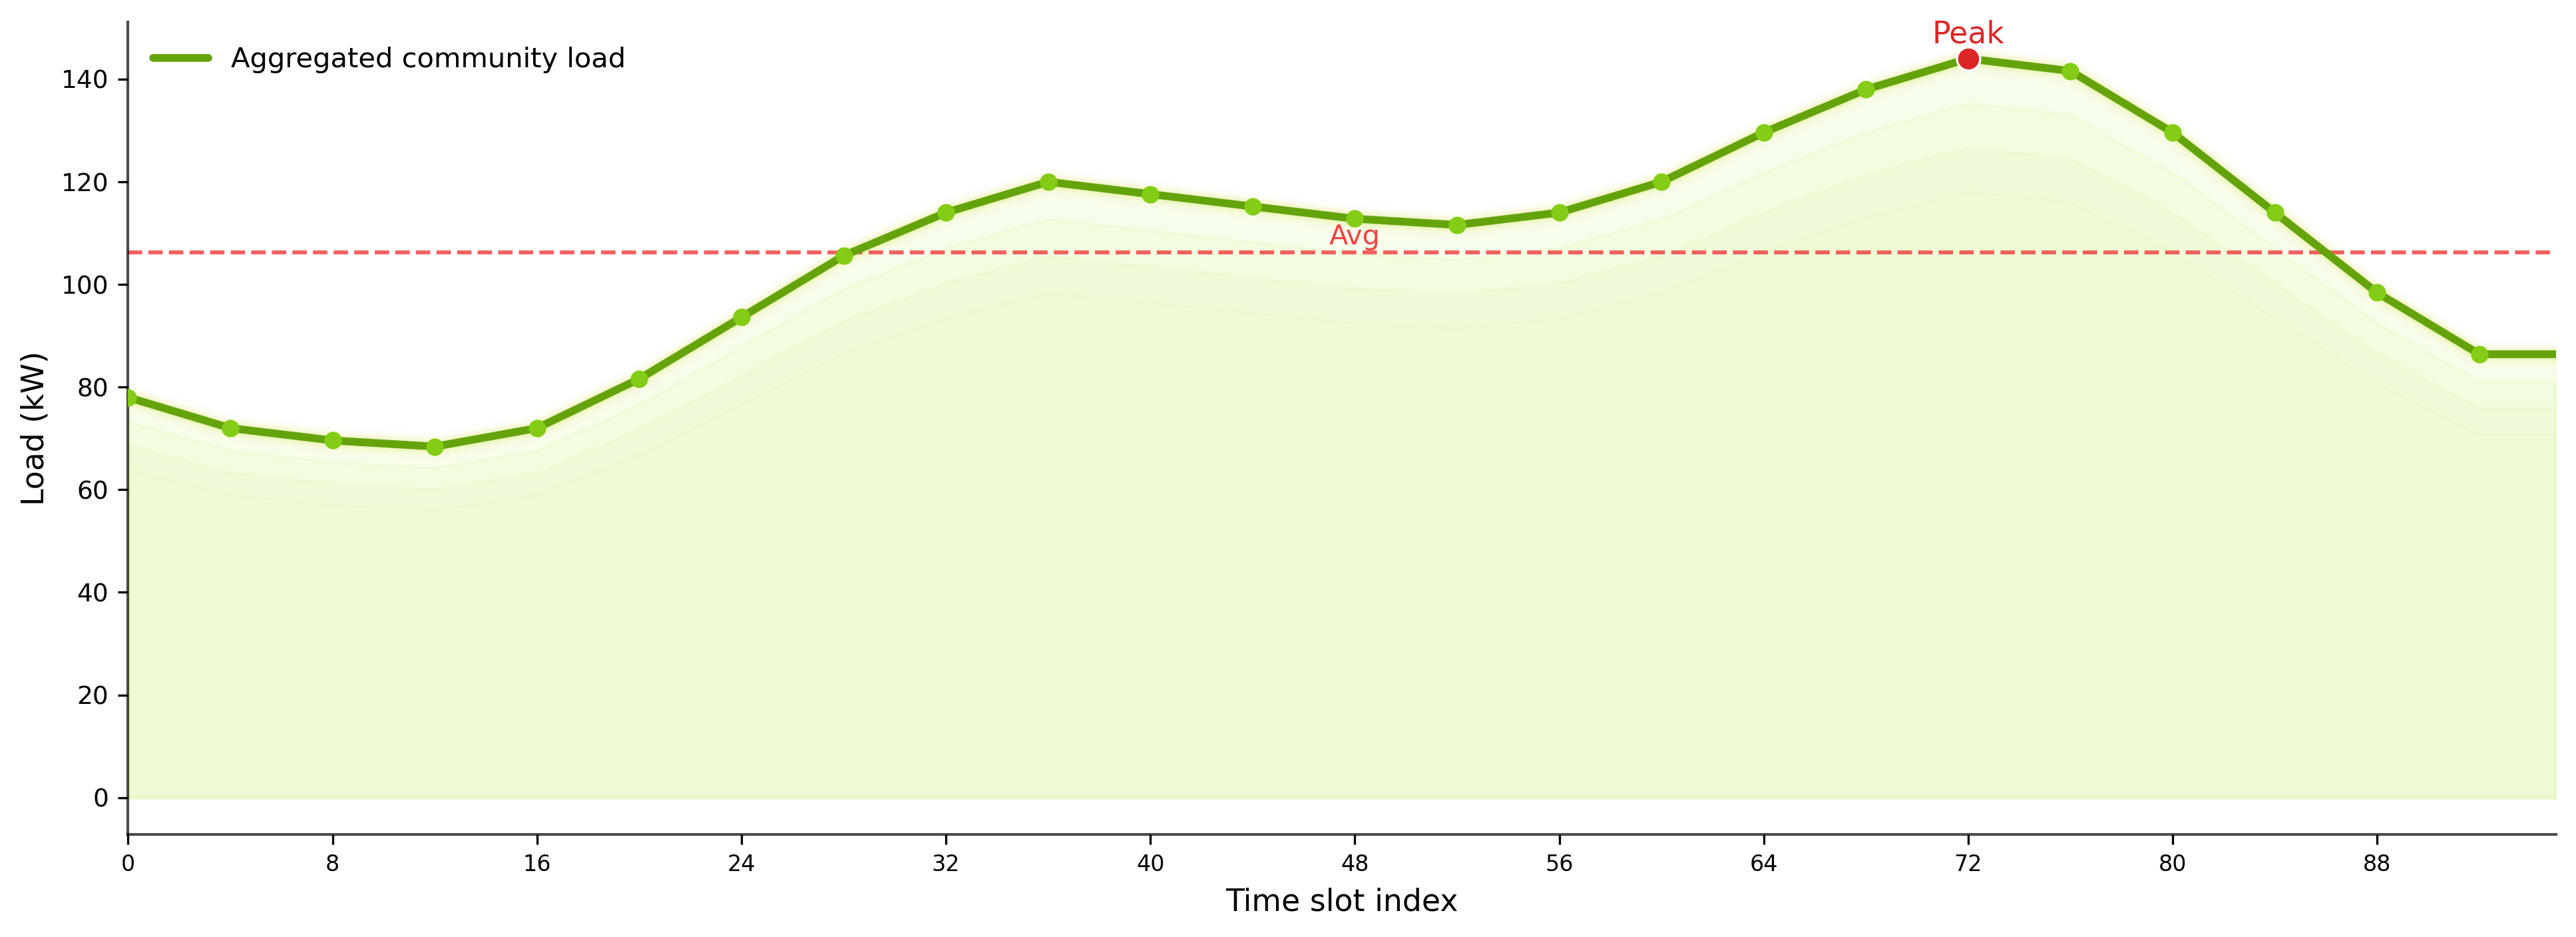

STEP 3 completed successfully.
Figure saved at: /Users/administrator/Desktop/All desktop-data/Prof Sahhi Project/Datasets and Results/Scientific Data/Dataset/Case-D/community_load_96_slots.png


In [37]:
# ======================================================
# STEP 3: Aggregated community load profile in 96 time slots
# ======================================================

FIG_PATH = os.path.join(RESULTS_FOLDER, "community_load_96_slots.png")

# ------------------------------------------------------
# Use 96 time slots instead of datetime
# ------------------------------------------------------
x = np.arange(N_SLOTS)
y = df["community_load_kw"].values

fig, ax = plt.subplots(figsize=(13, 4.8), dpi=300)

# ------------------------------------------------------
# Soft layered fill (bottom)
# ------------------------------------------------------
for alpha, scale in zip([0.20, 0.14, 0.10, 0.06], [1.00, 0.94, 0.88, 0.82]):
    ax.fill_between(
        x,
        y * scale,
        0,
        color="#D9F99D",
        alpha=alpha,
        zorder=1
    )

# ------------------------------------------------------
# Upper soft shadow
# ------------------------------------------------------
for lw, alpha in [(10, 0.05), (7, 0.08), (5, 0.12)]:
    ax.plot(
        x,
        y,
        color="#FEF08A",
        linewidth=lw,
        alpha=alpha,
        solid_capstyle="round",
        zorder=2
    )

# ------------------------------------------------------
# Lower soft shadow
# ------------------------------------------------------
for lw, alpha in [(6, 0.05), (4, 0.08)]:
    ax.plot(
        x,
        y,
        color="#A3E635",
        linewidth=lw,
        alpha=alpha,
        solid_capstyle="round",
        zorder=2
    )

# ------------------------------------------------------
# Main line
# ------------------------------------------------------
ax.plot(
    x,
    y,
    color="#65A30D",
    linewidth=2.8,
    solid_capstyle="round",
    label="Aggregated community load",
    zorder=4
)

# ------------------------------------------------------
# Hourly markers only (every 4 slots)
# ------------------------------------------------------
hourly_slots = np.arange(0, N_SLOTS, 4)
ax.scatter(
    hourly_slots,
    y[hourly_slots],
    color="#84CC16",
    s=28,
    zorder=5
)

# ------------------------------------------------------
# Peak highlight
# ------------------------------------------------------
peak_idx = np.argmax(y)
ax.scatter(
    x[peak_idx],
    y[peak_idx],
    color="#DC2626",
    s=70,
    edgecolor="white",
    linewidth=0.8,
    zorder=6
)

ax.text(
    x[peak_idx],
    y[peak_idx] + 3,
    "Peak",
    color="#DC2626",
    fontsize=11,
    ha="center"
)

# ------------------------------------------------------
# Average line
# ------------------------------------------------------
avg_load = np.mean(y)
ax.axhline(
    avg_load,
    color="#EF4444",
    linestyle="--",
    linewidth=1.4,
    alpha=0.85
)

ax.text(
    x[len(x)//2],
    avg_load + 1.5,
    "Avg",
    color="#EF4444",
    fontsize=10,
    ha="center"
)

# ------------------------------------------------------
# Styling
# ------------------------------------------------------
ax.set_xlabel("Time slot index", fontsize=11)
ax.set_ylabel("Load (kW)", fontsize=11)

tick_positions = np.arange(0, 97, 8)
ax.set_xticks(tick_positions)
ax.set_xticklabels([str(i) for i in tick_positions], fontsize=8)

ax.tick_params(axis="y", labelsize=9)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1.0)
ax.spines["bottom"].set_linewidth(1.0)
ax.spines["left"].set_alpha(0.7)
ax.spines["bottom"].set_alpha(0.7)

ax.margins(x=0)
ax.grid(False)
ax.legend(frameon=False, loc="upper left", fontsize=10)

plt.tight_layout()
plt.savefig(FIG_PATH, dpi=300, bbox_inches="tight")
plt.show()

print("STEP 3 completed successfully.")
print("Figure saved at:", FIG_PATH)

In [38]:
# ======================================================
# STEP 4: Generate community EV scenarios
# ======================================================

# ------------------------------------------------------
# EV fleet types
# ------------------------------------------------------
ev_types = [
    {"EVType": "LEAF40", "Battery_kWh": 40.0},
    {"EVType": "TS60",   "Battery_kWh": 60.0},
    {"EVType": "TM3_80", "Battery_kWh": 80.5},
    {"EVType": "TMX100", "Battery_kWh": 100.0}
]

ev_type_names = [x["EVType"] for x in ev_types]

# ------------------------------------------------------
# Random generator
# ------------------------------------------------------
rng = np.random.default_rng(42)

def sample_arrival_hour(size):
    """
    Arrival centered around evening.
    Std = 2 hours.
    Clipped to 15:00-23:00
    """
    vals = rng.normal(loc=18.0, scale=2.0, size=size)
    return np.clip(vals, 15.0, 23.0)

def sample_stay_duration(size):
    """
    Stay duration after arrival.
    Mean = 12 hours, Std = 2.5 hours.
    Clipped to 6-16 hours.
    """
    vals = rng.normal(loc=12.0, scale=2.5, size=size)
    return np.clip(vals, 6.0, 16.0)

def sample_arrival_soc(size):
    """
    Arrival SoC between 20% and 60%.
    """
    return rng.uniform(0.20, 0.60, size=size)

def sample_target_soc(arrival_soc):
    """
    Target SoC between 70% and 95%, always above arrival SoC.
    """
    target = rng.uniform(0.70, 0.95, size=len(arrival_soc))
    target = np.maximum(target, arrival_soc + 0.10)
    target = np.minimum(target, 0.95)
    return target

# ------------------------------------------------------
# Generate EV records for all penetration levels
# ------------------------------------------------------
community_ev_rows = []

for pen in penetration_levels:
    n_evs = int(round(N_HOUSES * pen))

    chosen_ev_types = rng.choice(ev_type_names, size=n_evs, replace=True)
    arrival_soc = sample_arrival_soc(n_evs)
    target_soc = sample_target_soc(arrival_soc)

    arrival_hour = sample_arrival_hour(n_evs)
    stay_duration = sample_stay_duration(n_evs)
    departure_hour = (arrival_hour + stay_duration) % 24

    for i in range(n_evs):
        ev_type = chosen_ev_types[i]
        battery_kwh = next(x["Battery_kWh"] for x in ev_types if x["EVType"] == ev_type)

        required_energy = (target_soc[i] - arrival_soc[i]) * battery_kwh

        community_ev_rows.append({
            "Penetration": pen,
            "EV_ID": f"P{int(pen*100)}_{i+1}",
            "EVType": ev_type,
            "Battery_kWh": battery_kwh,
            "ArrivalSoC": arrival_soc[i],
            "TargetSoC": target_soc[i],
            "ArrivalHour": arrival_hour[i],
            "StayDuration_h": stay_duration[i],
            "DepartureHour": departure_hour[i],
            "RequiredEnergy_kWh": required_energy
        })

community_ev_df = pd.DataFrame(community_ev_rows)

# ------------------------------------------------------
# Save scenario table
# ------------------------------------------------------
ev_scenario_file = os.path.join(RESULTS_FOLDER, "community_ev_random_scenarios.csv")
community_ev_df.to_csv(ev_scenario_file, index=False)

print("STEP 4 completed successfully.")
print("Saved EV scenario table to:", ev_scenario_file)
print("Total EV records generated:", len(community_ev_df))
community_ev_df.head()

STEP 4 completed successfully.
Saved EV scenario table to: /Users/administrator/Desktop/All desktop-data/Prof Sahhi Project/Datasets and Results/Scientific Data/Dataset/Case-D/community_ev_random_scenarios.csv
Total EV records generated: 90


,Penetration,EV_ID,EVType,Battery_kWh,ArrivalSoC,TargetSoC,ArrivalHour,StayDuration_h,DepartureHour,RequiredEnergy_kWh
0,0.2,P20_1,LEAF40,40.0,0.590249,0.756810,17.295733,14.822431,8.118164,6.662430
1,0.2,P20_2,TMX100,100.0,0.504456,0.838646,19.064618,11.715131,6.779750,33.419032
2,0.2,P20_3,TM3_80,80.5,0.514426,0.715954,18.730888,9.899609,4.630497,16.223052
3,0.2,P20_4,TS60,60.0,0.251245,0.906908,18.825465,9.938797,4.764262,39.339740
4,0.2,P20_5,TS60,60.0,0.380154,0.857916,18.861642,13.626482,8.488124,28.665703


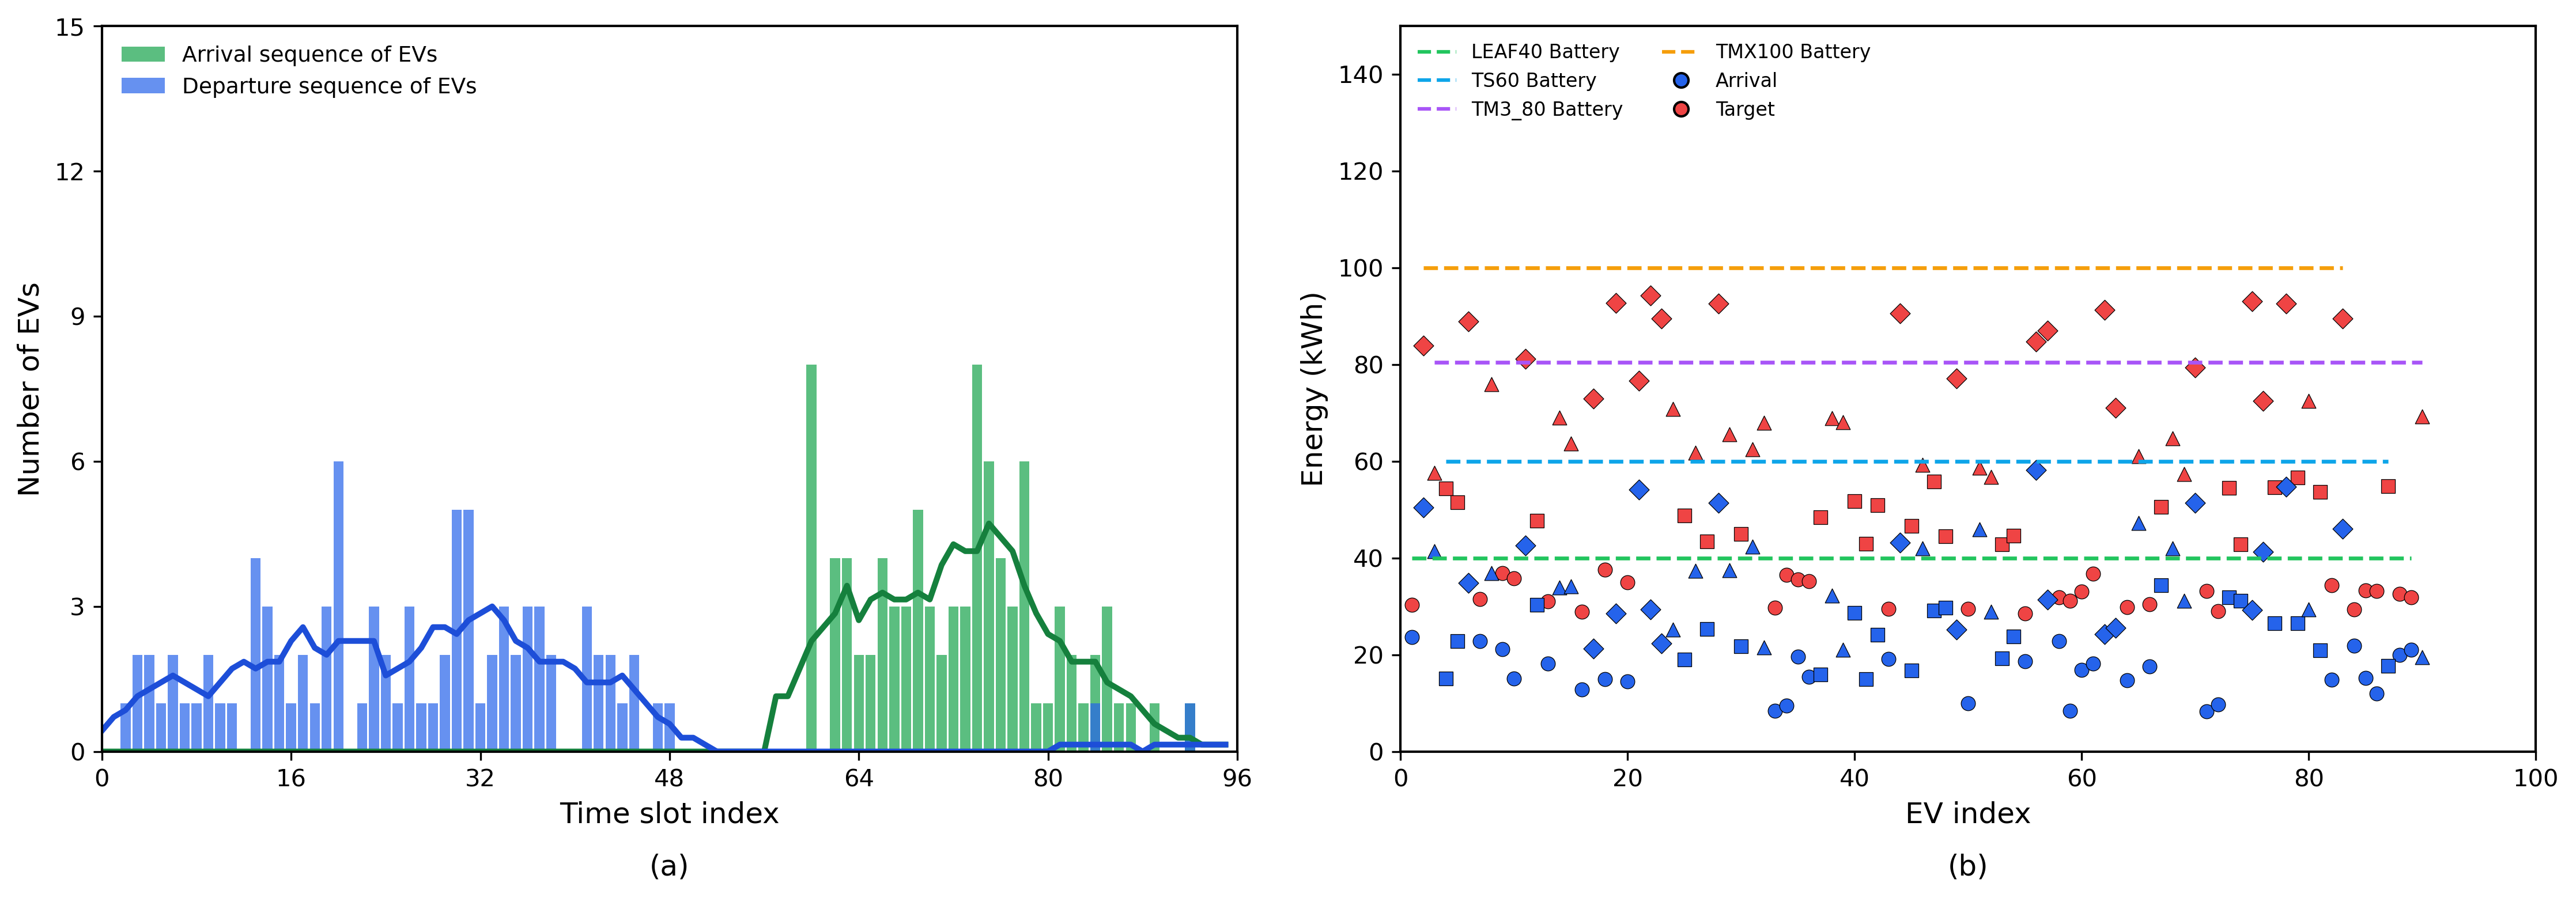

In [39]:
# ======================================================
# STEP 5: Combined figure for EV scenario setup
# (a) Arrival/departure sequence
# (b) Battery capacity + arrival energy + target energy
# ======================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from matplotlib.lines import Line2D

COMBINED_FIG = os.path.join(RESULTS_FOLDER, "final_clean_figure.png")

# ------------------------------------------------------
# Data
# ------------------------------------------------------
plot_df = community_ev_df.copy().reset_index(drop=True)
plot_df["EV_Index"] = np.arange(1, len(plot_df) + 1)

# Slots
plot_df["ArrivalSlot"] = np.floor(plot_df["ArrivalHour"] * 4).astype(int).clip(0, 95)
plot_df["DepartureSlot"] = np.floor(plot_df["DepartureHour"] * 4).astype(int).clip(0, 95)

slot_index = np.arange(96)

arrival_counts = plot_df["ArrivalSlot"].value_counts().reindex(slot_index, fill_value=0).sort_index()
departure_counts = plot_df["DepartureSlot"].value_counts().reindex(slot_index, fill_value=0).sort_index()

# Smooth
def smooth(y, w=7):
    if w % 2 == 0:
        w += 1
    return np.convolve(y, np.ones(w)/w, mode="same")

arrival_smooth = smooth(arrival_counts.values)
departure_smooth = smooth(departure_counts.values)

# SoC → kWh
plot_df["Arrival_kWh"] = plot_df["ArrivalSoC"] * plot_df["Battery_kWh"]
plot_df["Target_kWh"]  = plot_df["TargetSoC"] * plot_df["Battery_kWh"]

# Markers
marker_map = {"LEAF40": "o", "TS60": "s", "TM3_80": "^", "TMX100": "D"}

# Colors
color_arrival_bar = "#16A34A"
color_depart_bar  = "#2563EB"
color_arrival_line = "#15803D"
color_depart_line  = "#1D4ED8"

color_arrival = "#2563EB"
color_target  = "#EF4444"

battery_colors = {
    "LEAF40": "#22C55E",
    "TS60":   "#0EA5E9",
    "TM3_80": "#A855F7",
    "TMX100": "#F59E0B"
}

# ------------------------------------------------------
# Figure
# ------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5.5), dpi=300)

# ======================================================
# (a) Arrival / Departure
# ======================================================
ax1.bar(slot_index, arrival_counts.values, width=0.85, color=color_arrival_bar, alpha=0.7, label="Arrival sequence of EVs")
ax1.bar(slot_index, departure_counts.values, width=0.85, color=color_depart_bar, alpha=0.7, label="Departure sequence of EVs")

ax1.plot(slot_index, arrival_smooth, color=color_arrival_line, linewidth=2.4)
ax1.plot(slot_index, departure_smooth, color=color_depart_line, linewidth=2.4)

ax1.set_xlabel("Time slot index", fontsize=12)
ax1.set_ylabel("Number of EVs", fontsize=12)

ax1.set_xlim(0, 96)
ax1.set_ylim(0, 15)

ax1.set_xticks(np.arange(0, 97, 16))
ax1.set_yticks(np.arange(0, 16, 3))

ax1.tick_params(labelsize=10)

# remove grid completely
ax1.grid(False)

ax1.spines["top"].set_linewidth(1)
ax1.spines["right"].set_linewidth(1)
ax1.spines["left"].set_linewidth(1)
ax1.spines["bottom"].set_linewidth(1)

ax1.legend(loc="upper left", fontsize=9, frameon=False)

ax1.text(0.5, -0.14, "(a)", transform=ax1.transAxes, ha="center", va="top", fontsize=12)

# ======================================================
# (b) Battery + SoC
# ======================================================
battery_handles = []

for ev_type, marker in marker_map.items():
    subset = plot_df[plot_df["EVType"] == ev_type].sort_values("EV_Index")

    ax2.plot(
        subset["EV_Index"],
        subset["Battery_kWh"],
        linestyle="--",
        linewidth=1.6,
        color=battery_colors[ev_type]
    )

    battery_handles.append(
        Line2D([0], [0], linestyle="--", color=battery_colors[ev_type], label=f"{ev_type} Battery")
    )

    ax2.scatter(
        subset["EV_Index"],
        subset["Arrival_kWh"],
        s=35,
        marker=marker,
        color=color_arrival,
        edgecolors="black",
        linewidths=0.3
    )

    ax2.scatter(
        subset["EV_Index"],
        subset["Target_kWh"],
        s=35,
        marker=marker,
        color=color_target,
        edgecolors="black",
        linewidths=0.3
    )

ax2.set_xlabel("EV index", fontsize=12)
ax2.set_ylabel("Energy (kWh)", fontsize=12)

ax2.set_xlim(0, 100)
ax2.set_ylim(0, 150)
ax2.set_xticks(np.arange(0, 101, 20))

ax2.tick_params(labelsize=10)

# remove grid completely
ax2.grid(False)

ax2.spines["top"].set_linewidth(1)
ax2.spines["right"].set_linewidth(1)
ax2.spines["left"].set_linewidth(1)
ax2.spines["bottom"].set_linewidth(1)

custom_handles = battery_handles + [
    Line2D([0], [0], marker='o', color='w', markerfacecolor=color_arrival,
           markeredgecolor='black', markersize=6, label='Arrival'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor=color_target,
           markeredgecolor='black', markersize=6, label='Target')
]

ax2.legend(handles=custom_handles, loc="upper left", fontsize=8, frameon=False, ncol=2)

ax2.text(0.5, -0.14, "(b)", transform=ax2.transAxes, ha="center", va="top", fontsize=12)

# ------------------------------------------------------
# Save
# ------------------------------------------------------
plt.tight_layout(w_pad=2)
plt.subplots_adjust(bottom=0.2)
plt.savefig(COMBINED_FIG, dpi=300, bbox_inches="tight")
plt.show()

#print("Final clean figure saved at:", COMBINED_FIG)

In [40]:
# ======================================================
# STEP 6: Build EV availability profiles (96 slots)
# ======================================================

import numpy as np
import pandas as pd
import os

# ------------------------------------------------------
# Basic settings
# ------------------------------------------------------
N_SLOTS = 96

# Copy EV table
ev_df = community_ev_df.copy()

# Ensure slot columns exist
if "ArrivalSlot" not in ev_df.columns:
    ev_df["ArrivalSlot"] = np.floor(ev_df["ArrivalHour"] * 4).astype(int).clip(0, 95)

if "DepartureSlot" not in ev_df.columns:
    ev_df["DepartureSlot"] = np.floor(ev_df["DepartureHour"] * 4).astype(int).clip(0, 95)

# ------------------------------------------------------
# Build availability matrix for each EV
# ------------------------------------------------------
availability_matrix = {}

for _, row in ev_df.iterrows():
    ev_id = row["EV_ID"]
    arr = int(row["ArrivalSlot"])
    dep = int(row["DepartureSlot"])

    avail = np.zeros(N_SLOTS, dtype=int)

    if dep > arr:
        # Same-day departure
        avail[arr:dep] = 1
    else:
        # Cross-midnight departure
        avail[arr:] = 1
        avail[:dep] = 1

    availability_matrix[ev_id] = avail

# ------------------------------------------------------
# Convert to DataFrame for inspection
# ------------------------------------------------------
availability_df = pd.DataFrame.from_dict(
    availability_matrix,
    orient="index",
    columns=[f"Slot_{i}" for i in range(N_SLOTS)]
).reset_index().rename(columns={"index": "EV_ID"})

availability_df = availability_df.merge(
    ev_df[["EV_ID", "Penetration", "EVType", "Battery_kWh", "ArrivalHour", "DepartureHour"]],
    on="EV_ID",
    how="left"
)

front_cols = ["EV_ID", "Penetration", "EVType", "Battery_kWh", "ArrivalHour", "DepartureHour"]
slot_cols = [c for c in availability_df.columns if c.startswith("Slot_")]
availability_df = availability_df[front_cols + slot_cols]

# ------------------------------------------------------
# Aggregate available charging power by penetration
# total available power at slot t = sum(EV available at t) * CHARGER_KW
# ------------------------------------------------------
aggregate_available_power_by_pen = {}

for pen in sorted(ev_df["Penetration"].unique()):
    ev_ids_pen = ev_df.loc[ev_df["Penetration"] == pen, "EV_ID"].tolist()

    total_available_power = np.zeros(N_SLOTS)

    for ev_id in ev_ids_pen:
        total_available_power += availability_matrix[ev_id] * CHARGER_KW

    aggregate_available_power_by_pen[pen] = total_available_power

# ------------------------------------------------------
# Summary table
# ------------------------------------------------------
availability_summary = (
    ev_df.groupby("Penetration")
    .agg(
        NumEVs=("EV_ID", "count"),
        AvgArrivalHour=("ArrivalHour", "mean"),
        AvgDepartureHour=("DepartureHour", "mean")
    )
    .reset_index()
)

availability_summary["TotalRequiredEnergy_kWh"] = (
    ev_df.groupby("Penetration")["RequiredEnergy_kWh"].sum().values
)

availability_summary["MaxAvailableEnergy_kWh"] = [
    np.sum(aggregate_available_power_by_pen[pen] * DT_HOURS * ETA)
    for pen in availability_summary["Penetration"]
]

availability_summary["Feasible"] = (
    availability_summary["TotalRequiredEnergy_kWh"] <= availability_summary["MaxAvailableEnergy_kWh"] + 1e-9
)

availability_summary = availability_summary.round({
    "AvgArrivalHour": 2,
    "AvgDepartureHour": 2,
    "TotalRequiredEnergy_kWh": 2,
    "MaxAvailableEnergy_kWh": 2
})

# ------------------------------------------------------
# Save outputs
# ------------------------------------------------------
availability_file = os.path.join(RESULTS_FOLDER, "ev_availability_matrix.csv")
availability_df.to_csv(availability_file, index=False)

availability_summary_file = os.path.join(RESULTS_FOLDER, "availability_summary.csv")
availability_summary.to_csv(availability_summary_file, index=False)

# ------------------------------------------------------
# Display
# ------------------------------------------------------
print("STEP 6 completed successfully.")
print("Saved EV availability matrix to:", availability_file)
print("Saved availability summary to:", availability_summary_file)
availability_summary

STEP 6 completed successfully.
Saved EV availability matrix to: /Users/administrator/Desktop/All desktop-data/Prof Sahhi Project/Datasets and Results/Scientific Data/Dataset/Case-D/ev_availability_matrix.csv
Saved availability summary to: /Users/administrator/Desktop/All desktop-data/Prof Sahhi Project/Datasets and Results/Scientific Data/Dataset/Case-D/availability_summary.csv


,Penetration,NumEVs,AvgArrivalHour,AvgDepartureHour,TotalRequiredEnergy_kWh,MaxAvailableEnergy_kWh,Feasible
0,0.2,10,18.48,6.73,262.66,862.93,True
1,0.6,30,17.99,5.71,963.77,2476.32,True
2,1.0,50,18.28,7.34,1329.52,4247.88,True


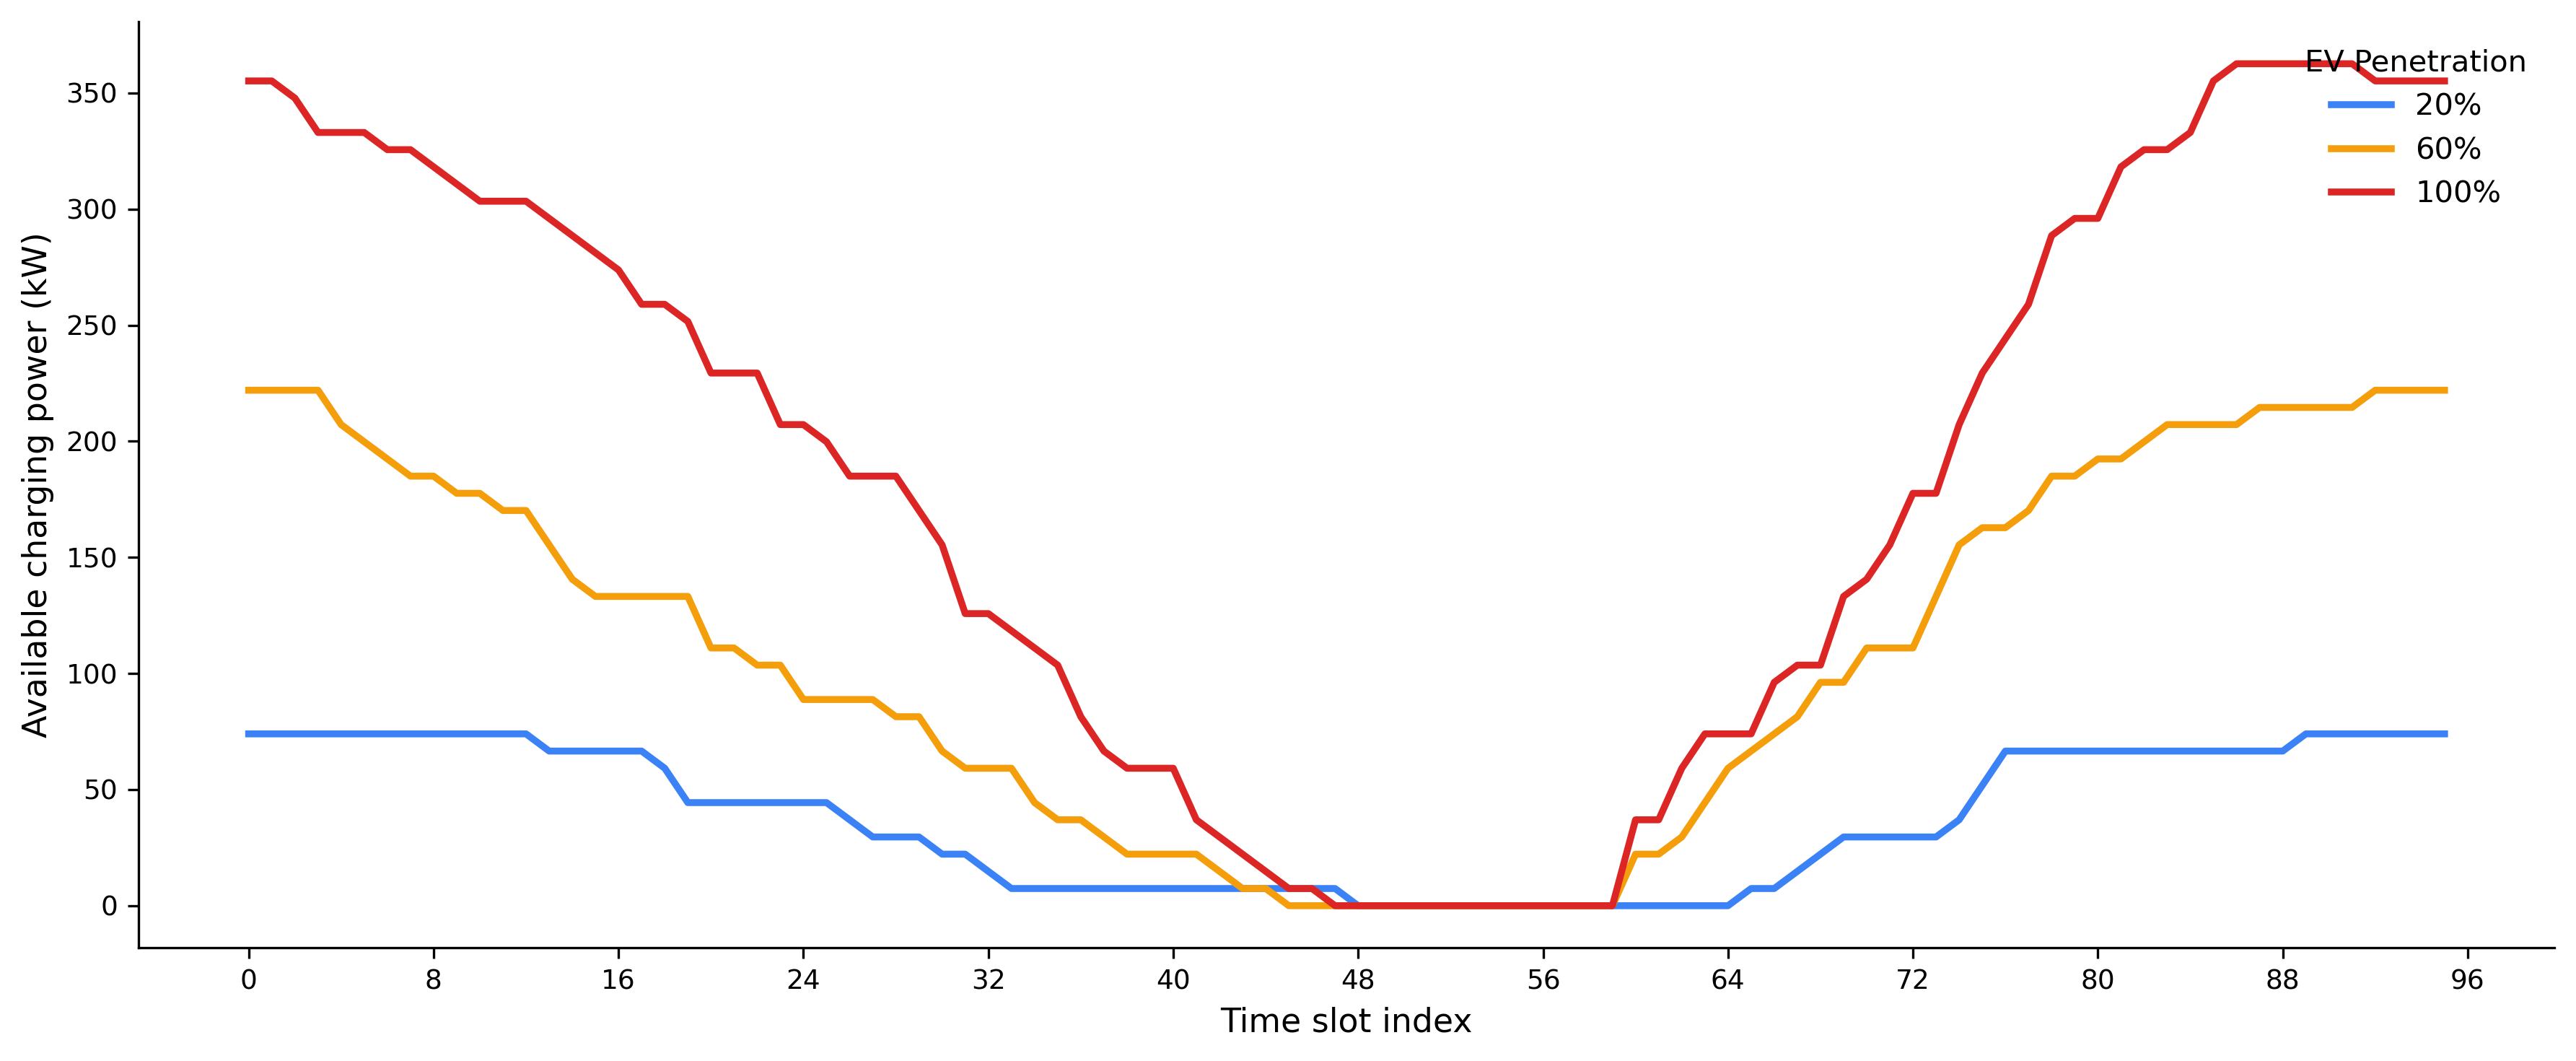

STEP 7 completed successfully.
Figure saved at: /Users/administrator/Desktop/All desktop-data/Prof Sahhi Project/Datasets and Results/Scientific Data/Dataset/Case-D/aggregate_available_power_by_penetration.png


In [41]:
# ======================================================
# STEP 7: Plot aggregate available charging power
# ======================================================

import matplotlib.pyplot as plt
import numpy as np
import os

AVAIL_POWER_FIG = os.path.join(RESULTS_FOLDER, "aggregate_available_power_by_penetration.png")

fig, ax = plt.subplots(figsize=(12, 5), dpi=300)

pen_colors = {
    0.20: "#3B82F6",   # blue
    0.60: "#F59E0B",   # orange
    1.00: "#DC2626"    # red
}

for pen in [0.20, 0.60, 1.00]:
    if pen not in aggregate_available_power_by_pen:
        continue

    ax.plot(
        np.arange(N_SLOTS),
        aggregate_available_power_by_pen[pen],
        linewidth=2.3,
        color=pen_colors[pen],
        label=f"{int(pen*100)}%"
    )

# ------------------------------------------------------
# Styling
# ------------------------------------------------------
ax.set_xlabel("Time slot index", fontsize=11)
ax.set_ylabel("Available charging power (kW)", fontsize=11)

tick_positions = np.arange(0, 97, 8)
ax.set_xticks(tick_positions)
ax.set_xticklabels([str(i) for i in tick_positions], fontsize=9)

ax.tick_params(axis="y", labelsize=9)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(False)

ax.legend(
    title="EV Penetration",
    frameon=False,
    fontsize=10,
    title_fontsize=10,
    loc="upper right"
)

plt.tight_layout()
plt.savefig(AVAIL_POWER_FIG, dpi=300, bbox_inches="tight")
plt.show()

print("STEP 7 completed successfully.")
print("Figure saved at:", AVAIL_POWER_FIG)

In [42]:
# ======================================================
# STEP 8: Prepare community-level inputs for optimization
# ======================================================

import numpy as np
import pandas as pd
import os

community_inputs = {}

for pen in sorted(ev_df["Penetration"].unique()):
    ev_sub = ev_df[ev_df["Penetration"] == pen].copy()

    # --------------------------------------------------
    # Basic EV counts and energy
    # --------------------------------------------------
    num_evs = len(ev_sub)
    total_required_energy = ev_sub["RequiredEnergy_kWh"].sum()

    # --------------------------------------------------
    # Aggregate available charging power
    # --------------------------------------------------
    agg_available_power = aggregate_available_power_by_pen[pen].copy()

    # --------------------------------------------------
    # Community base load and prices
    # --------------------------------------------------
    base_load_kw = df["community_load_kw"].values.copy()
    tou_price = df["tou_price"].values.copy()
    rt_price = df["rt_price"].values.copy()

    # --------------------------------------------------
    # Maximum feasible charging energy
    # --------------------------------------------------
    max_available_energy = np.sum(agg_available_power * DT_HOURS * ETA)
    feasible = total_required_energy <= max_available_energy + 1e-9

    # --------------------------------------------------
    # Store all inputs for this penetration
    # --------------------------------------------------
    community_inputs[pen] = {
        "Penetration": pen,
        "NumEVs": num_evs,
        "TotalRequiredEnergy_kWh": total_required_energy,
        "MaxAvailableEnergy_kWh": max_available_energy,
        "Feasible": feasible,
        "BaseLoad_kW": base_load_kw,
        "AvailablePower_kW": agg_available_power,
        "TOU_Price": tou_price,
        "RT_Price": rt_price
    }

# ------------------------------------------------------
# Compact summary table
# ------------------------------------------------------
community_input_summary = pd.DataFrame([
    {
        "Penetration": v["Penetration"],
        "NumEVs": v["NumEVs"],
        "TotalRequiredEnergy_kWh": v["TotalRequiredEnergy_kWh"],
        "MaxAvailableEnergy_kWh": v["MaxAvailableEnergy_kWh"],
        "Feasible": v["Feasible"],
        "BasePeakLoad_kW": np.max(v["BaseLoad_kW"]),
        "MaxAvailablePower_kW": np.max(v["AvailablePower_kW"])
    }
    for v in community_inputs.values()
])

community_input_summary = community_input_summary.round({
    "TotalRequiredEnergy_kWh": 3,
    "MaxAvailableEnergy_kWh": 3,
    "BasePeakLoad_kW": 3,
    "MaxAvailablePower_kW": 3
})

# ------------------------------------------------------
# Save summary
# ------------------------------------------------------
input_summary_file = os.path.join(RESULTS_FOLDER, "community_input_summary.csv")
community_input_summary.to_csv(input_summary_file, index=False)

print("STEP 8 completed successfully.")
print("Saved input summary to:", input_summary_file)
community_input_summary

STEP 8 completed successfully.
Saved input summary to: /Users/administrator/Desktop/All desktop-data/Prof Sahhi Project/Datasets and Results/Scientific Data/Dataset/Case-D/community_input_summary.csv


,Penetration,NumEVs,TotalRequiredEnergy_kWh,MaxAvailableEnergy_kWh,Feasible,BasePeakLoad_kW,MaxAvailablePower_kW
0,0.2,10,262.656,862.932,True,144.0,74.0
1,0.6,30,963.769,2476.318,True,144.0,222.0
2,1.0,50,1329.524,4247.878,True,144.0,362.6


In [43]:
# ======================================================
# STEP 9: Community-level Uncontrolled Charging (UC)
# ======================================================

import numpy as np
import pandas as pd
import os

def run_uc_schedule(total_required_energy, available_power_kw, dt_hours=DT_HOURS, eta=ETA):
    """
    Uncontrolled charging:
    use all available charging power until total required energy is met.
    """
    ev_kw = np.zeros(len(available_power_kw))
    delivered = 0.0

    for t in range(len(available_power_kw)):
        if available_power_kw[t] > 0 and delivered < total_required_energy:
            ev_kw[t] = available_power_kw[t]
            delivered += eta * ev_kw[t] * dt_hours

            # Trim the last slot if we overshoot
            if delivered > total_required_energy:
                excess = delivered - total_required_energy
                reduce_power = excess / (eta * dt_hours)
                ev_kw[t] = max(ev_kw[t] - reduce_power, 0.0)
                delivered = total_required_energy

    return ev_kw

# ------------------------------------------------------
# Run UC for each penetration level
# ------------------------------------------------------
uc_profiles_by_pen = {}
uc_rows = []

for pen, info in community_inputs.items():
    total_required_energy = info["TotalRequiredEnergy_kWh"]
    available_power_kw = info["AvailablePower_kW"]
    base_load_kw = info["BaseLoad_kW"]
    rt_price = info["RT_Price"]

    if not info["Feasible"]:
        print(f"Skipping UC for {int(pen*100)}% penetration (infeasible).")
        continue

    ev_kw = run_uc_schedule(total_required_energy, available_power_kw)

    total_kw = base_load_kw + ev_kw
    delivered_energy = np.sum(ev_kw * DT_HOURS * ETA)
    charging_cost = np.sum(ev_kw * rt_price * DT_HOURS)

    uc_profiles_by_pen[pen] = ev_kw

    uc_rows.append({
        "Penetration": pen,
        "Method": "UC",
        "NumEVs": info["NumEVs"],
        "RequiredEnergy_kWh": total_required_energy,
        "DeliveredEnergy_kWh": delivered_energy,
        "ChargingCost": charging_cost,
        "PeakTotalLoad_kW": np.max(total_kw),
        "Completed": delivered_energy + 1e-6 >= total_required_energy
    })

uc_results_df = pd.DataFrame(uc_rows)

# Round for presentation
if len(uc_results_df) > 0:
    uc_results_df = uc_results_df.round({
        "RequiredEnergy_kWh": 3,
        "DeliveredEnergy_kWh": 3,
        "ChargingCost": 3,
        "PeakTotalLoad_kW": 3
    })

# Save results
uc_results_file = os.path.join(RESULTS_FOLDER, "community_uc_results.csv")
uc_results_df.to_csv(uc_results_file, index=False)

print("STEP 9 completed successfully.")
print("Saved UC results to:", uc_results_file)
uc_results_df

STEP 9 completed successfully.
Saved UC results to: /Users/administrator/Desktop/All desktop-data/Prof Sahhi Project/Datasets and Results/Scientific Data/Dataset/Case-D/community_uc_results.csv


,Penetration,Method,NumEVs,RequiredEnergy_kWh,DeliveredEnergy_kWh,ChargingCost,PeakTotalLoad_kW,Completed
0,0.2,UC,10,262.656,262.656,22.118,152.0,True
1,0.6,UC,30,963.769,963.769,82.515,300.0,True
2,1.0,UC,50,1329.524,1329.524,111.960,433.2,True


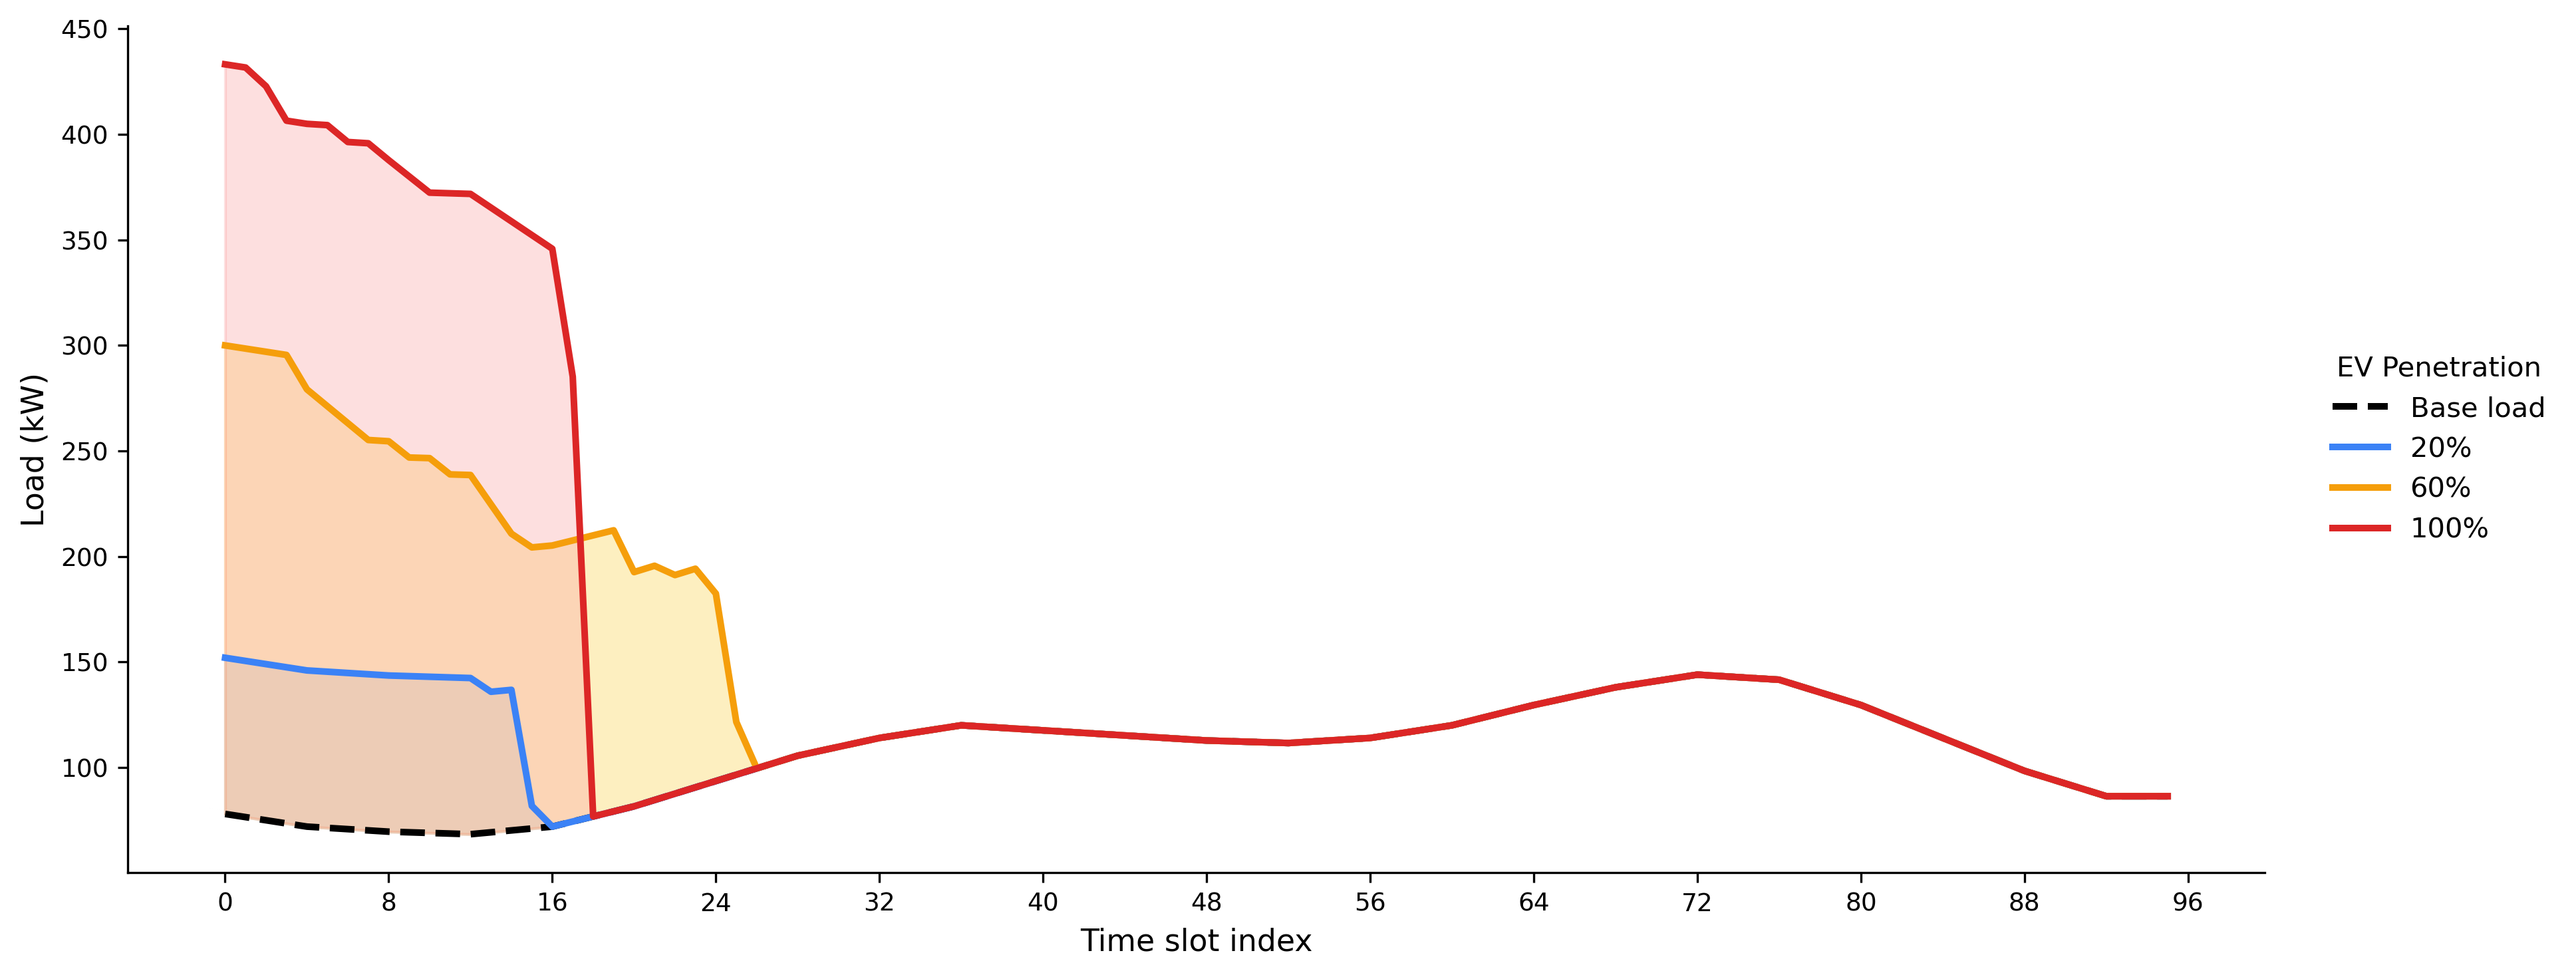

STEP 10 completed successfully.
Figure saved at: /Users/administrator/Desktop/All desktop-data/Prof Sahhi Project/Datasets and Results/Scientific Data/Dataset/Case-D/community_uc_load_styled.png


In [44]:
# ======================================================
# STEP 10: UC load profiles (single plot with penetration)
# ======================================================

import matplotlib.pyplot as plt
import numpy as np
import os

UC_LOAD_FIG = os.path.join(RESULTS_FOLDER, "community_uc_load_styled.png")

fig, ax = plt.subplots(figsize=(13, 5), dpi=300)

x = np.arange(N_SLOTS)
base_load_kw = df["community_load_kw"].values

# ------------------------------------------------------
# Base load
# ------------------------------------------------------
ax.plot(
    x,
    base_load_kw,
    linewidth=2.4,
    color="black",
    linestyle="--",
    label="Base load"
)

# ------------------------------------------------------
# Colors for lines and fills
# ------------------------------------------------------
pen_styles = {
    0.20: {"line": "#3B82F6", "fill": "#93C5FD"},
    0.60: {"line": "#F59E0B", "fill": "#FCD34D"},
    1.00: {"line": "#DC2626", "fill": "#FCA5A5"}
}

# ------------------------------------------------------
# Plot UC loads with soft fill
# ------------------------------------------------------
for pen in [0.20, 0.60, 1.00]:
    if pen not in uc_profiles_by_pen:
        continue

    uc_ev_kw = uc_profiles_by_pen[pen]
    total_load_kw = base_load_kw + uc_ev_kw

    ax.fill_between(
        x,
        base_load_kw,
        total_load_kw,
        color=pen_styles[pen]["fill"],
        alpha=0.35
    )

    ax.plot(
        x,
        total_load_kw,
        linewidth=2.4,
        color=pen_styles[pen]["line"],
        label=f"{int(pen*100)}%"
    )

# ------------------------------------------------------
# Styling
# ------------------------------------------------------
ax.set_xlabel("Time slot index", fontsize=11)
ax.set_ylabel("Load (kW)", fontsize=11)

tick_positions = np.arange(0, 97, 8)
ax.set_xticks(tick_positions)
ax.set_xticklabels([str(i) for i in tick_positions], fontsize=9)

ax.tick_params(axis="y", labelsize=9)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(False)

ax.legend(
    title="EV Penetration",
    frameon=False,
    fontsize=10,
    title_fontsize=10,
    loc="center left",
    bbox_to_anchor=(1.02, 0.5)
)

plt.tight_layout()
plt.savefig(UC_LOAD_FIG, dpi=300, bbox_inches="tight")
plt.show()

print("STEP 10 completed successfully.")
print("Figure saved at:", UC_LOAD_FIG)

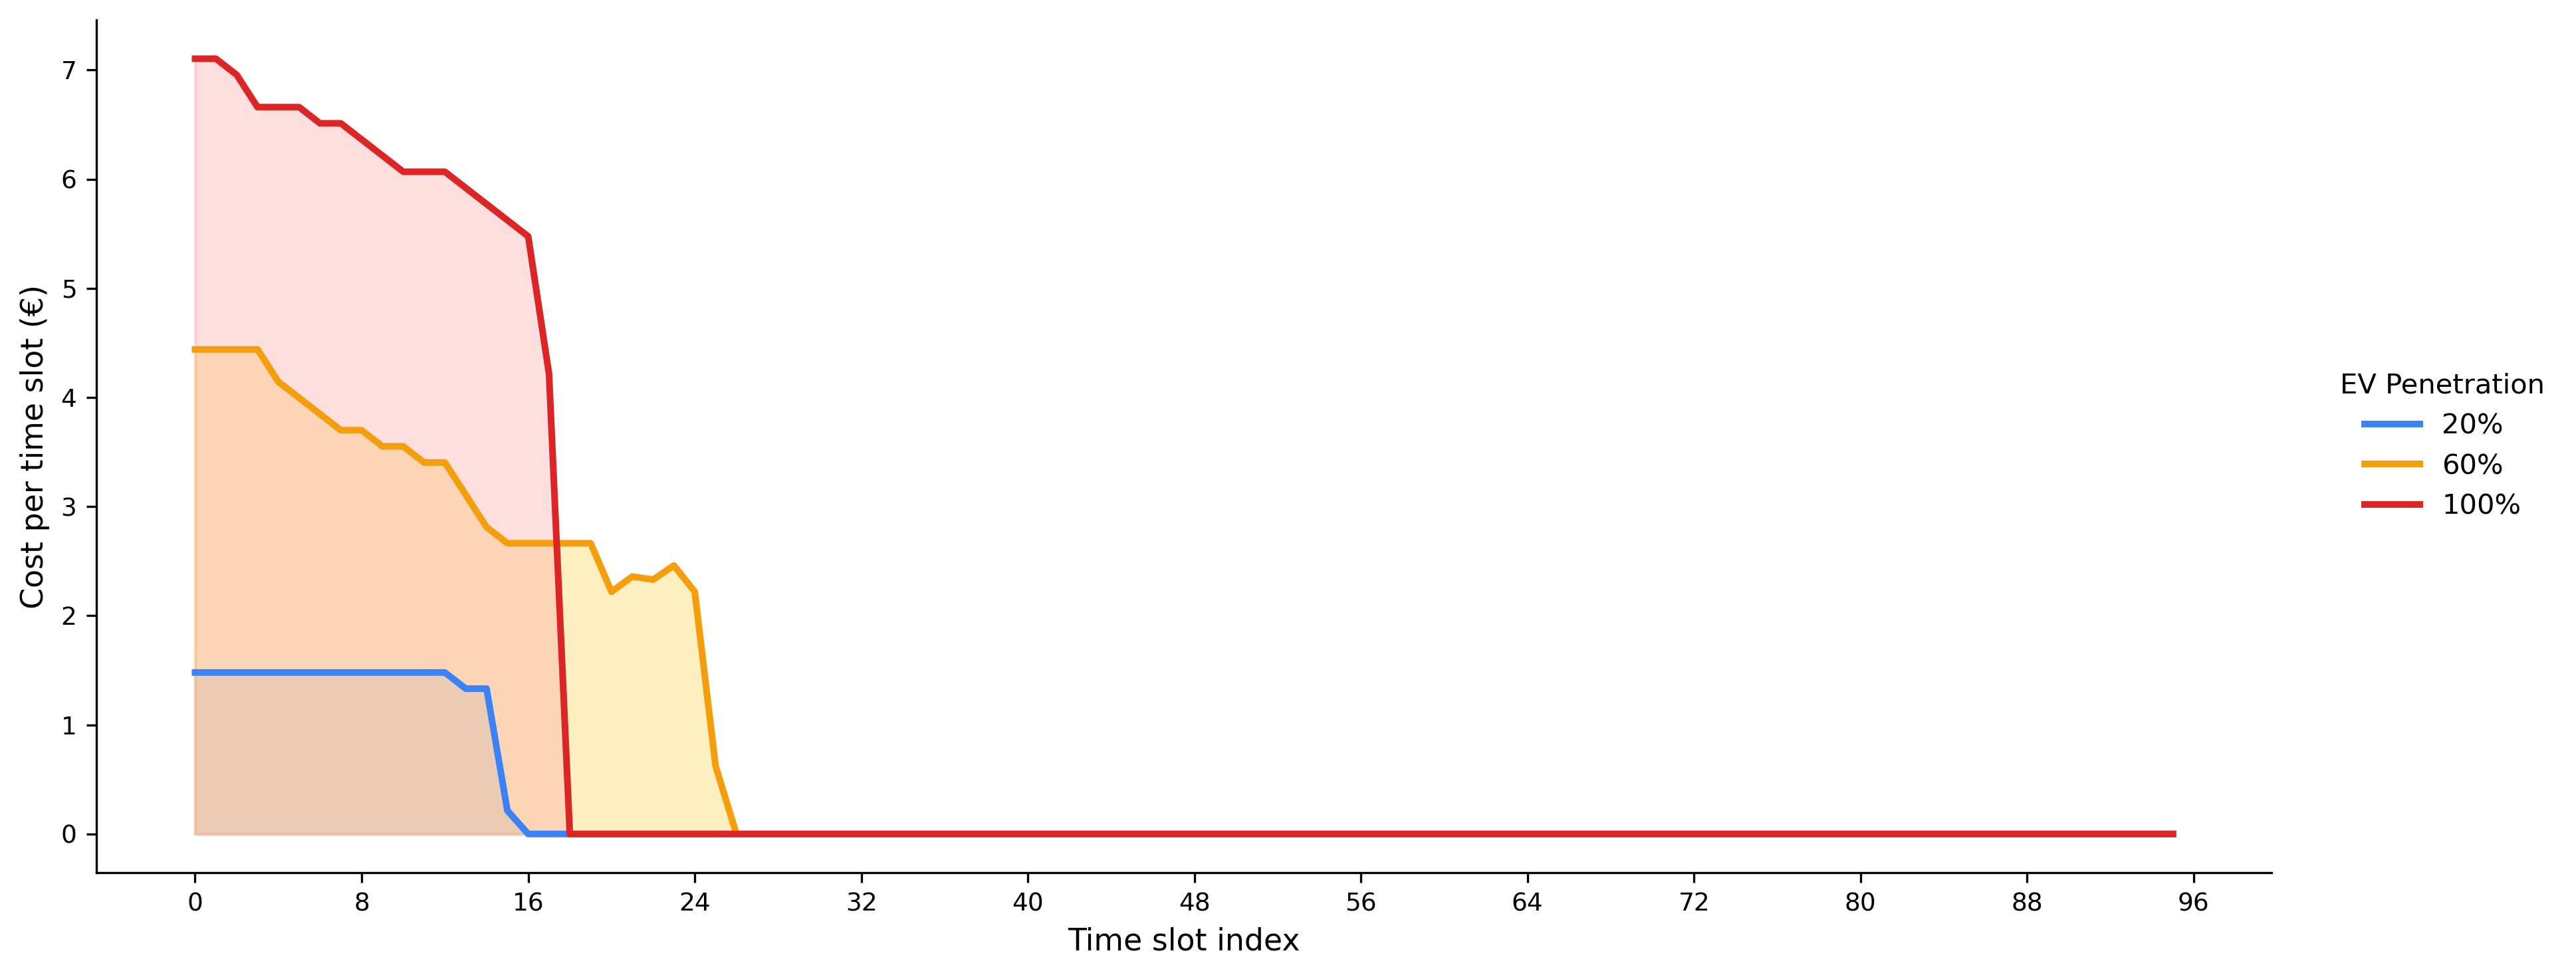

STEP 11 completed successfully.
Figure saved at: /Users/administrator/Desktop/All desktop-data/Prof Sahhi Project/Datasets and Results/Scientific Data/Dataset/Case-D/community_uc_cost_styled.png


In [45]:
# ======================================================
# STEP 11: UC charging cost profiles (single plot with penetration)
# ======================================================

import matplotlib.pyplot as plt
import numpy as np
import os

UC_COST_FIG = os.path.join(RESULTS_FOLDER, "community_uc_cost_styled.png")

fig, ax = plt.subplots(figsize=(13, 5), dpi=300)

x = np.arange(N_SLOTS)
rt_price = df["rt_price"].values

# ------------------------------------------------------
# Colors for lines and fills
# ------------------------------------------------------
pen_styles = {
    0.20: {"line": "#3B82F6", "fill": "#93C5FD"},
    0.60: {"line": "#F59E0B", "fill": "#FCD34D"},
    1.00: {"line": "#DC2626", "fill": "#FCA5A5"}
}

# ------------------------------------------------------
# Plot UC slot-wise cost for each penetration
# slot cost = EV load × real-time price × dt
# ------------------------------------------------------
for pen in [0.20, 0.60, 1.00]:
    if pen not in uc_profiles_by_pen:
        continue

    uc_ev_kw = uc_profiles_by_pen[pen]
    slot_cost = uc_ev_kw * rt_price * DT_HOURS

    ax.fill_between(
        x,
        0,
        slot_cost,
        color=pen_styles[pen]["fill"],
        alpha=0.35
    )

    ax.plot(
        x,
        slot_cost,
        linewidth=2.4,
        color=pen_styles[pen]["line"],
        label=f"{int(pen*100)}%"
    )

# ------------------------------------------------------
# Styling
# ------------------------------------------------------
ax.set_xlabel("Time slot index", fontsize=11)
ax.set_ylabel("Cost per time slot (€)", fontsize=11)

tick_positions = np.arange(0, 97, 8)
ax.set_xticks(tick_positions)
ax.set_xticklabels([str(i) for i in tick_positions], fontsize=9)

ax.tick_params(axis="y", labelsize=9)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(False)

ax.legend(
    title="EV Penetration",
    frameon=False,
    fontsize=10,
    title_fontsize=10,
    loc="center left",
    bbox_to_anchor=(1.02, 0.5)
)

plt.tight_layout()
plt.savefig(UC_COST_FIG, dpi=300, bbox_inches="tight")
plt.show()

print("STEP 11 completed successfully.")
print("Figure saved at:", UC_COST_FIG)

In [46]:
# ======================================================
# STEP 12: Community-level TOU charging
# ======================================================

import numpy as np
import pandas as pd
import os

def run_tou_schedule(total_required_energy, available_power_kw, tou_price, dt_hours=DT_HOURS, eta=ETA):
    """
    TOU charging:
    allocate charging to the lowest TOU-price slots first,
    subject to available charging power.
    """
    ev_kw = np.zeros(len(available_power_kw))

    # wall-side energy needed
    remaining_energy_wall = total_required_energy / eta

    # only slots where charging is possible
    available_idx = np.where(available_power_kw > 0)[0]

    # sort available slots by TOU price
    sorted_idx = available_idx[np.argsort(tou_price[available_idx])]

    for t in sorted_idx:
        if remaining_energy_wall <= 1e-9:
            break

        slot_energy_wall = available_power_kw[t] * dt_hours
        charge_energy_wall = min(slot_energy_wall, remaining_energy_wall)

        ev_kw[t] = charge_energy_wall / dt_hours
        remaining_energy_wall -= charge_energy_wall

    return ev_kw

# ------------------------------------------------------
# Run TOU for each penetration level
# ------------------------------------------------------
tou_profiles_by_pen = {}
tou_rows = []

for pen, info in community_inputs.items():
    total_required_energy = info["TotalRequiredEnergy_kWh"]
    available_power_kw = info["AvailablePower_kW"]
    base_load_kw = info["BaseLoad_kW"]
    tou_price = info["TOU_Price"]
    rt_price = info["RT_Price"]

    if not info["Feasible"]:
        print(f"Skipping TOU for {int(pen*100)}% penetration (infeasible).")
        continue

    ev_kw = run_tou_schedule(total_required_energy, available_power_kw, tou_price)

    total_kw = base_load_kw + ev_kw
    delivered_energy = np.sum(ev_kw * DT_HOURS * ETA)
    charging_cost = np.sum(ev_kw * rt_price * DT_HOURS)

    tou_profiles_by_pen[pen] = ev_kw

    tou_rows.append({
        "Penetration": pen,
        "Method": "TOU",
        "NumEVs": info["NumEVs"],
        "RequiredEnergy_kWh": total_required_energy,
        "DeliveredEnergy_kWh": delivered_energy,
        "ChargingCost": charging_cost,
        "PeakTotalLoad_kW": np.max(total_kw),
        "Completed": delivered_energy + 1e-6 >= total_required_energy
    })

tou_results_df = pd.DataFrame(tou_rows)

if len(tou_results_df) > 0:
    tou_results_df = tou_results_df.round({
        "RequiredEnergy_kWh": 3,
        "DeliveredEnergy_kWh": 3,
        "ChargingCost": 3,
        "PeakTotalLoad_kW": 3
    })

# ------------------------------------------------------
# Save results
# ------------------------------------------------------
tou_results_file = os.path.join(RESULTS_FOLDER, "community_tou_results.csv")
tou_results_df.to_csv(tou_results_file, index=False)

print("STEP 12 completed successfully.")
print("Saved TOU results to:", tou_results_file)
tou_results_df

STEP 12 completed successfully.
Saved TOU results to: /Users/administrator/Desktop/All desktop-data/Prof Sahhi Project/Datasets and Results/Scientific Data/Dataset/Case-D/community_tou_results.csv


,Penetration,Method,NumEVs,RequiredEnergy_kWh,DeliveredEnergy_kWh,ChargingCost,PeakTotalLoad_kW,Completed
0,0.2,TOU,10,262.656,262.656,22.451,152.0,True
1,0.6,TOU,30,963.769,963.769,82.515,300.0,True
2,1.0,TOU,50,1329.524,1329.524,113.597,433.2,True


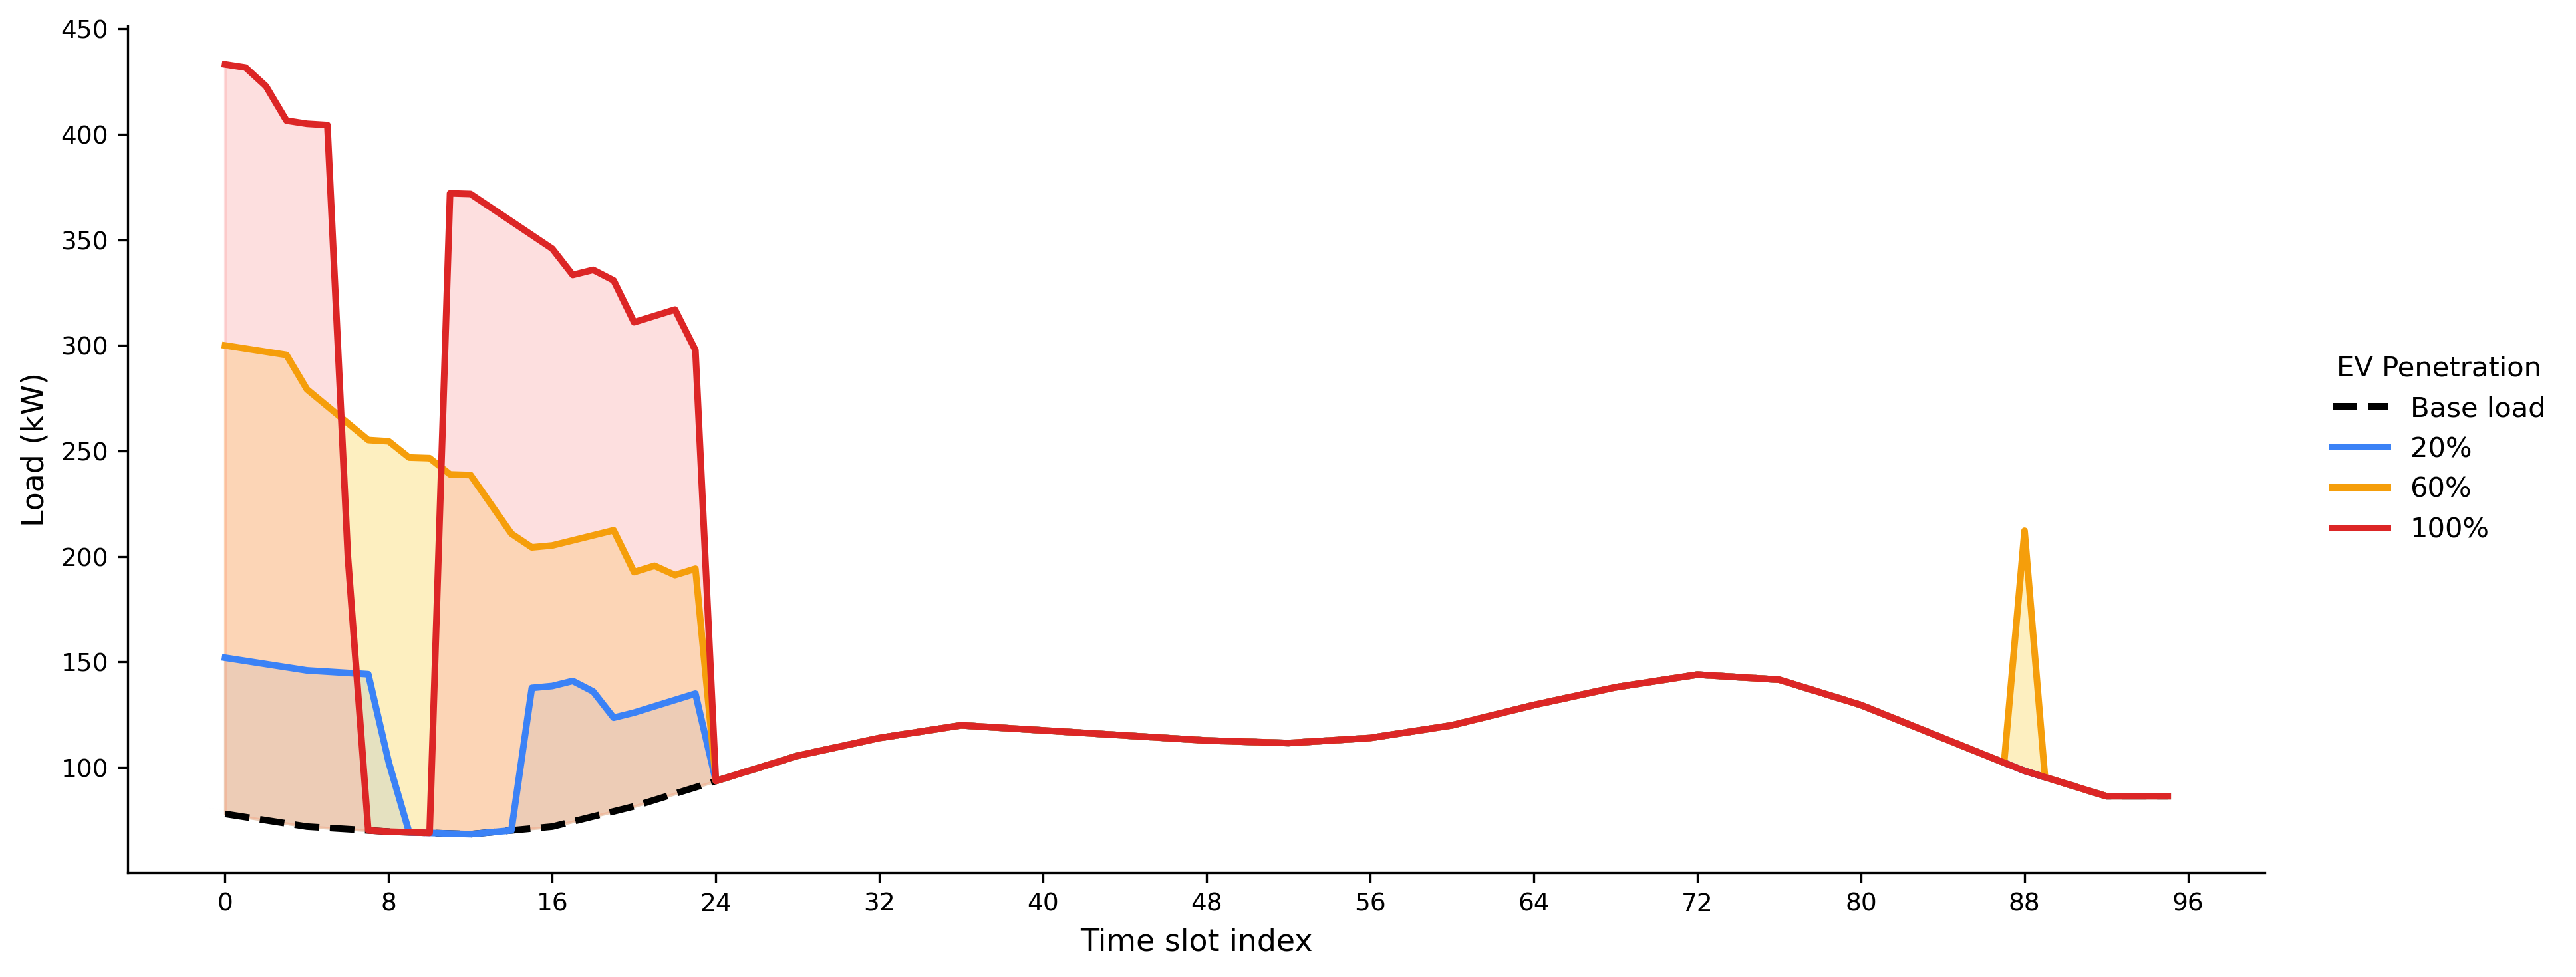

STEP 13 completed successfully.
Figure saved at: /Users/administrator/Desktop/All desktop-data/Prof Sahhi Project/Datasets and Results/Scientific Data/Dataset/Case-D/community_tou_load_styled.png


In [47]:
# ======================================================
# STEP 13: TOU load profiles (single plot with penetration)
# ======================================================

import matplotlib.pyplot as plt
import numpy as np
import os

TOU_LOAD_FIG = os.path.join(RESULTS_FOLDER, "community_tou_load_styled.png")

fig, ax = plt.subplots(figsize=(13, 5), dpi=300)

x = np.arange(N_SLOTS)
base_load_kw = df["community_load_kw"].values

# ------------------------------------------------------
# Base load
# ------------------------------------------------------
ax.plot(
    x,
    base_load_kw,
    linewidth=2.4,
    color="black",
    linestyle="--",
    label="Base load"
)

# ------------------------------------------------------
# Colors for lines and fills
# ------------------------------------------------------
pen_styles = {
    0.20: {"line": "#3B82F6", "fill": "#93C5FD"},
    0.60: {"line": "#F59E0B", "fill": "#FCD34D"},
    1.00: {"line": "#DC2626", "fill": "#FCA5A5"}
}

# ------------------------------------------------------
# Plot TOU loads with soft fill
# ------------------------------------------------------
for pen in [0.20, 0.60, 1.00]:
    if pen not in tou_profiles_by_pen:
        continue

    tou_ev_kw = tou_profiles_by_pen[pen]
    total_load_kw = base_load_kw + tou_ev_kw

    ax.fill_between(
        x,
        base_load_kw,
        total_load_kw,
        color=pen_styles[pen]["fill"],
        alpha=0.35
    )

    ax.plot(
        x,
        total_load_kw,
        linewidth=2.4,
        color=pen_styles[pen]["line"],
        label=f"{int(pen*100)}%"
    )

# ------------------------------------------------------
# Styling
# ------------------------------------------------------
ax.set_xlabel("Time slot index", fontsize=11)
ax.set_ylabel("Load (kW)", fontsize=11)

tick_positions = np.arange(0, 97, 8)
ax.set_xticks(tick_positions)
ax.set_xticklabels([str(i) for i in tick_positions], fontsize=9)

ax.tick_params(axis="y", labelsize=9)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(False)

ax.legend(
    title="EV Penetration",
    frameon=False,
    fontsize=10,
    title_fontsize=10,
    loc="center left",
    bbox_to_anchor=(1.02, 0.5)
)

plt.tight_layout()
plt.savefig(TOU_LOAD_FIG, dpi=300, bbox_inches="tight")
plt.show()

print("STEP 13 completed successfully.")
print("Figure saved at:", TOU_LOAD_FIG)

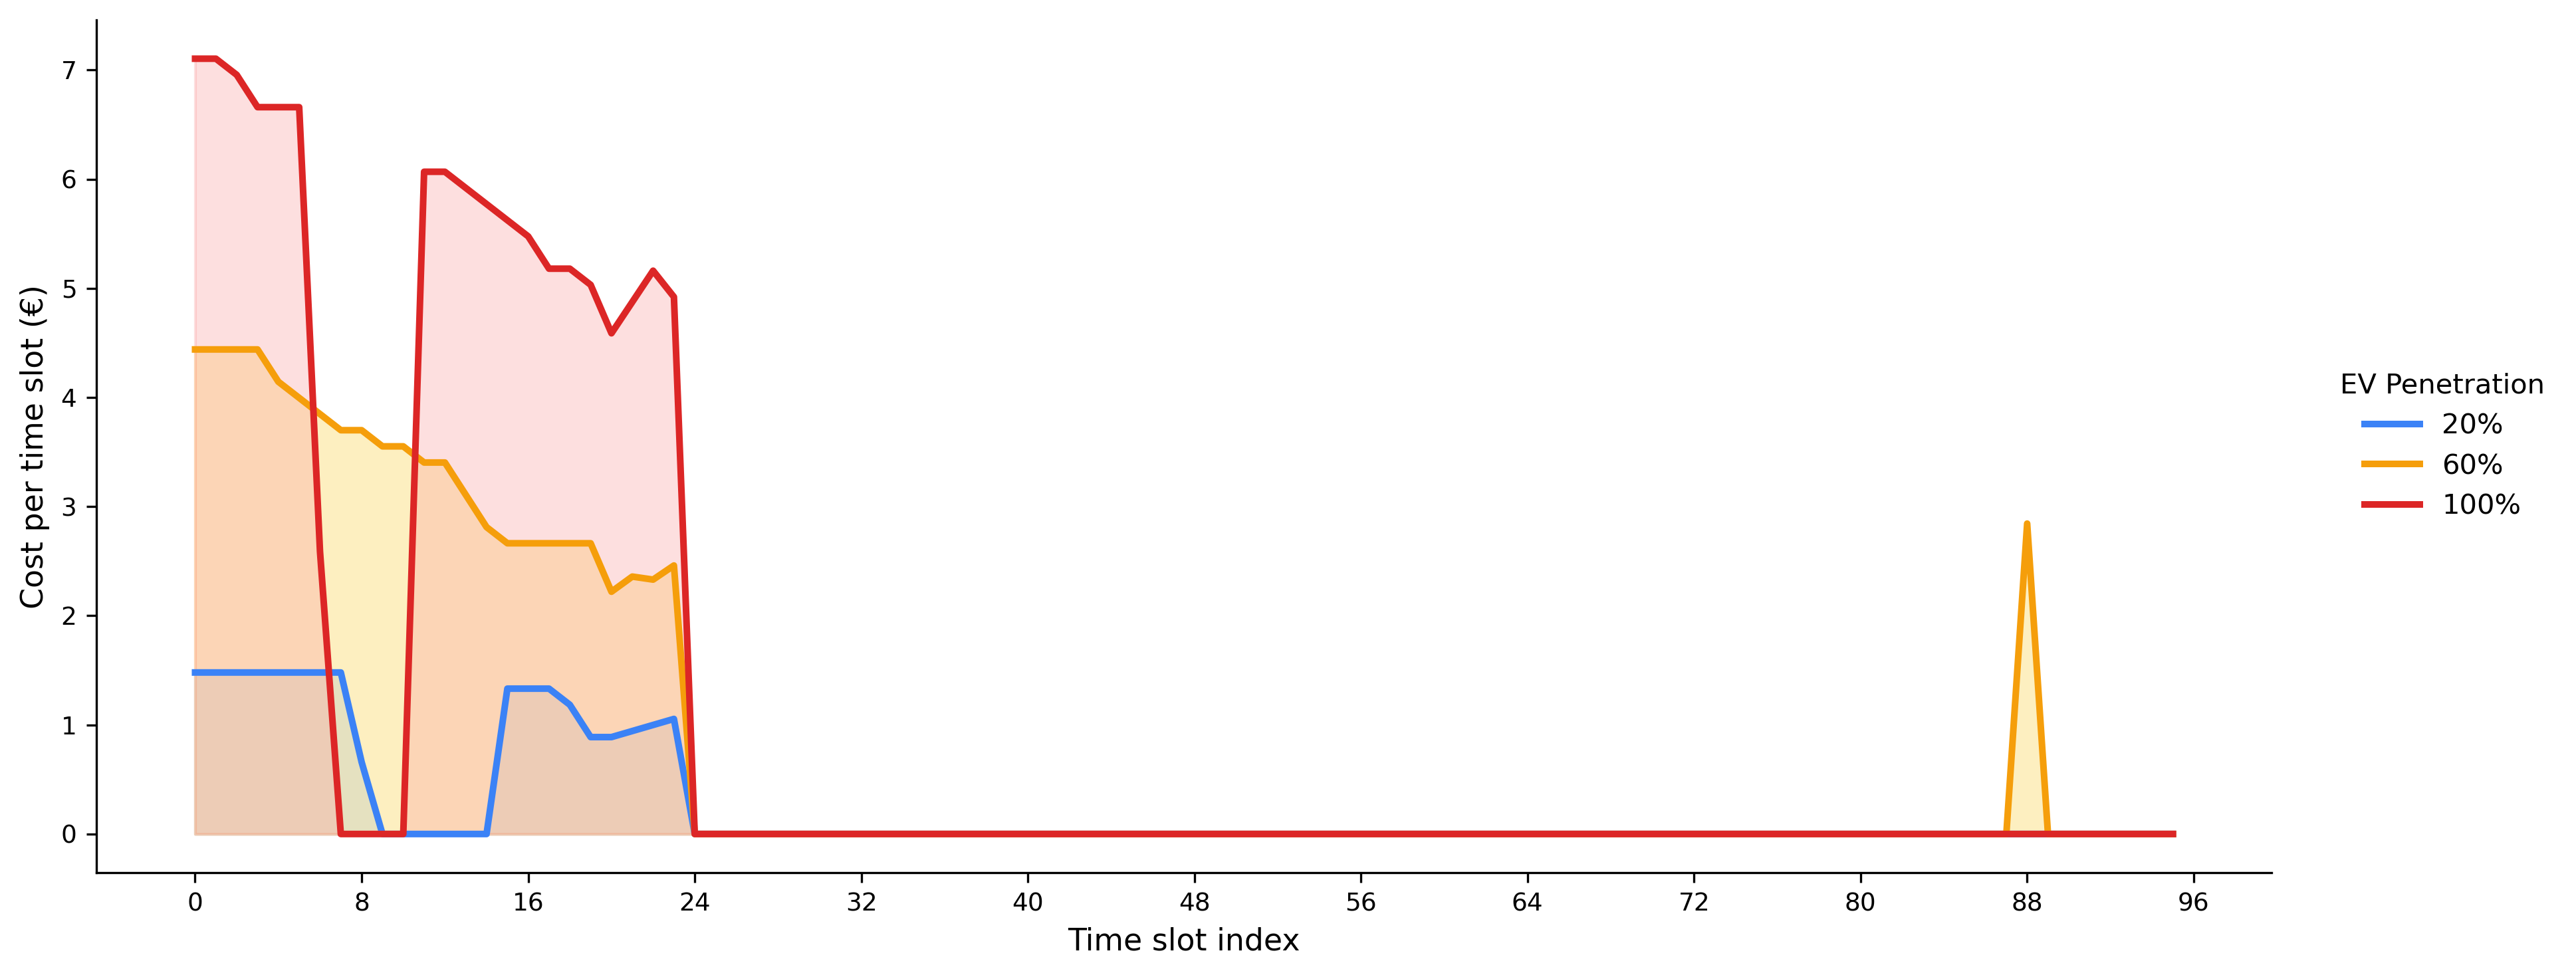

STEP 14 completed successfully.
Figure saved at: /Users/administrator/Desktop/All desktop-data/Prof Sahhi Project/Datasets and Results/Scientific Data/Dataset/Case-D/community_tou_cost_styled.png


In [48]:
# ======================================================
# STEP 14: TOU charging cost profiles (single plot with penetration)
# ======================================================

import matplotlib.pyplot as plt
import numpy as np
import os

TOU_COST_FIG = os.path.join(RESULTS_FOLDER, "community_tou_cost_styled.png")

fig, ax = plt.subplots(figsize=(13, 5), dpi=300)

x = np.arange(N_SLOTS)
rt_price = df["rt_price"].values

# ------------------------------------------------------
# Colors for lines and fills
# ------------------------------------------------------
pen_styles = {
    0.20: {"line": "#3B82F6", "fill": "#93C5FD"},
    0.60: {"line": "#F59E0B", "fill": "#FCD34D"},
    1.00: {"line": "#DC2626", "fill": "#FCA5A5"}
}

# ------------------------------------------------------
# Plot TOU slot-wise cost for each penetration
# slot cost = EV load × real-time price × dt
# ------------------------------------------------------
for pen in [0.20, 0.60, 1.00]:
    if pen not in tou_profiles_by_pen:
        continue

    tou_ev_kw = tou_profiles_by_pen[pen]
    slot_cost = tou_ev_kw * rt_price * DT_HOURS

    ax.fill_between(
        x,
        0,
        slot_cost,
        color=pen_styles[pen]["fill"],
        alpha=0.35
    )

    ax.plot(
        x,
        slot_cost,
        linewidth=2.4,
        color=pen_styles[pen]["line"],
        label=f"{int(pen*100)}%"
    )

# ------------------------------------------------------
# Styling
# ------------------------------------------------------
ax.set_xlabel("Time slot index", fontsize=11)
ax.set_ylabel("Cost per time slot (€)", fontsize=11)

tick_positions = np.arange(0, 97, 8)
ax.set_xticks(tick_positions)
ax.set_xticklabels([str(i) for i in tick_positions], fontsize=9)

ax.tick_params(axis="y", labelsize=9)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(False)

ax.legend(
    title="EV Penetration",
    frameon=False,
    fontsize=10,
    title_fontsize=10,
    loc="center left",
    bbox_to_anchor=(1.02, 0.5)
)

plt.tight_layout()
plt.savefig(TOU_COST_FIG, dpi=300, bbox_inches="tight")
plt.show()

print("STEP 14 completed successfully.")
print("Figure saved at:", TOU_COST_FIG)

In [49]:
# ======================================================
# STEP 15: Community-level SCM (cost minimization)
# ======================================================

import numpy as np
import pandas as pd
import os
from scipy.optimize import linprog

def run_scm_schedule(total_required_energy, available_power_kw, rt_price, dt_hours=DT_HOURS, eta=ETA):
    """
    SCM:
    Minimize charging cost under real-time prices
    subject to charging power limits and energy requirement.
    """
    c = rt_price * dt_hours

    bounds = [(0, available_power_kw[t]) for t in range(len(available_power_kw))]

    A_ub = np.array([-(eta * dt_hours) * np.ones(len(available_power_kw))])
    b_ub = np.array([-total_required_energy])

    result = linprog(
        c=c,
        A_ub=A_ub,
        b_ub=b_ub,
        bounds=bounds,
        method="highs"
    )

    if not result.success:
        raise RuntimeError("SCM failed: " + result.message)

    return result.x

# ------------------------------------------------------
# Run SCM for each penetration level
# ------------------------------------------------------
scm_profiles_by_pen = {}
scm_rows = []

for pen, info in community_inputs.items():
    total_required_energy = info["TotalRequiredEnergy_kWh"]
    available_power_kw = info["AvailablePower_kW"]
    base_load_kw = info["BaseLoad_kW"]
    rt_price = info["RT_Price"]

    if not info["Feasible"]:
        print(f"Skipping SCM for {int(pen*100)}% penetration (infeasible).")
        continue

    ev_kw = run_scm_schedule(total_required_energy, available_power_kw, rt_price)

    total_kw = base_load_kw + ev_kw
    delivered_energy = np.sum(ev_kw * DT_HOURS * ETA)
    charging_cost = np.sum(ev_kw * rt_price * DT_HOURS)

    scm_profiles_by_pen[pen] = ev_kw

    scm_rows.append({
        "Penetration": pen,
        "Method": "SCM",
        "NumEVs": info["NumEVs"],
        "RequiredEnergy_kWh": total_required_energy,
        "DeliveredEnergy_kWh": delivered_energy,
        "ChargingCost": charging_cost,
        "PeakTotalLoad_kW": np.max(total_kw),
        "Completed": delivered_energy + 1e-6 >= total_required_energy
    })

scm_results_df = pd.DataFrame(scm_rows)

if len(scm_results_df) > 0:
    scm_results_df = scm_results_df.round({
        "RequiredEnergy_kWh": 3,
        "DeliveredEnergy_kWh": 3,
        "ChargingCost": 3,
        "PeakTotalLoad_kW": 3
    })

# ------------------------------------------------------
# Save results
# ------------------------------------------------------
scm_results_file = os.path.join(RESULTS_FOLDER, "community_scm_results.csv")
scm_results_df.to_csv(scm_results_file, index=False)

print("STEP 15 completed successfully.")
print("Saved SCM results to:", scm_results_file)
scm_results_df

STEP 15 completed successfully.
Saved SCM results to: /Users/administrator/Desktop/All desktop-data/Prof Sahhi Project/Datasets and Results/Scientific Data/Dataset/Case-D/community_scm_results.csv


,Penetration,Method,NumEVs,RequiredEnergy_kWh,DeliveredEnergy_kWh,ChargingCost,PeakTotalLoad_kW,Completed
0,0.2,SCM,10,262.656,262.656,20.453,166.4,True
1,0.6,SCM,30,963.769,963.769,76.183,308.4,True
2,1.0,SCM,50,1329.524,1329.524,103.949,455.0,True


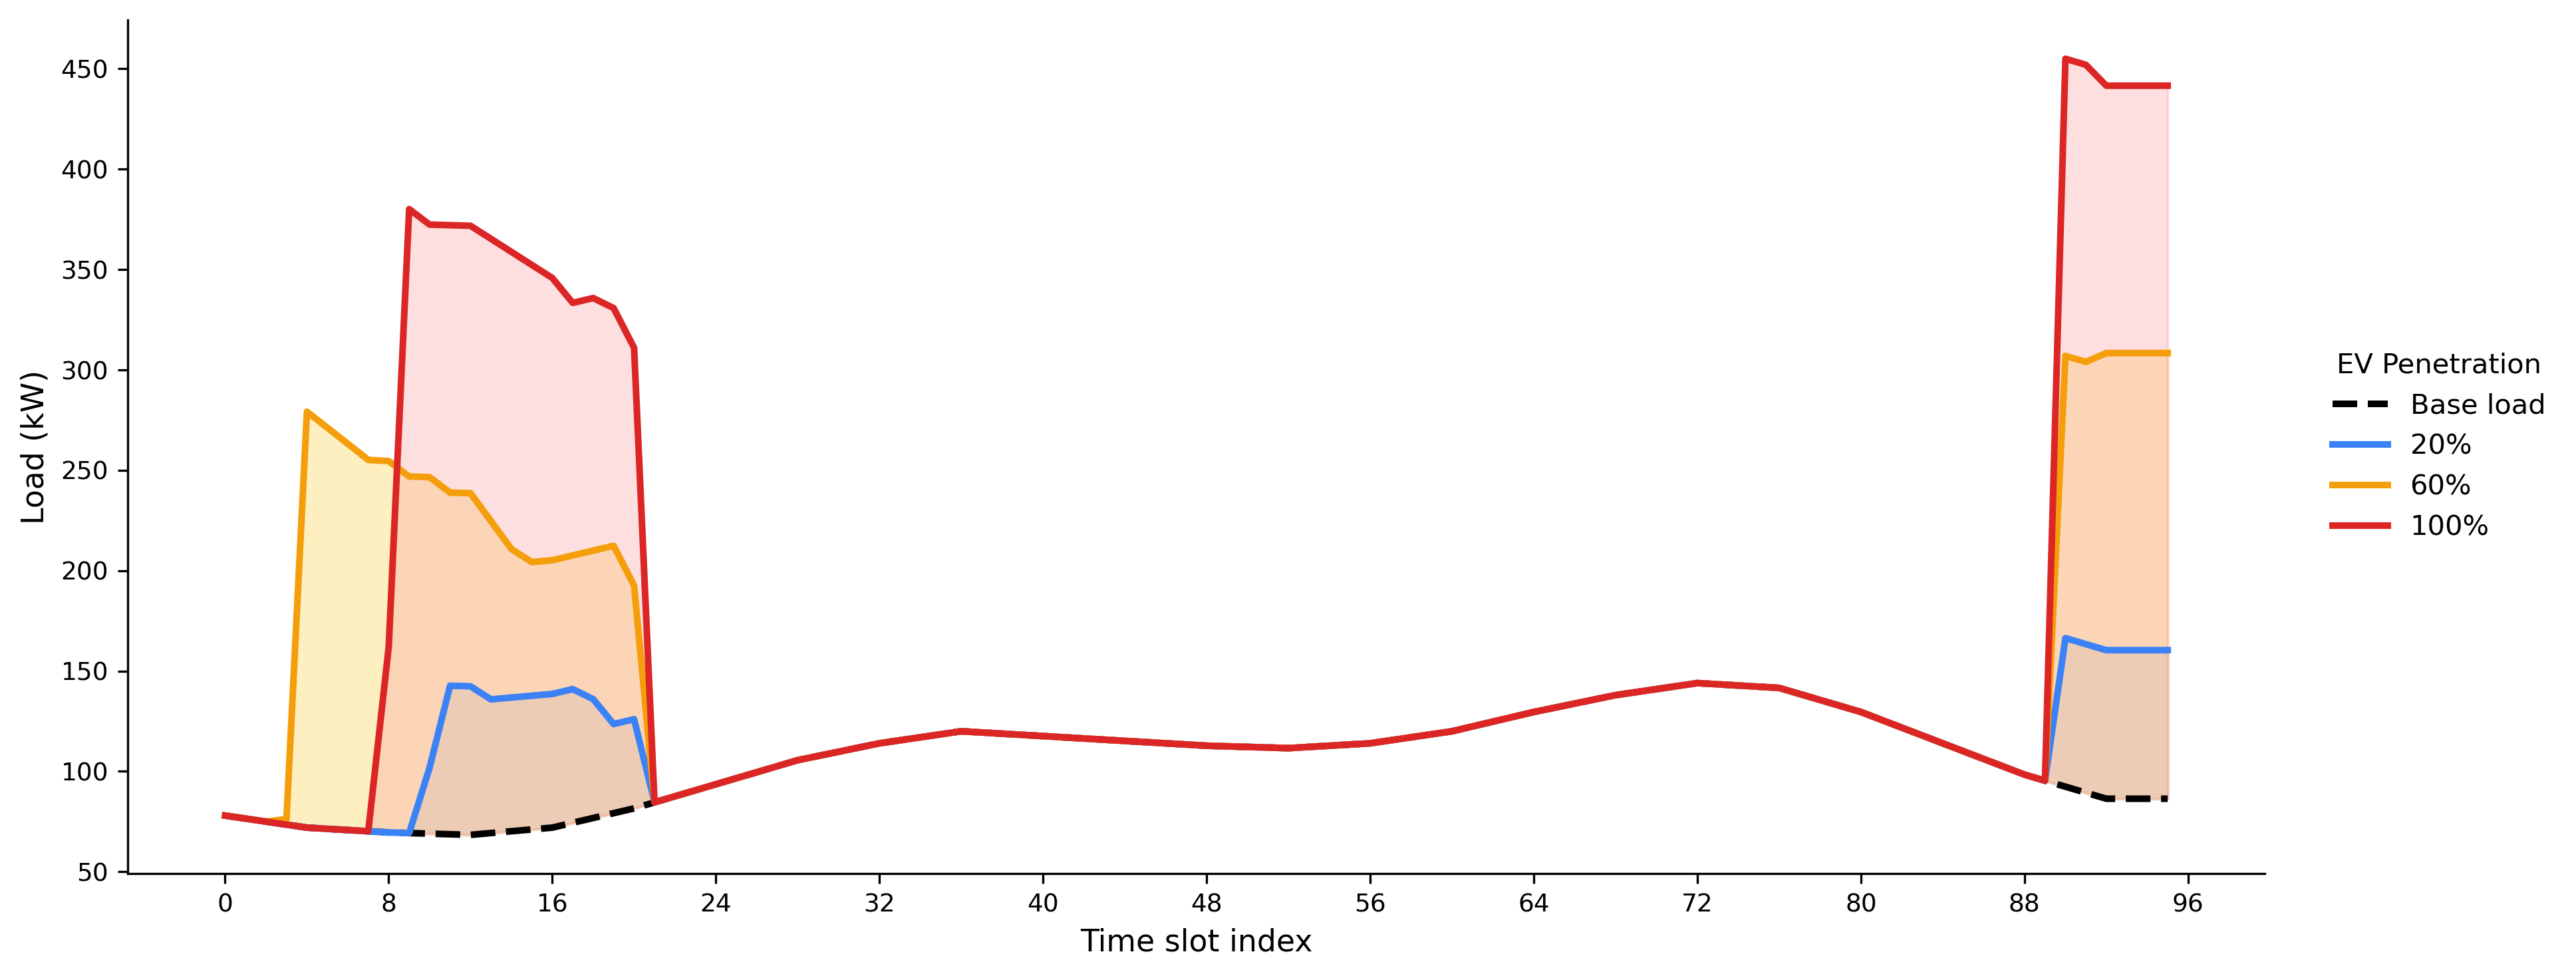

STEP 16 completed successfully.
Figure saved at: /Users/administrator/Desktop/All desktop-data/Prof Sahhi Project/Datasets and Results/Scientific Data/Dataset/Case-D/community_scm_load_styled.png


In [50]:
# ======================================================
# STEP 16: SCM load profiles (single plot with penetration)
# ======================================================

import matplotlib.pyplot as plt
import numpy as np
import os

SCM_LOAD_FIG = os.path.join(RESULTS_FOLDER, "community_scm_load_styled.png")

fig, ax = plt.subplots(figsize=(13, 5), dpi=300)

x = np.arange(N_SLOTS)
base_load_kw = df["community_load_kw"].values

# ------------------------------------------------------
# Base load
# ------------------------------------------------------
ax.plot(
    x,
    base_load_kw,
    linewidth=2.4,
    color="black",
    linestyle="--",
    label="Base load"
)

# ------------------------------------------------------
# Colors for lines and fills
# ------------------------------------------------------
pen_styles = {
    0.20: {"line": "#3B82F6", "fill": "#93C5FD"},
    0.60: {"line": "#F59E0B", "fill": "#FCD34D"},
    1.00: {"line": "#DC2626", "fill": "#FCA5A5"}
}

# ------------------------------------------------------
# Plot SCM loads with soft fill
# ------------------------------------------------------
for pen in [0.20, 0.60, 1.00]:
    if pen not in scm_profiles_by_pen:
        continue

    scm_ev_kw = scm_profiles_by_pen[pen]
    total_load_kw = base_load_kw + scm_ev_kw

    ax.fill_between(
        x,
        base_load_kw,
        total_load_kw,
        color=pen_styles[pen]["fill"],
        alpha=0.35
    )

    ax.plot(
        x,
        total_load_kw,
        linewidth=2.4,
        color=pen_styles[pen]["line"],
        label=f"{int(pen*100)}%"
    )

# ------------------------------------------------------
# Styling
# ------------------------------------------------------
ax.set_xlabel("Time slot index", fontsize=11)
ax.set_ylabel("Load (kW)", fontsize=11)

tick_positions = np.arange(0, 97, 8)
ax.set_xticks(tick_positions)
ax.set_xticklabels([str(i) for i in tick_positions], fontsize=9)

ax.tick_params(axis="y", labelsize=9)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(False)

ax.legend(
    title="EV Penetration",
    frameon=False,
    fontsize=10,
    title_fontsize=10,
    loc="center left",
    bbox_to_anchor=(1.02, 0.5)
)

plt.tight_layout()
plt.savefig(SCM_LOAD_FIG, dpi=300, bbox_inches="tight")
plt.show()

print("STEP 16 completed successfully.")
print("Figure saved at:", SCM_LOAD_FIG)

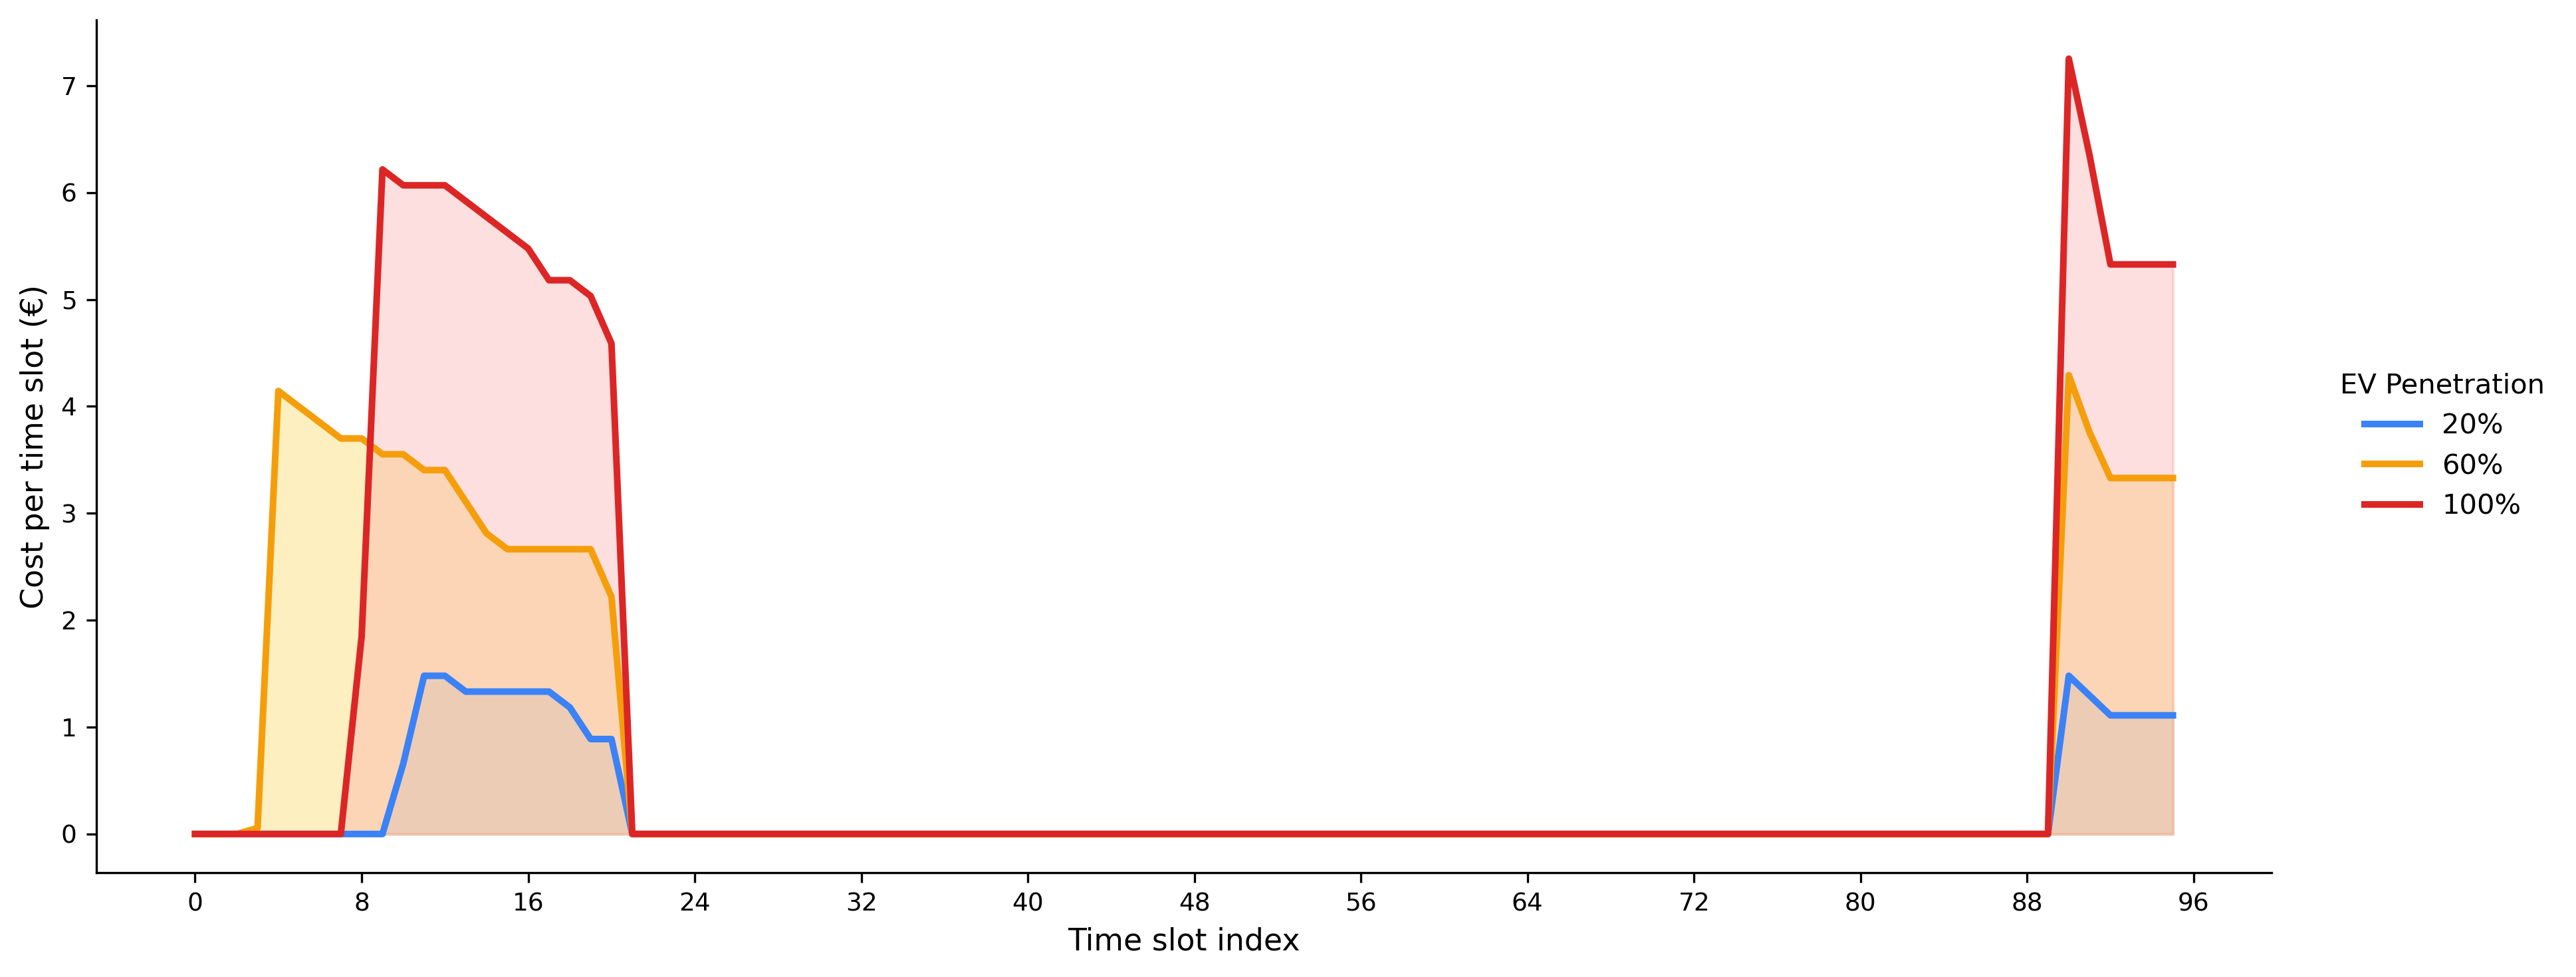

STEP 17 completed successfully.
Figure saved at: /Users/administrator/Desktop/All desktop-data/Prof Sahhi Project/Datasets and Results/Scientific Data/Dataset/Case-D/community_scm_cost_styled.png


In [51]:
# ======================================================
# STEP 17: SCM charging cost profiles (single plot with penetration)
# ======================================================

import matplotlib.pyplot as plt
import numpy as np
import os

SCM_COST_FIG = os.path.join(RESULTS_FOLDER, "community_scm_cost_styled.png")

fig, ax = plt.subplots(figsize=(13, 5), dpi=300)

x = np.arange(N_SLOTS)
rt_price = df["rt_price"].values

# ------------------------------------------------------
# Colors for lines and fills
# ------------------------------------------------------
pen_styles = {
    0.20: {"line": "#3B82F6", "fill": "#93C5FD"},
    0.60: {"line": "#F59E0B", "fill": "#FCD34D"},
    1.00: {"line": "#DC2626", "fill": "#FCA5A5"}
}

# ------------------------------------------------------
# Plot SCM slot-wise cost
# slot cost = EV load × real-time price × dt
# ------------------------------------------------------
for pen in [0.20, 0.60, 1.00]:
    if pen not in scm_profiles_by_pen:
        continue

    scm_ev_kw = scm_profiles_by_pen[pen]
    slot_cost = scm_ev_kw * rt_price * DT_HOURS

    ax.fill_between(
        x,
        0,
        slot_cost,
        color=pen_styles[pen]["fill"],
        alpha=0.35
    )

    ax.plot(
        x,
        slot_cost,
        linewidth=2.4,
        color=pen_styles[pen]["line"],
        label=f"{int(pen*100)}%"
    )

# ------------------------------------------------------
# Styling
# ------------------------------------------------------
ax.set_xlabel("Time slot index", fontsize=11)
ax.set_ylabel("Cost per time slot (€)", fontsize=11)

tick_positions = np.arange(0, 97, 8)
ax.set_xticks(tick_positions)
ax.set_xticklabels([str(i) for i in tick_positions], fontsize=9)

ax.tick_params(axis="y", labelsize=9)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(False)

ax.legend(
    title="EV Penetration",
    frameon=False,
    fontsize=10,
    title_fontsize=10,
    loc="center left",
    bbox_to_anchor=(1.02, 0.5)
)

plt.tight_layout()
plt.savefig(SCM_COST_FIG, dpi=300, bbox_inches="tight")
plt.show()

print("STEP 17 completed successfully.")
print("Figure saved at:", SCM_COST_FIG)

In [52]:
# ======================================================
# STEP 18: Community-level SPM (peak minimization)
# ======================================================

import numpy as np
import pandas as pd
import os
from scipy.optimize import linprog

def run_spm_schedule(total_required_energy, available_power_kw, base_load_kw, dt_hours=DT_HOURS, eta=ETA):
    """
    SPM:
    Minimize the peak total community load.
    Decision variables:
      - charging power at each slot
      - one extra variable for the peak load cap
    """
    n = len(available_power_kw)

    # Objective: minimize the last variable (peak cap)
    c = np.zeros(n + 1)
    c[-1] = 1.0

    # Bounds for charging power + peak cap
    bounds = [(0, available_power_kw[t]) for t in range(n)]
    bounds.append((0, None))  # peak cap

    A_ub = []
    b_ub = []

    # Constraint: base_load[t] + ev_kw[t] <= peak_cap
    for t in range(n):
        row = np.zeros(n + 1)
        row[t] = 1.0
        row[-1] = -1.0
        A_ub.append(row)
        b_ub.append(-base_load_kw[t])

    # Energy delivery constraint:
    # sum(eta * ev_kw[t] * dt_hours) >= total_required_energy
    row = np.zeros(n + 1)
    row[:n] = -(eta * dt_hours)
    A_ub.append(row)
    b_ub.append(-total_required_energy)

    result = linprog(
        c=c,
        A_ub=np.array(A_ub),
        b_ub=np.array(b_ub),
        bounds=bounds,
        method="highs"
    )

    if not result.success:
        raise RuntimeError("SPM failed: " + result.message)

    return result.x[:n]

# ------------------------------------------------------
# Run SPM for each penetration level
# ------------------------------------------------------
spm_profiles_by_pen = {}
spm_rows = []

for pen, info in community_inputs.items():
    total_required_energy = info["TotalRequiredEnergy_kWh"]
    available_power_kw = info["AvailablePower_kW"]
    base_load_kw = info["BaseLoad_kW"]
    rt_price = info["RT_Price"]

    if not info["Feasible"]:
        print(f"Skipping SPM for {int(pen*100)}% penetration (infeasible).")
        continue

    ev_kw = run_spm_schedule(total_required_energy, available_power_kw, base_load_kw)

    total_kw = base_load_kw + ev_kw
    delivered_energy = np.sum(ev_kw * DT_HOURS * ETA)
    charging_cost = np.sum(ev_kw * rt_price * DT_HOURS)

    spm_profiles_by_pen[pen] = ev_kw

    spm_rows.append({
        "Penetration": pen,
        "Method": "SPM",
        "NumEVs": info["NumEVs"],
        "RequiredEnergy_kWh": total_required_energy,
        "DeliveredEnergy_kWh": delivered_energy,
        "ChargingCost": charging_cost,
        "PeakTotalLoad_kW": np.max(total_kw),
        "Completed": delivered_energy + 1e-6 >= total_required_energy
    })

spm_results_df = pd.DataFrame(spm_rows)

if len(spm_results_df) > 0:
    spm_results_df = spm_results_df.round({
        "RequiredEnergy_kWh": 3,
        "DeliveredEnergy_kWh": 3,
        "ChargingCost": 3,
        "PeakTotalLoad_kW": 3
    })

# ------------------------------------------------------
# Save results
# ------------------------------------------------------
spm_results_file = os.path.join(RESULTS_FOLDER, "community_spm_results.csv")
spm_results_df.to_csv(spm_results_file, index=False)

print("STEP 18 completed successfully.")
print("Saved SPM results to:", spm_results_file)
spm_results_df

STEP 18 completed successfully.
Saved SPM results to: /Users/administrator/Desktop/All desktop-data/Prof Sahhi Project/Datasets and Results/Scientific Data/Dataset/Case-D/community_spm_results.csv


,Penetration,Method,NumEVs,RequiredEnergy_kWh,DeliveredEnergy_kWh,ChargingCost,PeakTotalLoad_kW,Completed
0,0.2,SPM,10,262.656,328.653,30.007,144.000,True
1,0.6,SPM,30,963.769,963.769,88.169,157.566,True
2,1.0,SPM,50,1329.524,1329.524,123.592,175.939,True


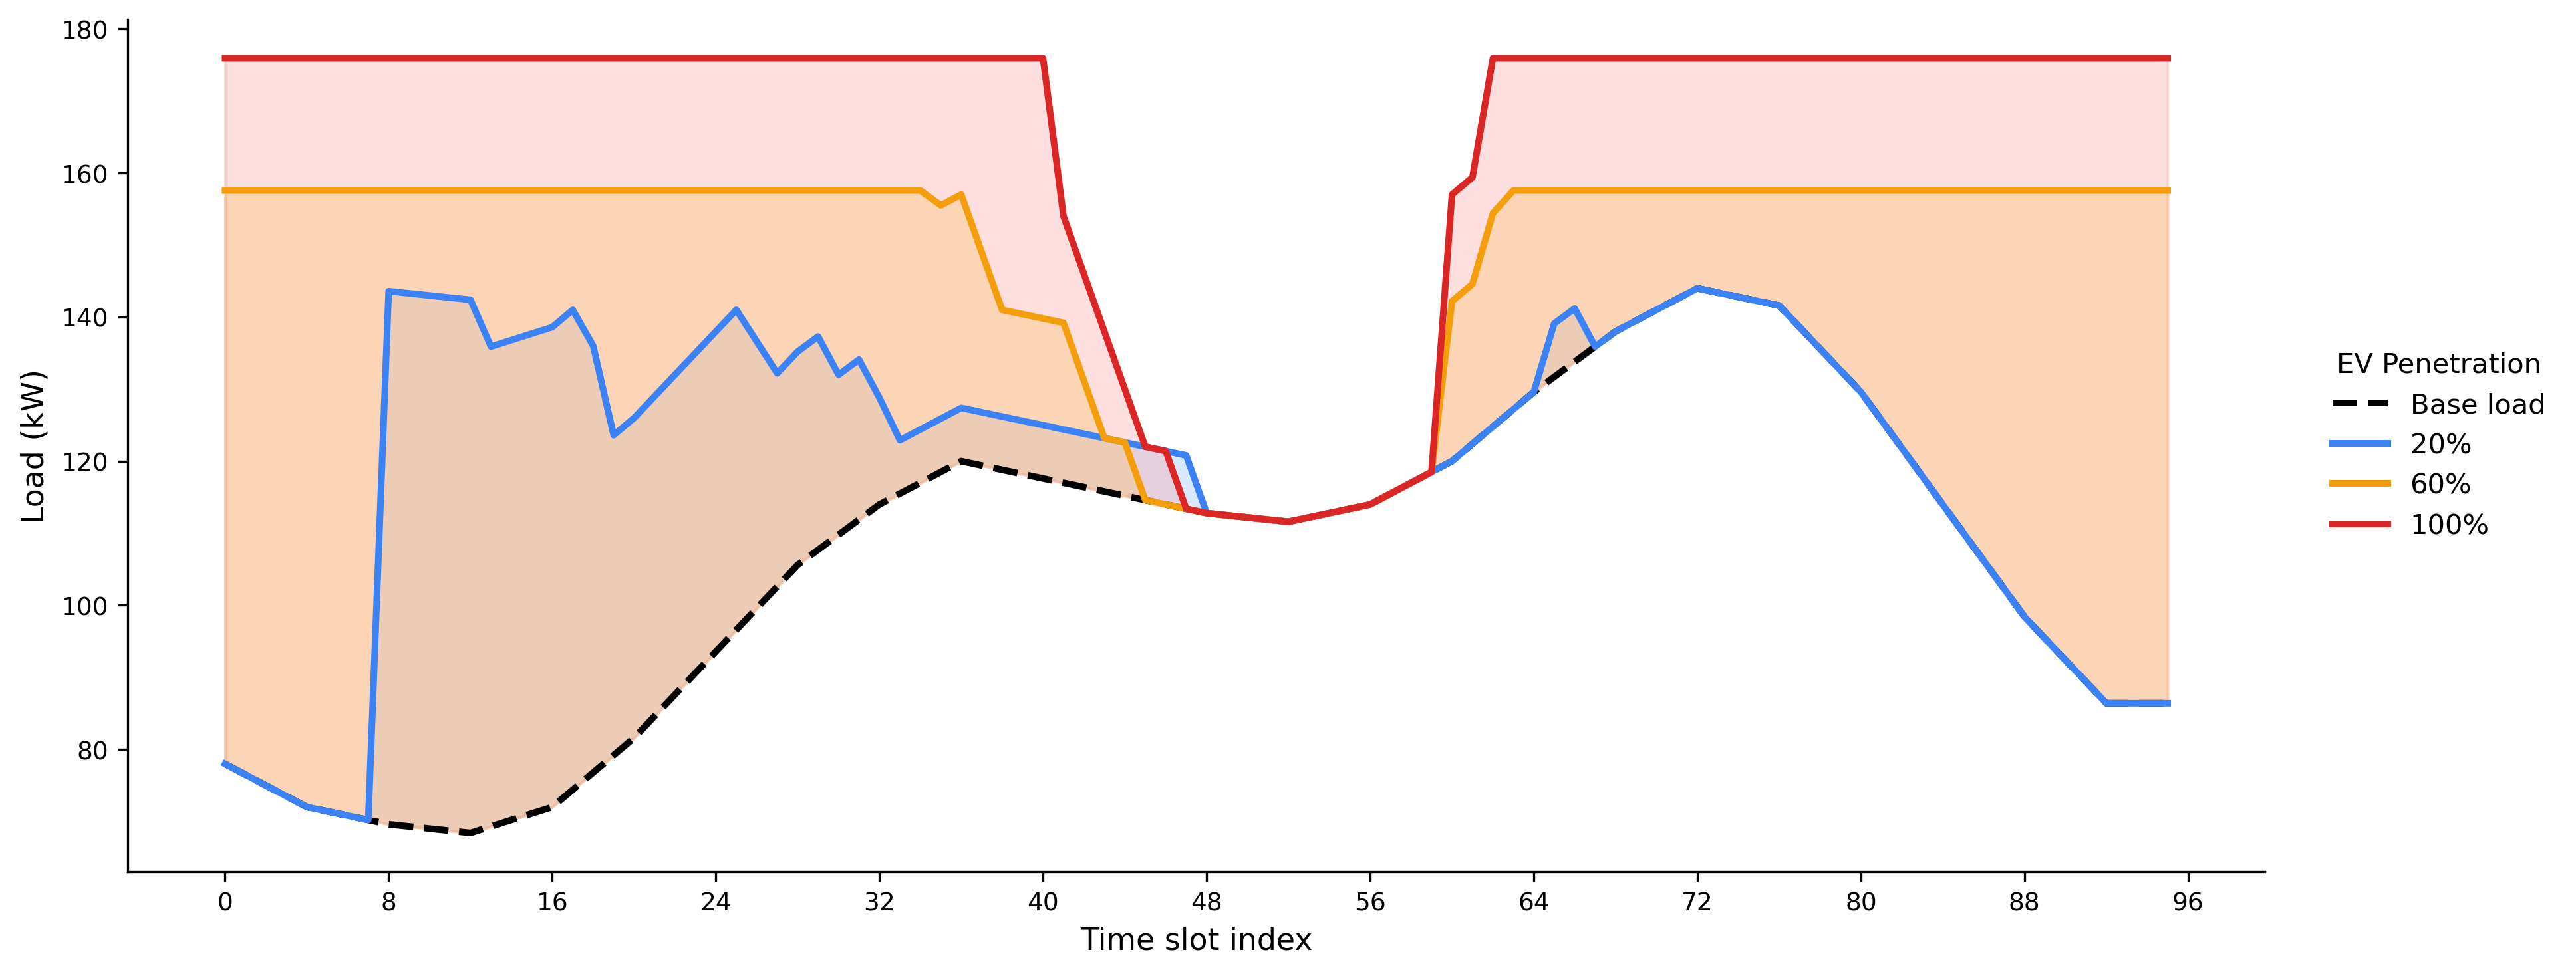

STEP 19 completed successfully.
Figure saved at: /Users/administrator/Desktop/All desktop-data/Prof Sahhi Project/Datasets and Results/Scientific Data/Dataset/Case-D/community_spm_load_styled.png


In [53]:
# ======================================================
# STEP 19: SPM load profiles (single plot with penetration)
# ======================================================

import matplotlib.pyplot as plt
import numpy as np
import os

SPM_LOAD_FIG = os.path.join(RESULTS_FOLDER, "community_spm_load_styled.png")

fig, ax = plt.subplots(figsize=(13, 5), dpi=300)

x = np.arange(N_SLOTS)
base_load_kw = df["community_load_kw"].values

# ------------------------------------------------------
# Base load
# ------------------------------------------------------
ax.plot(
    x,
    base_load_kw,
    linewidth=2.4,
    color="black",
    linestyle="--",
    label="Base load"
)

# ------------------------------------------------------
# Colors for lines and fills
# ------------------------------------------------------
pen_styles = {
    0.20: {"line": "#3B82F6", "fill": "#93C5FD"},
    0.60: {"line": "#F59E0B", "fill": "#FCD34D"},
    1.00: {"line": "#DC2626", "fill": "#FCA5A5"}
}

# ------------------------------------------------------
# Plot SPM loads with soft fill
# ------------------------------------------------------
for pen in [0.20, 0.60, 1.00]:
    if pen not in spm_profiles_by_pen:
        continue

    spm_ev_kw = spm_profiles_by_pen[pen]
    total_load_kw = base_load_kw + spm_ev_kw

    ax.fill_between(
        x,
        base_load_kw,
        total_load_kw,
        color=pen_styles[pen]["fill"],
        alpha=0.35
    )

    ax.plot(
        x,
        total_load_kw,
        linewidth=2.4,
        color=pen_styles[pen]["line"],
        label=f"{int(pen*100)}%"
    )

# ------------------------------------------------------
# Styling
# ------------------------------------------------------
ax.set_xlabel("Time slot index", fontsize=11)
ax.set_ylabel("Load (kW)", fontsize=11)

tick_positions = np.arange(0, 97, 8)
ax.set_xticks(tick_positions)
ax.set_xticklabels([str(i) for i in tick_positions], fontsize=9)

ax.tick_params(axis="y", labelsize=9)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(False)

ax.legend(
    title="EV Penetration",
    frameon=False,
    fontsize=10,
    title_fontsize=10,
    loc="center left",
    bbox_to_anchor=(1.02, 0.5)
)

plt.tight_layout()
plt.savefig(SPM_LOAD_FIG, dpi=300, bbox_inches="tight")
plt.show()

print("STEP 19 completed successfully.")
print("Figure saved at:", SPM_LOAD_FIG)

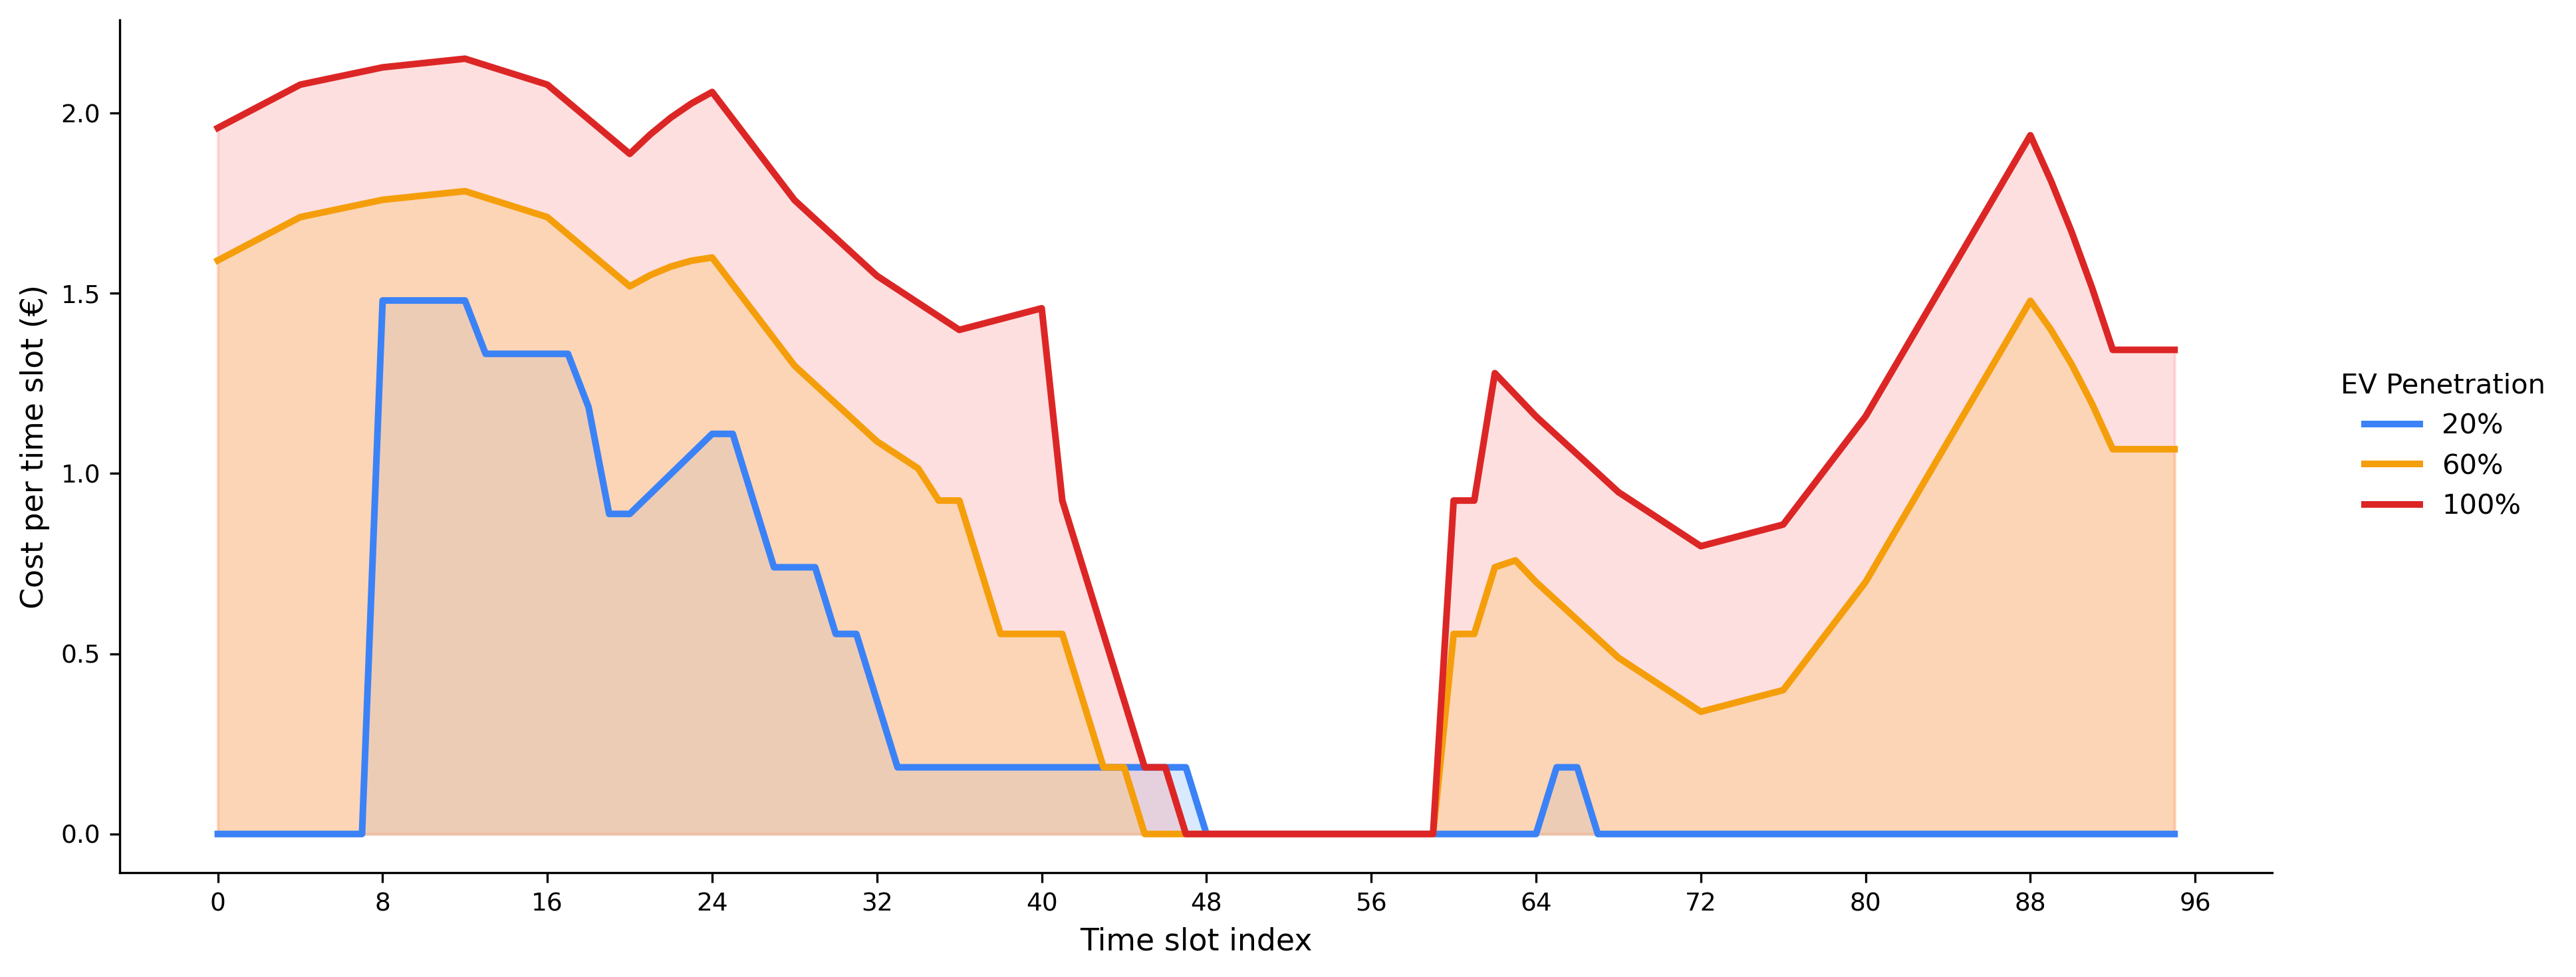

STEP 20 completed successfully.
Figure saved at: /Users/administrator/Desktop/All desktop-data/Prof Sahhi Project/Datasets and Results/Scientific Data/Dataset/Case-D/community_spm_cost_styled.png


In [54]:
# ======================================================
# STEP 20: SPM charging cost profiles (single plot with penetration)
# ======================================================

import matplotlib.pyplot as plt
import numpy as np
import os

SPM_COST_FIG = os.path.join(RESULTS_FOLDER, "community_spm_cost_styled.png")

fig, ax = plt.subplots(figsize=(13, 5), dpi=300)

x = np.arange(N_SLOTS)
rt_price = df["rt_price"].values

# ------------------------------------------------------
# Colors for lines and fills
# ------------------------------------------------------
pen_styles = {
    0.20: {"line": "#3B82F6", "fill": "#93C5FD"},
    0.60: {"line": "#F59E0B", "fill": "#FCD34D"},
    1.00: {"line": "#DC2626", "fill": "#FCA5A5"}
}

# ------------------------------------------------------
# Plot SPM slot-wise cost
# slot cost = EV load × real-time price × dt
# ------------------------------------------------------
for pen in [0.20, 0.60, 1.00]:
    if pen not in spm_profiles_by_pen:
        continue

    spm_ev_kw = spm_profiles_by_pen[pen]
    slot_cost = spm_ev_kw * rt_price * DT_HOURS

    ax.fill_between(
        x,
        0,
        slot_cost,
        color=pen_styles[pen]["fill"],
        alpha=0.35
    )

    ax.plot(
        x,
        slot_cost,
        linewidth=2.4,
        color=pen_styles[pen]["line"],
        label=f"{int(pen*100)}%"
    )

# ------------------------------------------------------
# Styling
# ------------------------------------------------------
ax.set_xlabel("Time slot index", fontsize=11)
ax.set_ylabel("Cost per time slot (€)", fontsize=11)

tick_positions = np.arange(0, 97, 8)
ax.set_xticks(tick_positions)
ax.set_xticklabels([str(i) for i in tick_positions], fontsize=9)

ax.tick_params(axis="y", labelsize=9)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(False)

ax.legend(
    title="EV Penetration",
    frameon=False,
    fontsize=10,
    title_fontsize=10,
    loc="center left",
    bbox_to_anchor=(1.02, 0.5)
)

plt.tight_layout()
plt.savefig(SPM_COST_FIG, dpi=300, bbox_inches="tight")
plt.show()

print("STEP 20 completed successfully.")
print("Figure saved at:", SPM_COST_FIG)

In [55]:
# ======================================================
# STEP 21: Community-level MOCHF-IoEVs
# ======================================================

import numpy as np
import pandas as pd
import os

from pymoo.core.problem import Problem
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.optimize import minimize
from pymoo.termination import get_termination

# ------------------------------------------------------
# Define multi-objective problem
# ------------------------------------------------------
class CommunityMOCHFProblem(Problem):
    def __init__(self, base_load_kw, available_power_kw, rt_price, total_required_energy):
        self.base_load_kw = base_load_kw
        self.available_power_kw = available_power_kw
        self.rt_price = rt_price
        self.total_required_energy = total_required_energy

        xl = np.zeros(len(available_power_kw))
        xu = available_power_kw.copy()

        super().__init__(
            n_var=len(available_power_kw),
            n_obj=2,
            n_constr=1,
            xl=xl,
            xu=xu
        )

    def _evaluate(self, X, out, *args, **kwargs):
        # Objective 1: charging cost
        f1 = np.sum(X * self.rt_price * DT_HOURS, axis=1)

        # Objective 2: peak total load
        total_kw = X + self.base_load_kw[None, :]
        f2 = np.max(total_kw, axis=1)

        # Constraint: delivered energy must meet required energy
        delivered = np.sum(X * DT_HOURS * ETA, axis=1)
        g1 = self.total_required_energy - delivered

        out["F"] = np.column_stack([f1, f2])
        out["G"] = np.column_stack([g1])

# ------------------------------------------------------
# Solve MOCHF-IoEVs and pick a compromise solution
# ------------------------------------------------------
def run_mochf_schedule(base_load_kw, available_power_kw, rt_price, total_required_energy):
    problem = CommunityMOCHFProblem(
        base_load_kw=base_load_kw,
        available_power_kw=available_power_kw,
        rt_price=rt_price,
        total_required_energy=total_required_energy
    )

    algorithm = NSGA2(pop_size=150)
    termination = get_termination("n_gen", 200)

    res = minimize(
        problem,
        algorithm,
        termination,
        seed=42,
        save_history=True,
        verbose=False
    )

    F = res.F
    X = res.X

    # Normalize and choose balanced compromise point
    F_norm = (F - F.min(axis=0)) / (F.max(axis=0) - F.min(axis=0) + 1e-12)
    idx_compromise = np.argmin(np.sum(F_norm, axis=1))

    chosen_profile = X[idx_compromise]

    # Convergence history
    history_best_cost = []
    history_best_peak = []

    for algo in res.history:
        pop_F = algo.pop.get("F")
        history_best_cost.append(np.min(pop_F[:, 0]))
        history_best_peak.append(np.min(pop_F[:, 1]))

    return chosen_profile, F, X, history_best_cost, history_best_peak

# ------------------------------------------------------
# Run MOCHF-IoEVs for each penetration level
# ------------------------------------------------------
mochf_profiles_by_pen = {}
mochf_rows = []
mochf_outputs = {}

for pen, info in community_inputs.items():
    total_required_energy = info["TotalRequiredEnergy_kWh"]
    available_power_kw = info["AvailablePower_kW"]
    base_load_kw = info["BaseLoad_kW"]
    rt_price = info["RT_Price"]

    if not info["Feasible"]:
        print(f"Skipping MOCHF-IoEVs for {int(pen*100)}% penetration (infeasible).")
        continue

    ev_kw, F, X, hist_cost, hist_peak = run_mochf_schedule(
        base_load_kw=base_load_kw,
        available_power_kw=available_power_kw,
        rt_price=rt_price,
        total_required_energy=total_required_energy
    )

    total_kw = base_load_kw + ev_kw
    delivered_energy = np.sum(ev_kw * DT_HOURS * ETA)
    charging_cost = np.sum(ev_kw * rt_price * DT_HOURS)

    mochf_profiles_by_pen[pen] = ev_kw
    mochf_outputs[pen] = {
        "pareto_F": F,
        "pareto_X": X,
        "hist_cost": hist_cost,
        "hist_peak": hist_peak
    }

    mochf_rows.append({
        "Penetration": pen,
        "Method": "MOCHF-IoEVs",
        "NumEVs": info["NumEVs"],
        "RequiredEnergy_kWh": total_required_energy,
        "DeliveredEnergy_kWh": delivered_energy,
        "ChargingCost": charging_cost,
        "PeakTotalLoad_kW": np.max(total_kw),
        "Completed": delivered_energy + 1e-6 >= total_required_energy
    })

mochf_results_df = pd.DataFrame(mochf_rows)

if len(mochf_results_df) > 0:
    mochf_results_df = mochf_results_df.round({
        "RequiredEnergy_kWh": 3,
        "DeliveredEnergy_kWh": 3,
        "ChargingCost": 3,
        "PeakTotalLoad_kW": 3
    })

# ------------------------------------------------------
# Save results
# ------------------------------------------------------
mochf_results_file = os.path.join(RESULTS_FOLDER, "community_mochf_results.csv")
mochf_results_df.to_csv(mochf_results_file, index=False)

print("STEP 21 completed successfully.")
print("Saved MOCHF-IoEVs results to:", mochf_results_file)
mochf_results_df


STEP 21 completed successfully.
Saved MOCHF-IoEVs results to: /Users/administrator/Desktop/All desktop-data/Prof Sahhi Project/Datasets and Results/Scientific Data/Dataset/Case-D/community_mochf_results.csv


,Penetration,Method,NumEVs,RequiredEnergy_kWh,DeliveredEnergy_kWh,ChargingCost,PeakTotalLoad_kW,Completed
0,0.2,MOCHF-IoEVs,10,262.656,262.719,21.911,145.638,True
1,0.6,MOCHF-IoEVs,30,963.769,966.799,83.284,221.262,True
2,1.0,MOCHF-IoEVs,50,1329.524,1330.173,115.027,282.315,True


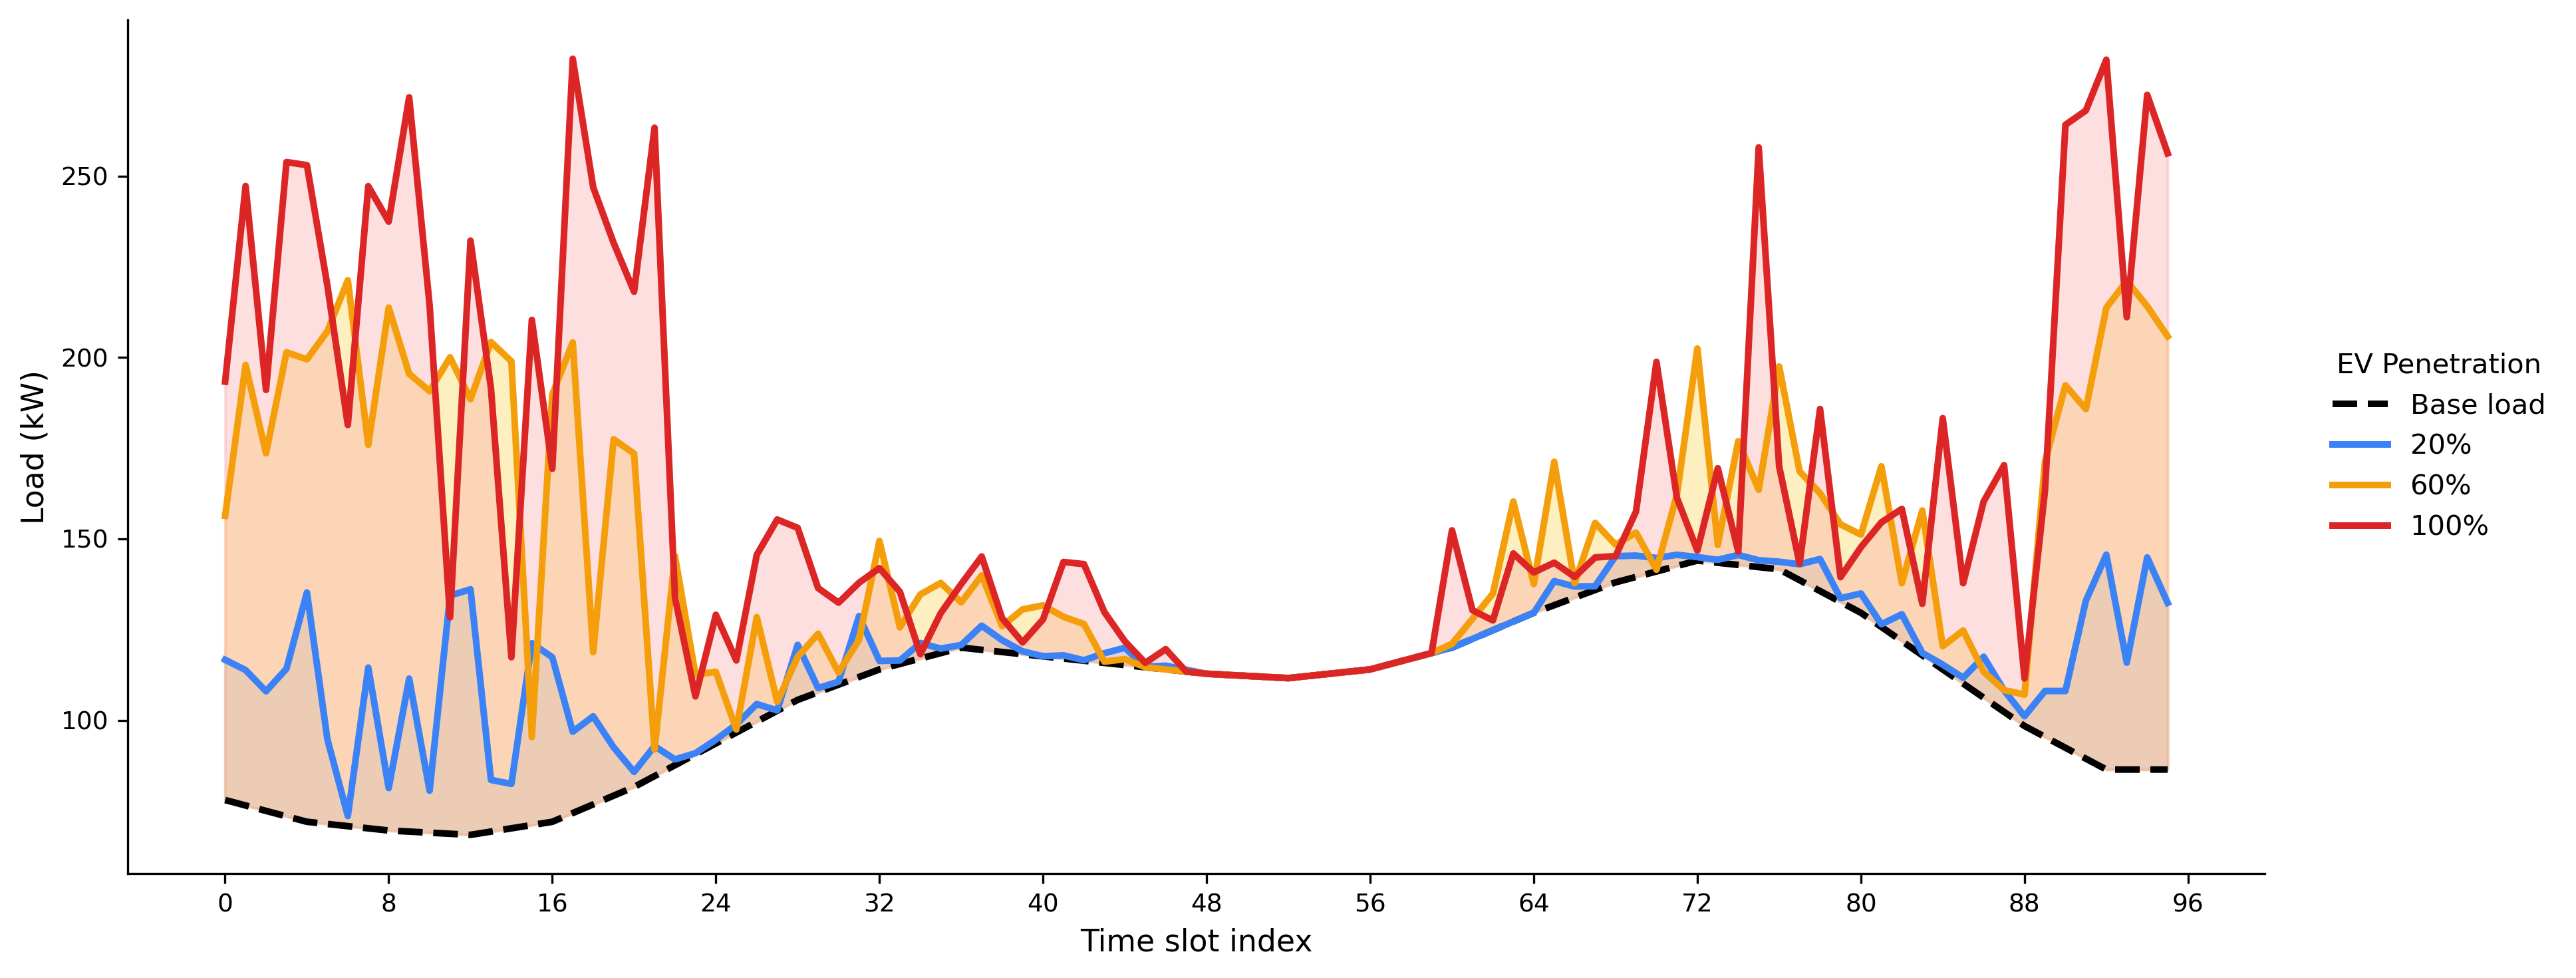

STEP 22 completed successfully.
Figure saved at: /Users/administrator/Desktop/All desktop-data/Prof Sahhi Project/Datasets and Results/Scientific Data/Dataset/Case-D/community_mochf_load_styled.png


In [56]:
# ======================================================
# STEP 22: MOCHF-IoEVs load profiles (single plot with penetration)
# ======================================================

import matplotlib.pyplot as plt
import numpy as np
import os

MOCHF_LOAD_FIG = os.path.join(RESULTS_FOLDER, "community_mochf_load_styled.png")

fig, ax = plt.subplots(figsize=(13, 5), dpi=300)

x = np.arange(N_SLOTS)
base_load_kw = df["community_load_kw"].values

# ------------------------------------------------------
# Base load
# ------------------------------------------------------
ax.plot(
    x,
    base_load_kw,
    linewidth=2.4,
    color="black",
    linestyle="--",
    label="Base load"
)

# ------------------------------------------------------
# Colors for lines and fills
# ------------------------------------------------------
pen_styles = {
    0.20: {"line": "#3B82F6", "fill": "#93C5FD"},
    0.60: {"line": "#F59E0B", "fill": "#FCD34D"},
    1.00: {"line": "#DC2626", "fill": "#FCA5A5"}
}

# ------------------------------------------------------
# Plot MOCHF-IoEVs loads with soft fill
# ------------------------------------------------------
for pen in [0.20, 0.60, 1.00]:
    if pen not in mochf_profiles_by_pen:
        continue

    mochf_ev_kw = mochf_profiles_by_pen[pen]
    total_load_kw = base_load_kw + mochf_ev_kw

    ax.fill_between(
        x,
        base_load_kw,
        total_load_kw,
        color=pen_styles[pen]["fill"],
        alpha=0.35
    )

    ax.plot(
        x,
        total_load_kw,
        linewidth=2.4,
        color=pen_styles[pen]["line"],
        label=f"{int(pen*100)}%"
    )

# ------------------------------------------------------
# Styling
# ------------------------------------------------------
ax.set_xlabel("Time slot index", fontsize=11)
ax.set_ylabel("Load (kW)", fontsize=11)

tick_positions = np.arange(0, 97, 8)
ax.set_xticks(tick_positions)
ax.set_xticklabels([str(i) for i in tick_positions], fontsize=9)

ax.tick_params(axis="y", labelsize=9)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(False)

ax.legend(
    title="EV Penetration",
    frameon=False,
    fontsize=10,
    title_fontsize=10,
    loc="center left",
    bbox_to_anchor=(1.02, 0.5)
)

plt.tight_layout()
plt.savefig(MOCHF_LOAD_FIG, dpi=300, bbox_inches="tight")
plt.show()

print("STEP 22 completed successfully.")
print("Figure saved at:", MOCHF_LOAD_FIG)

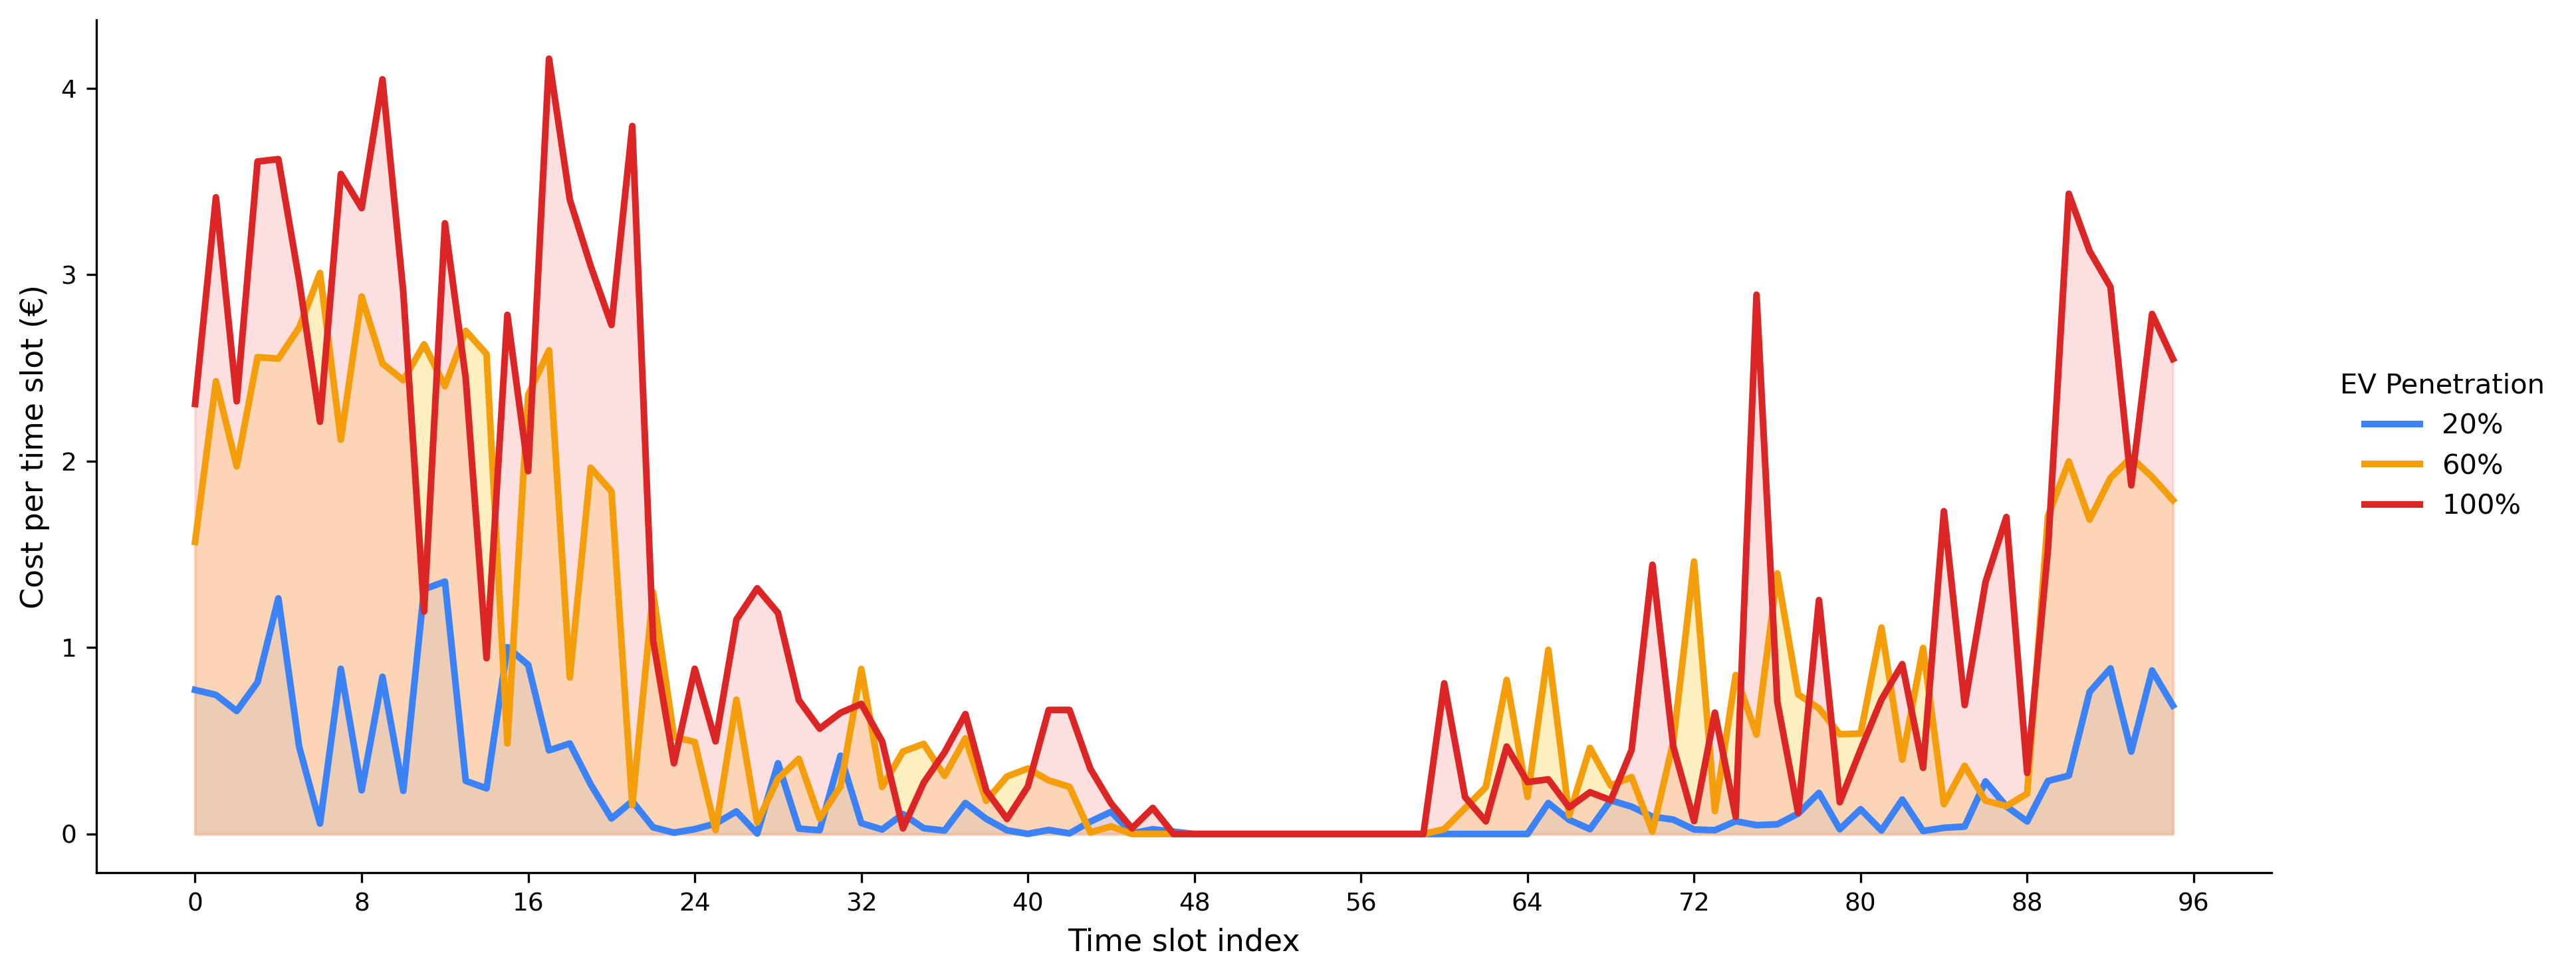

STEP 23 completed successfully.
Figure saved at: /Users/administrator/Desktop/All desktop-data/Prof Sahhi Project/Datasets and Results/Scientific Data/Dataset/Case-D/community_mochf_cost_styled.png


In [32]:
# ======================================================
# STEP 23: MOCHF-IoEVs charging cost profiles
# ======================================================

import matplotlib.pyplot as plt
import numpy as np
import os

MOCHF_COST_FIG = os.path.join(RESULTS_FOLDER, "community_mochf_cost_styled.png")

fig, ax = plt.subplots(figsize=(13, 5), dpi=300)

x = np.arange(N_SLOTS)
rt_price = df["rt_price"].values

# ------------------------------------------------------
# Colors for lines and fills
# ------------------------------------------------------
pen_styles = {
    0.20: {"line": "#3B82F6", "fill": "#93C5FD"},
    0.60: {"line": "#F59E0B", "fill": "#FCD34D"},
    1.00: {"line": "#DC2626", "fill": "#FCA5A5"}
}

# ------------------------------------------------------
# Plot MOCHF-IoEVs slot-wise cost
# slot cost = EV load × real-time price × dt
# ------------------------------------------------------
for pen in [0.20, 0.60, 1.00]:
    if pen not in mochf_profiles_by_pen:
        continue

    mochf_ev_kw = mochf_profiles_by_pen[pen]
    slot_cost = mochf_ev_kw * rt_price * DT_HOURS

    ax.fill_between(
        x,
        0,
        slot_cost,
        color=pen_styles[pen]["fill"],
        alpha=0.35
    )

    ax.plot(
        x,
        slot_cost,
        linewidth=2.4,
        color=pen_styles[pen]["line"],
        label=f"{int(pen*100)}%"
    )

# ------------------------------------------------------
# Styling
# ------------------------------------------------------
ax.set_xlabel("Time slot index", fontsize=11)
ax.set_ylabel("Cost per time slot (€)", fontsize=11)

tick_positions = np.arange(0, 97, 8)
ax.set_xticks(tick_positions)
ax.set_xticklabels([str(i) for i in tick_positions], fontsize=9)

ax.tick_params(axis="y", labelsize=9)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(False)

ax.legend(
    title="EV Penetration",
    frameon=False,
    fontsize=10,
    title_fontsize=10,
    loc="center left",
    bbox_to_anchor=(1.02, 0.5)
)

plt.tight_layout()
plt.savefig(MOCHF_COST_FIG, dpi=300, bbox_inches="tight")
plt.show()

print("STEP 23 completed successfully.")
print("Figure saved at:", MOCHF_COST_FIG)

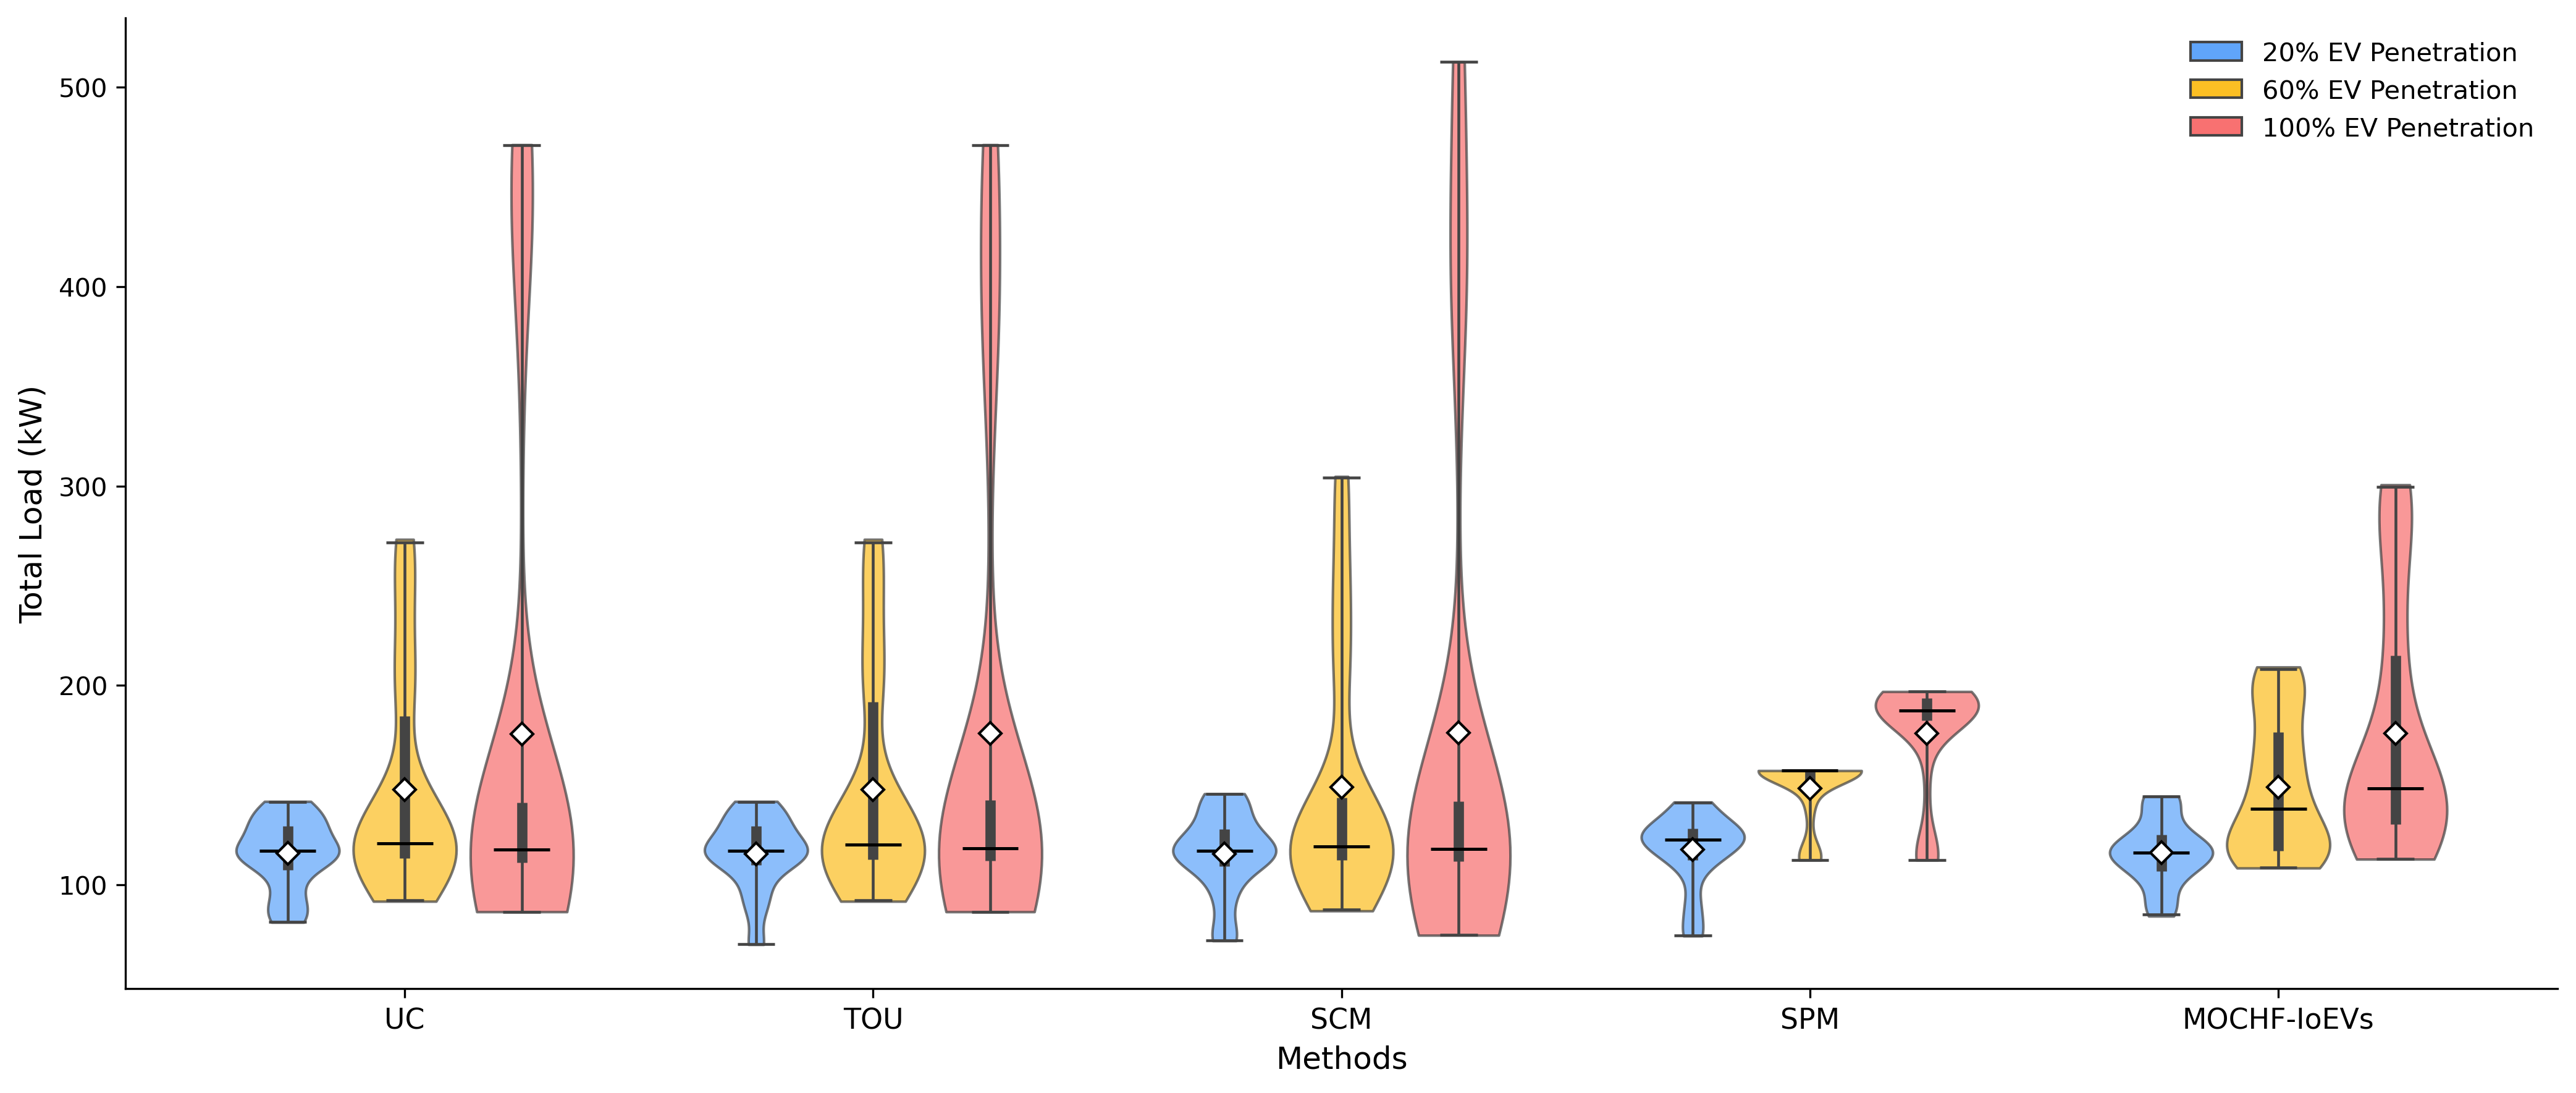

Truncated violin plot completed successfully.
Figure saved at: /Users/administrator/Desktop/All desktop-data/Prof Sahhi Project/Datasets and Results/Scientific Data/Dataset/Case-D/all_methods_penetration_truncated_violin.png


In [59]:
# ======================================================
# STEP 20: Truncated violin plot from CSV (Methods vs Penetration)
# Mean shown in plot, not shown in legend
# ======================================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
from matplotlib.patches import Patch

# ------------------------------------------------------
# File path
# ------------------------------------------------------
FILE_PATH = "/Users/administrator/Desktop/All desktop-data/Prof Sahhi Project/Datasets and Results/Scientific Data/Dataset/Case-D/aggregatedload.csv"

VIOLIN_FIG = os.path.join(
    os.path.dirname(FILE_PATH),
    "all_methods_penetration_truncated_violin.png"
)

# ------------------------------------------------------
# Load CSV
# ------------------------------------------------------
df = pd.read_csv(FILE_PATH)

# ------------------------------------------------------
# Settings
# ------------------------------------------------------
methods = ["UC", "TOU", "SCM", "SPM", "MOCHF-IoEVs"]
penetrations = [0.2, 0.6, 1.0]

pen_colors = {
    0.2: "#60A5FA",
    0.6: "#FBBF24",
    1.0: "#F87171"
}

group_centers = np.arange(1, len(methods) + 1)
offsets = [-0.25, 0.00, 0.25]

data = []
positions = []
colors = []

# ------------------------------------------------------
# Prepare data from CSV
# ------------------------------------------------------
for i, method in enumerate(methods):
    center = group_centers[i]

    for offset, pen in zip(offsets, penetrations):
        subset = df[(df["Method"] == method) & (df["Penetration"] == pen)]

        if subset.empty:
            continue

        total_load = subset["TotalLoad_kW"].values

        # truncate extreme tails using 5th and 95th percentile
        low = np.percentile(total_load, 5)
        high = np.percentile(total_load, 95)
        total_load_truncated = np.clip(total_load, low, high)

        data.append(total_load_truncated)
        positions.append(center + offset)
        colors.append(pen_colors[pen])

# ------------------------------------------------------
# Plot
# ------------------------------------------------------
fig, ax = plt.subplots(figsize=(14, 6), dpi=300)

vp = ax.violinplot(
    data,
    positions=positions,
    widths=0.22,
    showmeans=False,
    showmedians=False,
    showextrema=False
)

# ------------------------------------------------------
# Apply colors to violins
# ------------------------------------------------------
for body, color in zip(vp["bodies"], colors):
    body.set_facecolor(color)
    body.set_edgecolor("#444444")
    body.set_alpha(0.72)
    body.set_linewidth(1.0)

# ------------------------------------------------------
# Add quartile, whisker, median, and mean lines
# ------------------------------------------------------
for pos, arr in zip(positions, data):
    q1 = np.percentile(arr, 25)
    median = np.percentile(arr, 50)
    q3 = np.percentile(arr, 75)
    low = np.percentile(arr, 5)
    high = np.percentile(arr, 95)
    mean_val = np.mean(arr)

    # central vertical whisker line
    ax.vlines(pos, low, high, color="#444444", linewidth=1.1, zorder=3)

    # box-like quartile bar
    ax.vlines(pos, q1, q3, color="#444444", linewidth=4.0, zorder=4)

    # whisker caps
    ax.hlines([low, high], pos - 0.04, pos + 0.04, color="#444444", linewidth=1.1, zorder=4)

    # median line
    ax.hlines(median, pos - 0.06, pos + 0.06, color="black", linewidth=1.2, zorder=5)

    # mean marker kept in plot
    ax.plot(
        pos,
        mean_val,
        marker="D",
        markersize=6,
        markerfacecolor="white",
        markeredgecolor="black",
        linestyle="None",
        zorder=6
    )

# ------------------------------------------------------
# Styling
# ------------------------------------------------------
ax.set_xticks(group_centers)
ax.set_xticklabels(methods, fontsize=11)

ax.set_xlabel("Methods", fontsize=12)
ax.set_ylabel("Total Load (kW)", fontsize=12)

ax.tick_params(axis="y", labelsize=10)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(False)

# ------------------------------------------------------
# Legend (penetration only)
# ------------------------------------------------------
legend_handles = [
    Patch(facecolor=pen_colors[0.2], edgecolor="#444444", label="20% EV Penetration"),
    Patch(facecolor=pen_colors[0.6], edgecolor="#444444", label="60% EV Penetration"),
    Patch(facecolor=pen_colors[1.0], edgecolor="#444444", label="100% EV Penetration")
]

ax.legend(
    handles=legend_handles,
    frameon=False,
    fontsize=10,
    loc="upper right"
)

plt.tight_layout()
plt.savefig(VIOLIN_FIG, dpi=300, bbox_inches="tight")
plt.show()

print("Truncated violin plot completed successfully.")
print("Figure saved at:", VIOLIN_FIG)

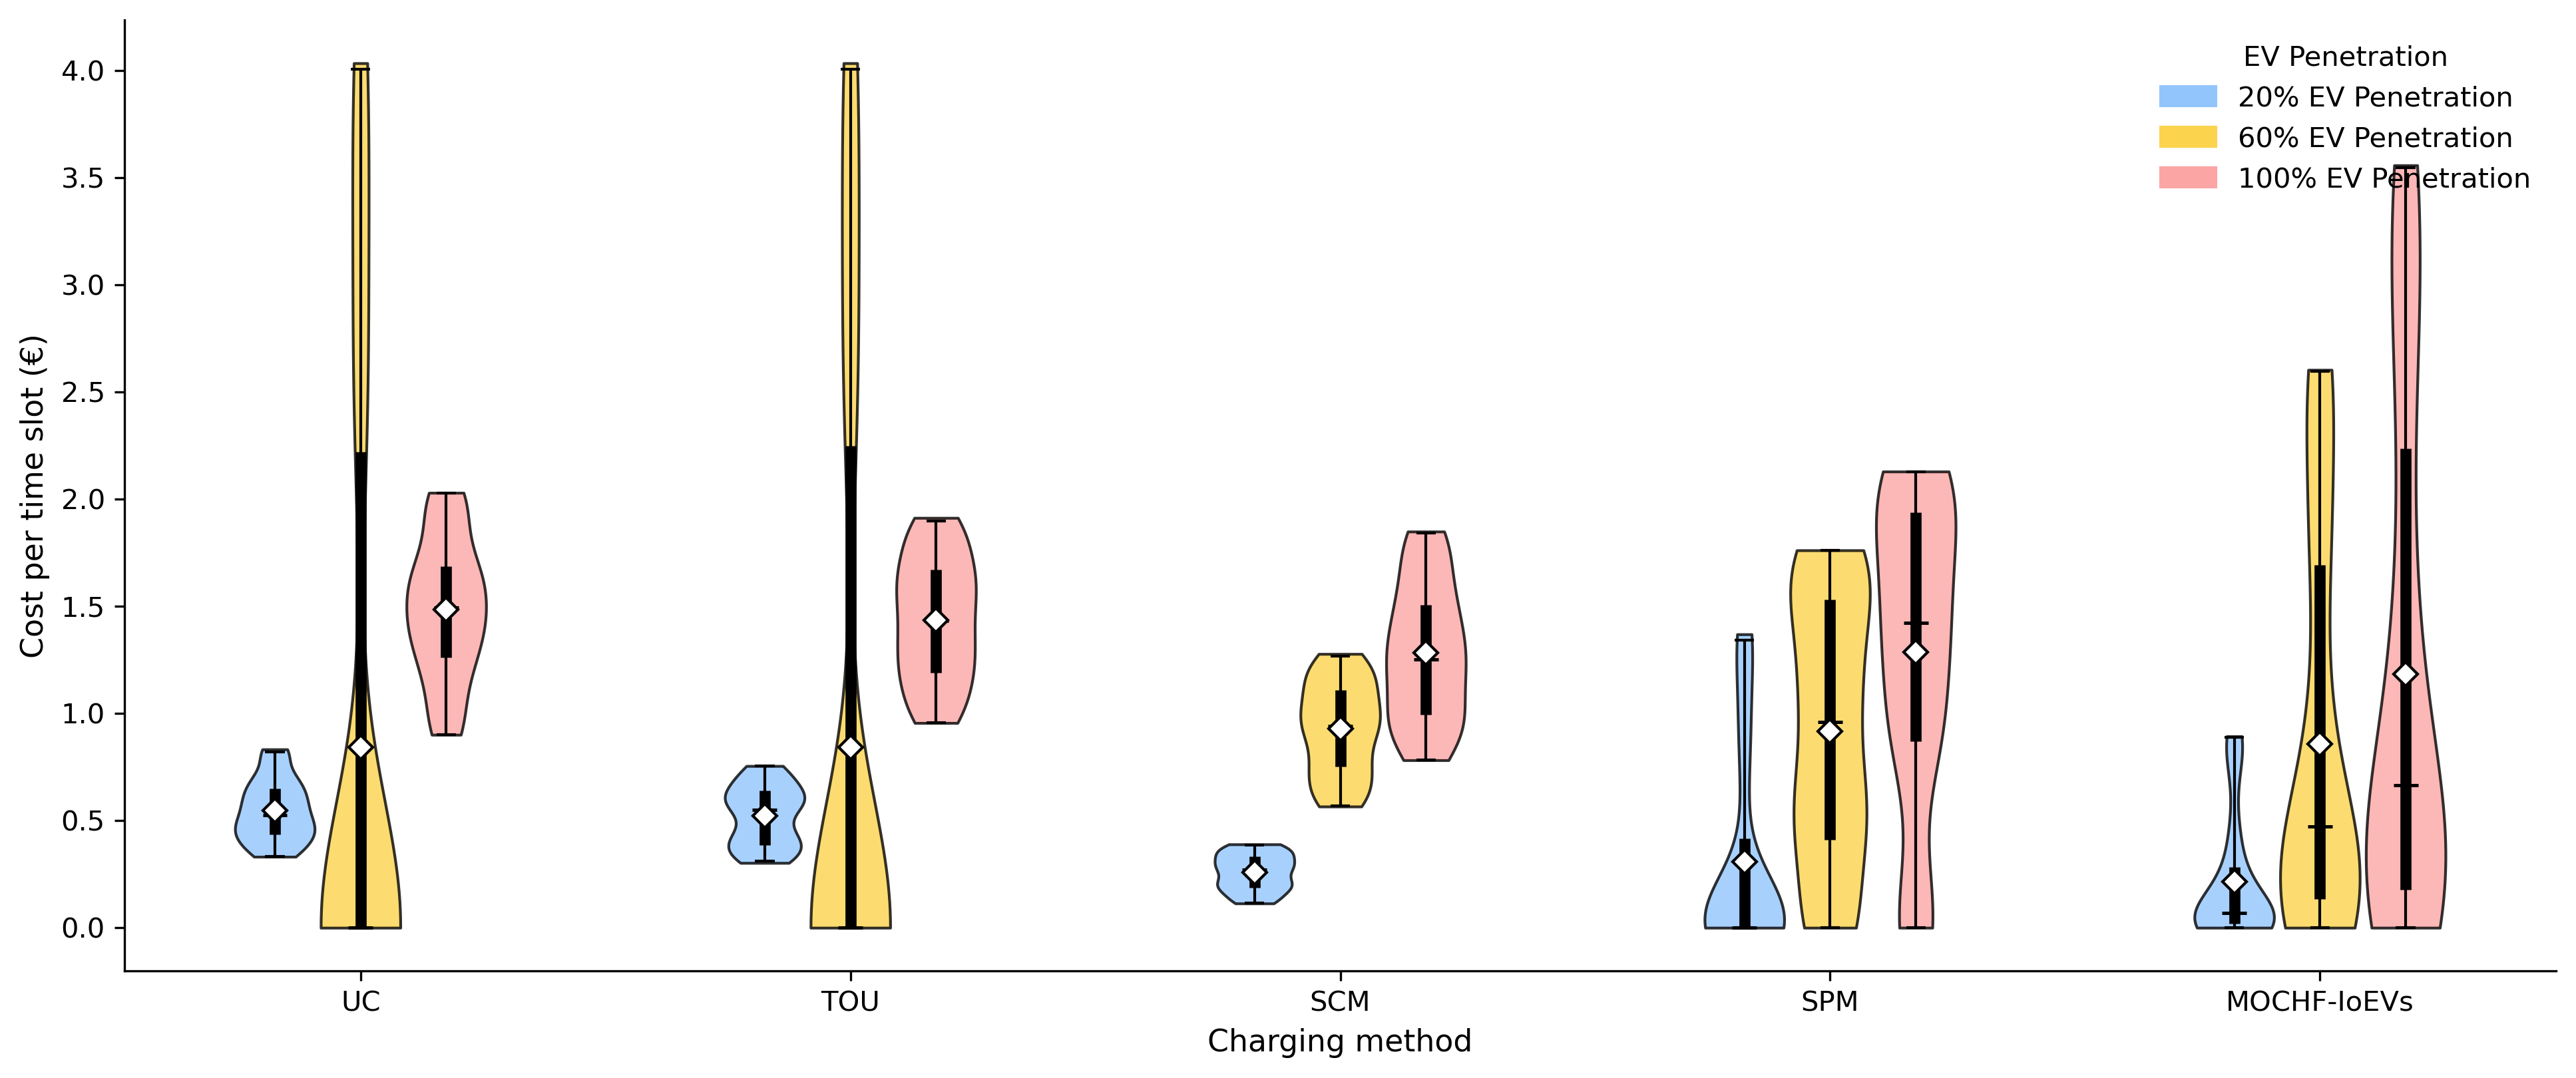

STEP 21 completed successfully.
Figure saved at: /Users/administrator/Desktop/All desktop-data/Prof Sahhi Project/Datasets and Results/Scientific Data/Dataset/Case-D/community_cost_truncated_violin.png


In [61]:
# ======================================================
# STEP 21: Truncated violin plot for cost
# Mean shown in plot, not shown in legend
# ======================================================

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import os

# ------------------------------------------------------
# File path
# ------------------------------------------------------
FILE_PATH = "/Users/administrator/Desktop/All desktop-data/Prof Sahhi Project/Datasets and Results/Scientific Data/Dataset/Case-D/aggregatedcost.csv"

COST_VIOLIN_FIG = os.path.join(
    os.path.dirname(FILE_PATH),
    "community_cost_truncated_violin.png"
)

# ------------------------------------------------------
# Load CSV
# ------------------------------------------------------
df = pd.read_csv(FILE_PATH)

methods = ["UC", "TOU", "SCM", "SPM", "MOCHF-IoEVs"]
penetrations = [0.2, 0.6, 1.0]

pen_colors = {
    0.2: "#93C5FD",
    0.6: "#FCD34D",
    1.0: "#FCA5A5"
}

# ------------------------------------------------------
# Prepare data
# ------------------------------------------------------
violin_data = []
positions = []
colors = []

group_centers = np.arange(len(methods)) * 4.0
offsets = [-0.7, 0.0, 0.7]

for i, method in enumerate(methods):
    for j, pen in enumerate(penetrations):
        subset = df[
            (df["Method"] == method) &
            (df["Penetration"] == pen)
        ]

        if subset.empty:
            continue

        cost_slots = subset["SlotCost_EUR"].values

        # truncate tails to make the violin cleaner
        low = np.percentile(cost_slots, 5)
        high = np.percentile(cost_slots, 95)
        cost_truncated = np.clip(cost_slots, low, high)

        violin_data.append(cost_truncated)
        positions.append(group_centers[i] + offsets[j])
        colors.append(pen_colors[pen])

# ------------------------------------------------------
# Plot
# ------------------------------------------------------
fig, ax = plt.subplots(figsize=(13, 5.5), dpi=300)

vp = ax.violinplot(
    violin_data,
    positions=positions,
    widths=0.65,
    showmeans=False,
    showmedians=False,
    showextrema=False
)

# ------------------------------------------------------
# Color violins
# ------------------------------------------------------
for body, color in zip(vp["bodies"], colors):
    body.set_facecolor(color)
    body.set_edgecolor("black")
    body.set_alpha(0.80)
    body.set_linewidth(1.0)

# ------------------------------------------------------
# Add quartiles, whiskers, median, and mean
# ------------------------------------------------------
for pos, arr in zip(positions, violin_data):
    q1 = np.percentile(arr, 25)
    median = np.percentile(arr, 50)
    q3 = np.percentile(arr, 75)
    low = np.percentile(arr, 5)
    high = np.percentile(arr, 95)
    mean_val = np.mean(arr)

    # whisker line
    ax.vlines(pos, low, high, color="black", linewidth=1.0, zorder=3)

    # thicker IQR bar
    ax.vlines(pos, q1, q3, color="black", linewidth=4.0, zorder=4)

    # whisker caps
    ax.hlines([low, high], pos - 0.08, pos + 0.08, color="black", linewidth=1.0, zorder=4)

    # median line
    ax.hlines(median, pos - 0.10, pos + 0.10, color="black", linewidth=1.2, zorder=5)

    # mean marker shown in plot only
    ax.plot(
        pos,
        mean_val,
        marker="D",
        markersize=6,
        markerfacecolor="white",
        markeredgecolor="black",
        linestyle="None",
        zorder=6
    )

# ------------------------------------------------------
# Labels
# ------------------------------------------------------
ax.set_xticks(group_centers)
ax.set_xticklabels(methods, fontsize=10)

ax.set_xlabel("Charging method", fontsize=11)
ax.set_ylabel("Cost per time slot (€)", fontsize=11)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(False)

# ------------------------------------------------------
# Legend (penetration only)
# ------------------------------------------------------
legend_handles = [
    mpatches.Patch(color=pen_colors[0.2], label="20% EV Penetration"),
    mpatches.Patch(color=pen_colors[0.6], label="60% EV Penetration"),
    mpatches.Patch(color=pen_colors[1.0], label="100% EV Penetration")
]

ax.legend(
    handles=legend_handles,
    title="EV Penetration",
    frameon=False,
    fontsize=10,
    title_fontsize=10,
    loc="upper right"
)

plt.tight_layout()
plt.savefig(COST_VIOLIN_FIG, dpi=300, bbox_inches="tight")
plt.show()

print("STEP 21 completed successfully.")
print("Figure saved at:", COST_VIOLIN_FIG)

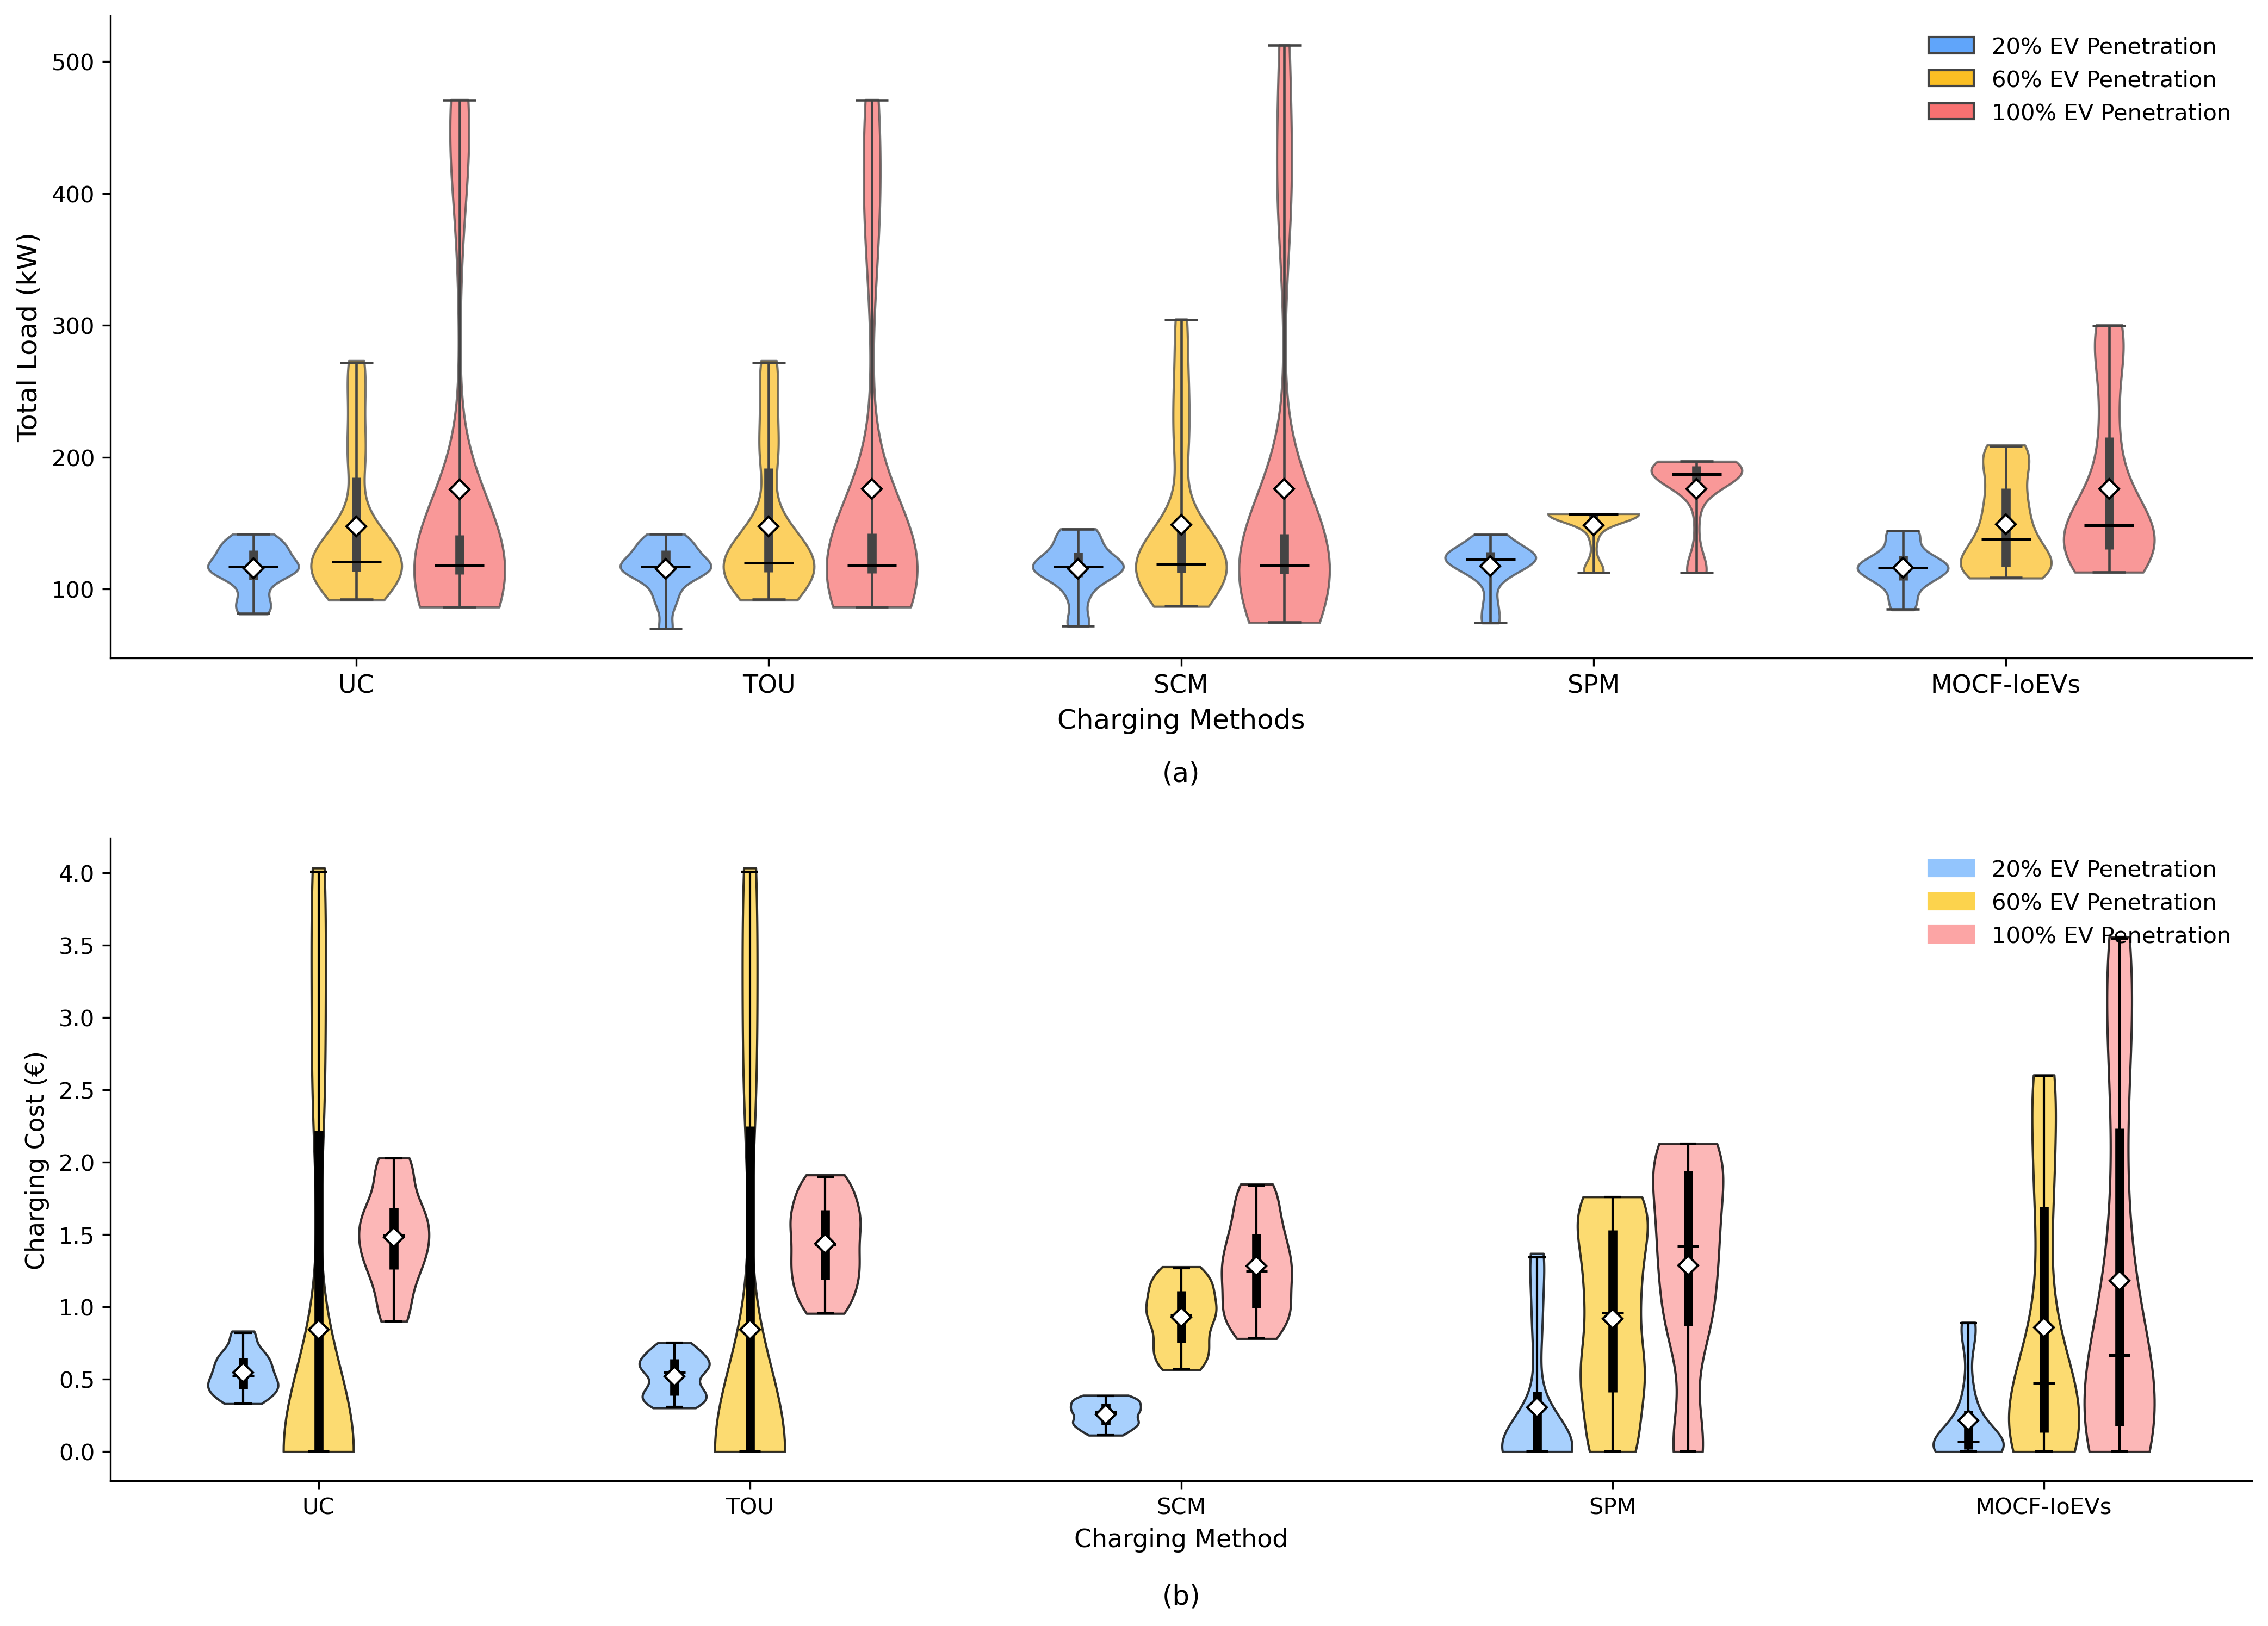

In [72]:
# ======================================================
# COMBINED FIGURE: (a) Load violin plot + (b) Cost violin plot
# Top row: Load
# Bottom row: Cost
# Separate legends for each subplot
# No subplot titles
# (a) and (b) placed below x-axis
# ======================================================

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import os
from matplotlib.patches import Patch

# ------------------------------------------------------
# File paths
# ------------------------------------------------------
LOAD_FILE_PATH = "/Users/administrator/Desktop/All desktop-data/Prof Sahhi Project/Datasets and Results/Scientific Data/Dataset/Case-D/aggregatedload.csv"
COST_FILE_PATH = "/Users/administrator/Desktop/All desktop-data/Prof Sahhi Project/Datasets and Results/Scientific Data/Dataset/Case-D/aggregatedcost.csv"

COMBINED_FIG = os.path.join(
    os.path.dirname(LOAD_FILE_PATH),
    "combined_load_cost_truncated_violin.png"
)

# ------------------------------------------------------
# Load data
# ------------------------------------------------------
df_load = pd.read_csv(LOAD_FILE_PATH)
df_cost = pd.read_csv(COST_FILE_PATH)

methods = ["UC", "TOU", "SCM", "SPM", "MOCF-IoEVs"]
penetrations = [0.2, 0.6, 1.0]

load_colors = {
    0.2: "#60A5FA",
    0.6: "#FBBF24",
    1.0: "#F87171"
}

cost_colors = {
    0.2: "#93C5FD",
    0.6: "#FCD34D",
    1.0: "#FCA5A5"
}

# ------------------------------------------------------
# Figure and axes
# ------------------------------------------------------
fig, axes = plt.subplots(2, 1, figsize=(14, 10), dpi=300)
ax1, ax2 = axes

# ======================================================
# (a) LOAD PLOT
# ======================================================
group_centers_load = np.arange(1, len(methods) + 1)
offsets_load = [-0.25, 0.00, 0.25]

load_data = []
load_positions = []
load_body_colors = []

for i, method in enumerate(methods):
    center = group_centers_load[i]

    for offset, pen in zip(offsets_load, penetrations):
        subset = df_load[
            (df_load["Method"] == method) &
            (df_load["Penetration"] == pen)
        ]

        if subset.empty:
            continue

        total_load = subset["TotalLoad_kW"].values

        low = np.percentile(total_load, 5)
        high = np.percentile(total_load, 95)
        total_load_truncated = np.clip(total_load, low, high)

        load_data.append(total_load_truncated)
        load_positions.append(center + offset)
        load_body_colors.append(load_colors[pen])

vp1 = ax1.violinplot(
    load_data,
    positions=load_positions,
    widths=0.22,
    showmeans=False,
    showmedians=False,
    showextrema=False
)

for body, color in zip(vp1["bodies"], load_body_colors):
    body.set_facecolor(color)
    body.set_edgecolor("#444444")
    body.set_alpha(0.72)
    body.set_linewidth(1.0)

for pos, arr in zip(load_positions, load_data):
    q1 = np.percentile(arr, 25)
    median = np.percentile(arr, 50)
    q3 = np.percentile(arr, 75)
    low = np.percentile(arr, 5)
    high = np.percentile(arr, 95)
    mean_val = np.mean(arr)

    ax1.vlines(pos, low, high, color="#444444", linewidth=1.1, zorder=3)
    ax1.vlines(pos, q1, q3, color="#444444", linewidth=4.0, zorder=4)
    ax1.hlines([low, high], pos - 0.04, pos + 0.04, color="#444444", linewidth=1.1, zorder=4)
    ax1.hlines(median, pos - 0.06, pos + 0.06, color="black", linewidth=1.2, zorder=5)

    ax1.plot(
        pos,
        mean_val,
        marker="D",
        markersize=6,
        markerfacecolor="white",
        markeredgecolor="black",
        linestyle="None",
        zorder=6
    )

ax1.set_xticks(group_centers_load)
ax1.set_xticklabels(methods, fontsize=11)
ax1.set_xlabel("Charging Methods", fontsize=12)
ax1.set_ylabel("Total Load (kW)", fontsize=12)
ax1.tick_params(axis="y", labelsize=10)
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.grid(False)

legend_handles_load = [
    Patch(facecolor=load_colors[0.2], edgecolor="#444444", label="20% EV Penetration"),
    Patch(facecolor=load_colors[0.6], edgecolor="#444444", label="60% EV Penetration"),
    Patch(facecolor=load_colors[1.0], edgecolor="#444444", label="100% EV Penetration")
]

ax1.legend(
    handles=legend_handles_load,
    frameon=False,
    fontsize=10,
    loc="upper right"
)

# Place (a) below x-axis
ax1.text(
    0.5, -0.16, "(a)",
    transform=ax1.transAxes,
    ha="center",
    va="top",
    fontsize=12
)

# ======================================================
# (b) COST PLOT
# ======================================================
group_centers_cost = np.arange(len(methods)) * 4.0
offsets_cost = [-0.7, 0.0, 0.7]

cost_data = []
cost_positions = []
cost_body_colors = []

for i, method in enumerate(methods):
    for j, pen in enumerate(penetrations):
        subset = df_cost[
            (df_cost["Method"] == method) &
            (df_cost["Penetration"] == pen)
        ]

        if subset.empty:
            continue

        cost_slots = subset["SlotCost_EUR"].values

        low = np.percentile(cost_slots, 5)
        high = np.percentile(cost_slots, 95)
        cost_truncated = np.clip(cost_slots, low, high)

        cost_data.append(cost_truncated)
        cost_positions.append(group_centers_cost[i] + offsets_cost[j])
        cost_body_colors.append(cost_colors[pen])

vp2 = ax2.violinplot(
    cost_data,
    positions=cost_positions,
    widths=0.65,
    showmeans=False,
    showmedians=False,
    showextrema=False
)

for body, color in zip(vp2["bodies"], cost_body_colors):
    body.set_facecolor(color)
    body.set_edgecolor("black")
    body.set_alpha(0.80)
    body.set_linewidth(1.0)

for pos, arr in zip(cost_positions, cost_data):
    q1 = np.percentile(arr, 25)
    median = np.percentile(arr, 50)
    q3 = np.percentile(arr, 75)
    low = np.percentile(arr, 5)
    high = np.percentile(arr, 95)
    mean_val = np.mean(arr)

    ax2.vlines(pos, low, high, color="black", linewidth=1.0, zorder=3)
    ax2.vlines(pos, q1, q3, color="black", linewidth=4.0, zorder=4)
    ax2.hlines([low, high], pos - 0.08, pos + 0.08, color="black", linewidth=1.0, zorder=4)
    ax2.hlines(median, pos - 0.10, pos + 0.10, color="black", linewidth=1.2, zorder=5)

    ax2.plot(
        pos,
        mean_val,
        marker="D",
        markersize=6,
        markerfacecolor="white",
        markeredgecolor="black",
        linestyle="None",
        zorder=6
    )

ax2.set_xticks(group_centers_cost)
ax2.set_xticklabels(methods, fontsize=10)
ax2.set_xlabel("Charging Method", fontsize=11)
ax2.set_ylabel("Charging Cost (€)", fontsize=11)
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)
ax2.grid(False)

legend_handles_cost = [
    mpatches.Patch(color=cost_colors[0.2], label="20% EV Penetration"),
    mpatches.Patch(color=cost_colors[0.6], label="60% EV Penetration"),
    mpatches.Patch(color=cost_colors[1.0], label="100% EV Penetration")
]

ax2.legend(
    handles=legend_handles_cost,
    # title="EV Penetration",
    frameon=False,
    fontsize=10,
    title_fontsize=10,
    loc="upper right"
)

# Place (b) below x-axis
ax2.text(
    0.5, -0.16, "(b)",
    transform=ax2.transAxes,
    ha="center",
    va="top",
    fontsize=12
)

# ------------------------------------------------------
# Layout and save
# ------------------------------------------------------
plt.tight_layout(h_pad=2.8)
plt.savefig(COMBINED_FIG, dpi=300, bbox_inches="tight")
plt.show()

#print("Combined load and cost violin plots completed successfully.")
# print("Figure saved at:", COMBINED_FIG)

In [34]:
# ======================================================
# STEP 25: Final comparison table with improvements
# ======================================================

import pandas as pd
import numpy as np
import os

# ------------------------------------------------------
# Combine all results
# ------------------------------------------------------
all_results = pd.concat([
    uc_results_df,
    tou_results_df,
    scm_results_df,
    spm_results_df,
    mochf_results_df
], ignore_index=True)

# ------------------------------------------------------
# Compute percentage improvements relative to UC
# ------------------------------------------------------
final_rows = []

for pen in sorted(all_results["Penetration"].unique()):
    df_pen = all_results[all_results["Penetration"] == pen]

    uc_row = df_pen[df_pen["Method"] == "UC"].iloc[0]

    uc_peak = uc_row["PeakTotalLoad_kW"]
    uc_cost = uc_row["ChargingCost"]

    for _, row in df_pen.iterrows():
        peak = row["PeakTotalLoad_kW"]
        cost = row["ChargingCost"]

        peak_reduction = ((uc_peak - peak) / uc_peak) * 100
        cost_reduction = ((uc_cost - cost) / uc_cost) * 100

        final_rows.append({
            "Penetration": pen,
            "Method": row["Method"],
            "PeakLoad_kW": peak,
            "ChargingCost_EUR": cost,
            "PeakReduction_%": peak_reduction,
            "CostReduction_%": cost_reduction
        })

final_table = pd.DataFrame(final_rows)

# ------------------------------------------------------
# Round values
# ------------------------------------------------------
final_table = final_table.round({
    "PeakLoad_kW": 3,
    "ChargingCost_EUR": 3,
    "PeakReduction_%": 2,
    "CostReduction_%": 2
})

# ------------------------------------------------------
# Save table
# ------------------------------------------------------
final_table_file = os.path.join(RESULTS_FOLDER, "final_comparison_table.csv")
final_table.to_csv(final_table_file, index=False)

print("STEP 25 completed successfully.")
print("Saved final table to:", final_table_file)

final_table

STEP 25 completed successfully.
Saved final table to: /Users/administrator/Desktop/All desktop-data/Prof Sahhi Project/Datasets and Results/Scientific Data/Dataset/Case-D/final_comparison_table.csv


,Penetration,Method,PeakLoad_kW,ChargingCost_EUR,PeakReduction_%,CostReduction_%
0,0.2,UC,152.000,22.118,0.00,0.00
1,0.2,TOU,152.000,22.451,0.00,-1.51
2,0.2,SCM,166.400,20.453,-9.47,7.53
3,0.2,SPM,144.000,30.007,5.26,-35.67
4,0.2,MOCHF-IoEVs,145.638,21.911,4.19,0.94
5,0.6,UC,300.000,82.515,0.00,0.00
6,0.6,TOU,300.000,82.515,0.00,0.00
7,0.6,SCM,308.400,76.183,-2.80,7.67
8,0.6,SPM,157.566,88.169,47.48,-6.85
9,0.6,MOCHF-IoEVs,221.262,83.284,26.25,-0.93
